In [1]:
from datetime import date
print("Today's date:", date.today())
%cd ..
%load_ext autoreload
%autoreload 2

Today's date: 2024-04-09
/hdd/aouadt/these/projets/3d_segm


In [4]:
from importlib import reload
import random
from functools import reduce, partial
from os.path import join
from time import time
from pathlib import Path
import os
import copy

from tqdm.notebook import tqdm
import pandas as pd
import cv2
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data.dataloader import DataLoader
import pytorch_lightning as pl
import skimage.morphology as morp
from pytorch_lightning import Trainer
from pytorch_lightning.loggers import TensorBoardLogger
from PIL import Image, ImageDraw
import torchviz
from matplotlib.lines import Line2D
# from deep_morpho.datasets.mnist_dataset import MnistClassifDataset
# from deep_morpho.models import LightningBiMoNNClassifier, BiSE, COBiSE, BiSEC, COBiSEC


In [5]:


import deep_morpho.models.softplus as sfp
import general.array_morphology as arm
import general.structuring_elements as selm
from general.nn.loss import DiceLoss
import general.nn.pytorch_lightning_module.obs_lightning_module as olm

from deep_morpho.save_results_template.display_results import DisplayResults
import deep_morpho.binarization.bise_closest_selem as bcs
import deep_morpho.binarization.projection_constant_set as pcs
import deep_morpho.binarization.projection_activated as pa
import deep_morpho.binarization as binarization

import deep_morpho.initializer.bise_initializer as bise_init
import deep_morpho.initializer.bisel_initializer as bisel_init
import deep_morpho.initializer.bimonn_initializer as bimonn_init
import deep_morpho.initializer as inits

import deep_morpho.loss as dmloss
import deep_morpho.threshold_fn as threshold_fn
import deep_morpho.morp_operations as morpop
import deep_morpho.models.threshold_layer as threshold_layer
import deep_morpho.models.weights_layer as weights_layer
import deep_morpho.models.complementation_layer as complementation_layer
import deep_morpho.models.pconv as pconv
import deep_morpho.models.lightning_pconv as lpconv
import deep_morpho.models.bise_base as bise_base
import deep_morpho.models.bise as bise
import deep_morpho.models.lui as lui
import deep_morpho.models.bisel as bisel
import deep_morpho.models.dilation_sum_layer as dis
import deep_morpho.models.bimonn as bimonn
import deep_morpho.models as models
import deep_morpho.models.lightning_bimonn as lbimonn
import deep_morpho.datasets.generate_forms1 as gfo
import deep_morpho.datasets.generate_forms2 as gfo2
import deep_morpho.datasets.generate_forms3 as gfo3
import deep_morpho.datasets.axspa_roi_dataset as axd
import deep_morpho.datasets.diskorect_dataset as mrda
import deep_morpho.datasets.mnist_dataset as mnist_dataset
import deep_morpho.observables.plot_parameters as obs_weights
import deep_morpho.observables.plot_pred as obs_pred
import deep_morpho.observables.weight_histogram as weight_histogram
import deep_morpho.observables as obs
import general.nn.viz.plot_histogram as phist
import general.nn.viz.element_image as eltimage
import general.nn.viz.element_histogram as elthistogram
import deep_morpho.viz.element_bise as eltbise
import deep_morpho.viz.morp_operations_viz as mov
import deep_morpho.viz.elt_generator_bimonn as eltgenbi
import deep_morpho.viz.elt_generator_bimonn_forward_save as eltgenbifor
import deep_morpho.viz.elt_generator_bimonn_histogram as eltgenbihist
import deep_morpho.viz.bimonn_viz as bimonn_viz
import deep_morpho.loss.regularization_dist_cst as rdc
import deep_morpho.loss.regularization_dist_activated as rda
from deep_morpho.datasets.datamodule_base import DataModule
from deep_morpho.morp_operations import ParallelMorpOperations

from general.utils import load_json


# def reload_modules():
#     for modl in [olm, bcs, binarization, bise_init, bisel_init, bimonn_init, inits, sfp, arm, dmloss, selm, threshold_fn, morpop,
#                  threshold_layer, weights_layer, complementation_layer, pconv, lpconv, bise_base, bise, lui, bisel,
#                  dis, bimonn, models, lbise, lbimonn, gfo, gfo2, gfo3, axd,
#                  mrda, mnist_dataset, obs_weights, obs_pred, obs,
#                 weight_histogram, phist, eltimage, elthistogram, eltbise, mov, eltgenbi, eltgenbifor, eltgenbihist, bimonn_viz]:
#         reload(modl)
        
# reload_modules()

device = 'cpu'
if torch.cuda.is_available():
    device = 'cuda'
print(device)

cuda


In [6]:
def plot_horizontal(imgs, title=None):
    n_figs = len(imgs)
    fig = plt.figure(figsize=(5*n_figs, 5))
    for idx in range(1, n_figs + 1):
        ax = fig.add_subplot(1, n_figs, idx)
        ax.imshow(imgs[idx-1])
        if title is not None:
            ax.set_title(title[idx-1])


# Only Activated Binarization Sandbox

In [52]:
N = 25
delta = .5

W = np.sort(np.random.rand(N))

is_weights_act = np.zeros(N)
for idx in range(N):
    S = np.zeros(N)
    S[idx:] = 1
    # lb, ub = bise.BiSE.bias_bounds_erosion(weights=W, S=S, delta=delta)
    lb, ub = bise.BiSE.bias_bounds_dilation(weights=W, S=S, delta=delta)
    print(f"{lb:.2f}", f"{ub:.2f}")
    is_weights_act[idx] = (lb < ub)

is_weights_act

0.00 0.08
0.08 0.09
0.17 0.10
0.26 0.16
0.42 0.17
0.60 0.19
0.78 0.24
1.03 0.28
1.31 0.28
1.60 0.33
1.93 0.33
2.26 0.42
2.67 0.47
3.14 0.56
3.70 0.61
4.32 0.68
5.00 0.69
5.68 0.76
6.44 0.76
7.20 0.78
7.98 0.81
8.79 0.83
9.62 0.86
10.47 0.87
11.34 0.87


array([1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0.])

In [40]:
S

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 1.])

# Dataset

## Rectangles

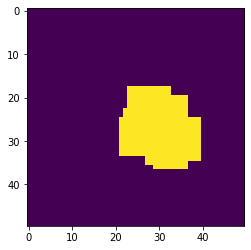

In [11]:
reload_modules()
x, rect_args = gfo.random_multi_rect(
    size=(50, 50), 
    n_rectangles=8,
    max_shape=(10, 10),
    return_rects=True, 
    first_rect_args={
        "top_left_x_props": (.3, .7),
        "top_left_y_props": (.3, .7)
    }
)
plt.imshow(x)


torch.Size([4, 1, 50, 50]) torch.Size([4, 50, 50])
CPU times: user 657 ms, sys: 8.74 ms, total: 666 ms
Wall time: 418 ms


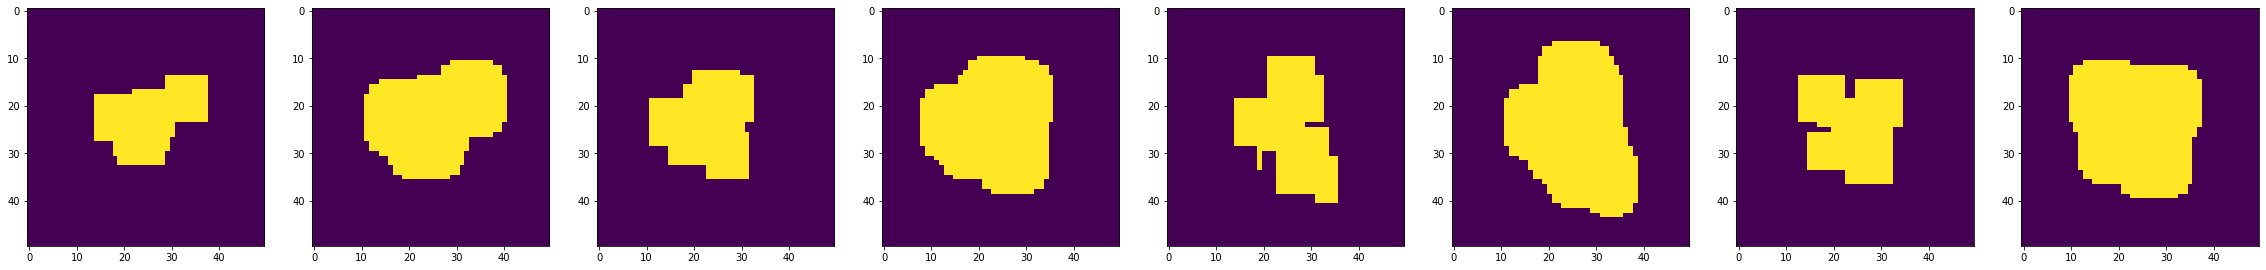

In [6]:
%%time
reload_modules()
dataset = mrda.MultiRectDataset(size=(50, 50), n_rectangles=8, max_shape=(10, 10), selem=morp.disk(3))
# input_, target = dataset[0]
dataloader = DataLoader(dataset, batch_size=4)

inputs, targets = next(iter(dataloader))
print(inputs.shape, targets.shape)

plot_horizontal(
    reduce(lambda a,b: a+b, 
           [[inpt[0].cpu(), target.cpu()] for (inpt, target) in zip(inputs, targets)]))

## Disks

In [29]:
ar = np.zeros((50, 50))
radius = 10
center = (14, 31)

XX, YY = np.meshgrid(np.arangee(ar.shape[0]), np.arange(ar.shape[1]))

In [31]:
idxes = np.sqrt((XX - center[0])**2 + (YY - center[1])**2) - radius

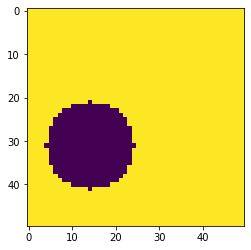

In [33]:
plt.imshow(idxes > 0)

In [89]:
min(center_x - min_x, max_x - center_x, max_shape[0] // 2)

5

In [346]:
reload_modules()
size = (50, 50)
n_shapes = 10
max_shape = (10, 10)
borders = (.1, .9)

all_diskorect = [np.zeros(size)]
min_x, min_y = int(size[0] * borders[0]), int(size[1] * borders[0])
max_x, max_y = int(size[0] * borders[1]), int(size[1] * borders[1])



In [194]:
min(center_x - min_x, max_x - center_x, max_shape[0] // 2)

2

In [207]:
max_shape[0]//2

5

center pre clip 24 48
center: 24 43
W1 W2 L1 L2 22 26 41 44
802.0


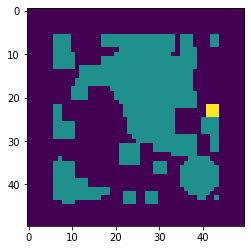

In [400]:

diskorect = all_diskorect[-1] + 0
not_0 = np.where(1 - diskorect)
rand_idx = random.choice(range(len(not_0[0])))
center_x, center_y = not_0[0][rand_idx], not_0[1][rand_idx]

print("center pre clip", center_x, center_y)
center_x = min(max_x - 2, max(min_x + 2, center_x))
center_y = min(max_y - 2, max(min_y + 2, center_y))

print("center:", center_x, center_y)

if np.random.rand() > .5:
    W1 = np.random.randint(1, min(center_x - min_x, max_shape[0] // 2))
    W2 = np.random.randint(1, min(max_x - center_x, max_shape[0] // 2))

    L1 = np.random.randint(1, min(center_y - min_y, max_shape[1] // 2))
    L2 = np.random.randint(1, min(max_y - center_y, max_shape[1] // 2))

    diskorect[center_x-W1:center_x+W2, center_y-L1:center_y+L2] = 1
    print("W1 W2 L1 L2", center_x-W1, center_x+W2, center_y-L1, center_y+L2)


else:
    radius = np.random.randint(1, min(center_x - min_x, max_x - center_x, max_shape[0]))
    radius = min(max_x - center_x, center_x - min_x, max_y - center_y, center_y - min_y, radius)
    gfo2.draw_disk(diskorect, (center_x, center_y), radius)
    print("r=", radius)

all_diskorect.append(diskorect)

disko_to_show = diskorect + 0
disko_to_show[(diskorect - all_diskorect[-2]).astype(bool)] = 2
plt.imshow(disko_to_show)
print(diskorect.sum())

In [336]:
all_diskorect[-2][39, 29]

1.0

In [414]:
reload_modules()
drc = gfo2.get_random_diskorect((50, 50), 30, (15, 15),)

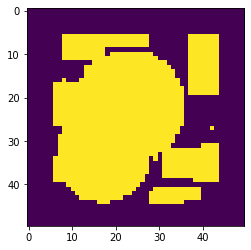

In [415]:
plt.imshow(drc)

In [ ]:
plt.imshow(drc)

## Diskorect

In [4]:
%%timeit 
gfo3.get_random_rotated_diskorect(
    size=(100, 100), 
    n_shapes=30,
    max_shape=(15, 15),
    p_invert=0.5,
    border=(4, 4),
    n_holes=30,
    max_shape_holes=(7, 7),
    noise_proba=0.1
)

776 µs ± 92.4 µs per loop (mean ± std. dev. of 7 runs, 1 loop each)


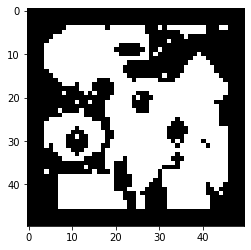

In [5]:
reload_modules()
x = gfo3.get_random_rotated_diskorect(
    size=(50, 50), 
    n_shapes=30,
    max_shape=(15, 15),
    p_invert=0.5,
    border=(4, 4),
    n_holes=15,
    max_shape_holes=(7, 7),
    noise_proba=0.05
)
plt.imshow(x, cmap='gray')


In [5]:
np.random.rand(5, 5)

array([[0.9383361 , 0.16752919, 0.3532739 , 0.51804779, 0.06744834],
       [0.0137424 , 0.8589926 , 0.26945179, 0.90185226, 0.41456367],
       [0.1401719 , 0.8642328 , 0.91726109, 0.05157154, 0.97386763],
       [0.54366318, 0.32952966, 0.9625261 , 0.35044086, 0.67201862],
       [0.78542865, 0.28926045, 0.56488438, 0.47357603, 0.10997295]])

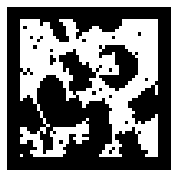

In [13]:
reload_modules()
h, w = 1, 1
fig, axs = plt.subplots(h, w, figsize=(w*3, h*3), squeeze=False)
for idx1 in range(h):
    for idx2 in range(w):
        x = gfo3.get_random_rotated_diskorect(
            size=(50, 50), 
            n_shapes=30,
            max_shape=(15, 15),
            p_invert=0.5,
            border=(4, 4),
            n_holes=15,
            max_shape_holes=(7, 7),
            noise_proba=0.05
        )
        axs[idx1, idx2].imshow(x, cmap='gray')
        axs[idx1, idx2].axis('off')


In [14]:
fig.savefig("diskorect2.eps")

## Axspa ROI

In [4]:
df = pd.read_csv('data/deep_morpho/axspa_roi/axspa_roi.csv')

In [30]:
reload_modules()
dataset = axd.AxspaROISimpleDataset(pd.read_csv('data/deep_morpho/axspa_roi/axspa_roi.csv'))
dataloader = axd.AxspaROISimpleDataset.get_loader(
    data=pd.read_csv('data/deep_morpho/axspa_roi/axspa_roi.csv'),
    batch_size=4,
    shuffle=True
)

(-0.5, 511.5, 511.5, -0.5)

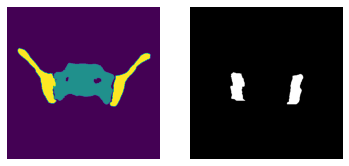

In [31]:
inpt, target = dataset[104]
all_chans = np.zeros(inpt.shape[1:])
all_chans[inpt[0] == 1] = 1
all_chans[inpt[1] == 1] = 2

fig = plt.figure(figsize=(6, 3))

ax = fig.add_subplot(121)
ax.imshow(all_chans)
ax.axis('off')

ax = fig.add_subplot(122)
ax.imshow(target[0], cmap='gray')
ax.axis('off')


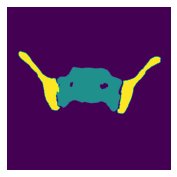

In [33]:
fig = plt.figure(figsize=(3, 3))
plt.imshow(all_chans)
plt.axis('off')
fig.savefig("axspa_input.eps")

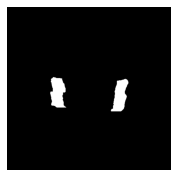

In [35]:
fig = plt.figure(figsize=(3, 3))
plt.imshow(target[0], cmap='gray')
plt.axis('off')
fig.savefig("axspa_target.eps")

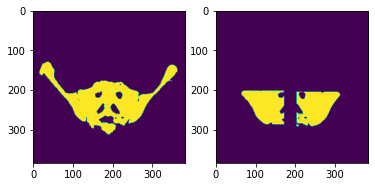

In [136]:
inpts, targets = next(iter(dataloader))

plt.subplot(121)
plt.imshow(inpts[0, 0].cpu())

plt.subplot(122)
plt.imshow(targets[0, 0].cpu())

In [81]:
inpts[0, 0].shape

torch.Size([528, 528])

## Mnist

### Segmentation

In [34]:
reload_modules()
dataset = mnist_dataset.MnistMorphoDataset(
    morp_operation=morpop.ParallelMorpOperations.erosion(('disk', 1)),
    n_inputs="all",
    train=False,
    threshold=.01,
    size=(28, 28)
)

dataloader = mnist_dataset.MnistMorphoDataset.get_loader(
    batch_size=4, n_inputs=1000, 
    morp_operation=morpop.ParallelMorpOperations.erosion(('bdiamond', 7)),
    train=True, shuffle=True, size=(28, 28)
)

In [68]:
ops = ["bcomplex", "scross", "bdiamond"]
sum_value = {op: [] for op in ops}

for op in ops:
    dataloader = mnist_dataset.MnistMorphoDataset.get_loader(
        batch_size=1, n_inputs="all", 
        morp_operation=morpop.ParallelMorpOperations.erosion((op, 7)),
        train=True, shuffle=True, size=(28, 28), threshold=(1/2),
    )
    for img, tar in tqdm(dataloader):
        img = img[0]
        tar = tar[0]

        sum_value[op].append(tar.sum().item(),)
    sum_value[op] = np.array(sum_value[op])


# plt.subplot(121)
# plt.imshow(img[0], cmap='gray')

# plt.subplot(122)
# plt.imshow(tar[0], cmap='gray')


100%|██████████| 60000/60000 [00:31<00:00, 1879.62it/s]


Text(0.5, 0.98, 'Erosion sum 60000 samples')

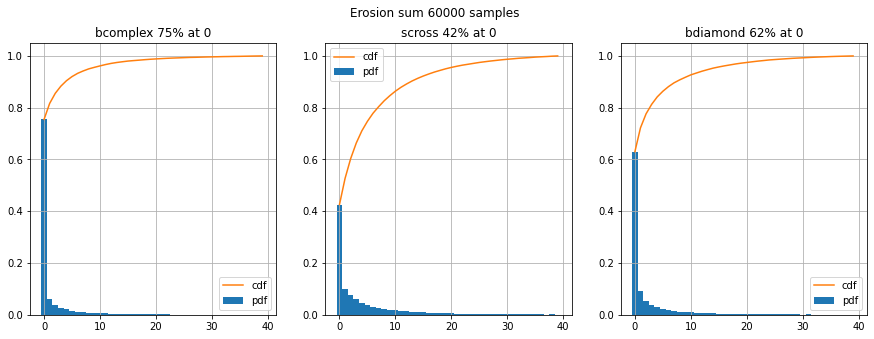

In [69]:
plt.figure(figsize=(15, 5))
max_bin = 40
for idx, op in enumerate(ops):
    plt.subplot(1, 3, idx+1)
    bins = np.arange(-0.5, max_bin + 0.5)
    plt.hist(sum_value[op],  bins=bins, label='pdf', density=True);
    plt.title(f"{op} {(sum_value[op] == 0).mean()*100:.0f}% at 0")

    # plt.subplot(2, 3, 3 + idx + 1)
    count, bins_count = np.histogram(sum_value[op], bins=bins)
    pdf = count / sum(count)
    cdf = np.cumsum(pdf)
    plt.plot(np.arange(max_bin), cdf, label='cdf')
    plt.legend()

    plt.grid('on')



plt.suptitle("Erosion sum 60000 samples")

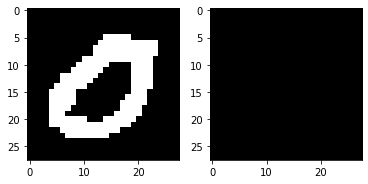

In [73]:
dataloader = mnist_dataset.MnistMorphoDataset.get_loader(
    batch_size=4, n_inputs=1000, 
    morp_operation=morpop.ParallelMorpOperations.erosion(('bdiamond', 7)),
    train=True, shuffle=True, size=(28, 28), threshold=1/2
)

img, tar = next(iter(dataloader))

plt.subplot(121)
plt.imshow(img[0, 0], cmap='gray')

plt.subplot(122)
plt.imshow(tar[0, 0], cmap='gray')

Text(0.5, 1.0, 'thresholded')

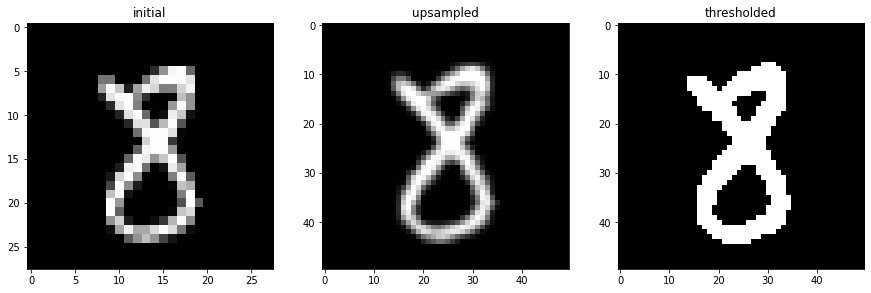

In [7]:
img = dataset.data[401]


plt.figure(figsize=(15, 5))
plt.subplot(131)
plt.imshow(img, cmap='gray')
plt.title('initial')

img2 = cv2.resize(img.numpy(), (50, 50), interpolation=cv2.INTER_CUBIC)
plt.subplot(132)
plt.imshow(img2, cmap="gray")
plt.title('upsampled')

plt.subplot(133)
plt.imshow(img2 > 50, cmap='gray')
plt.title('thresholded')


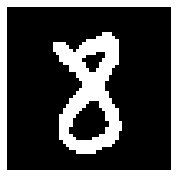

In [28]:
fig = plt.figure(figsize=(3, 3))
plt.imshow((img2 > 50), cmap='gray')
plt.axis('off')
fig.savefig("mnist.eps")

/hdd/aouadt/these/projets/3d_segm/deep_morpho/morp_operations.py:327: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(x)


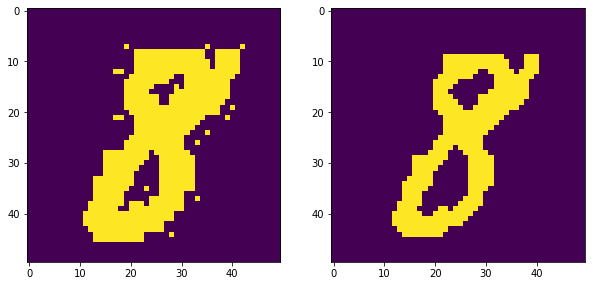

In [94]:
img, target = next(iter(dataloader))

plot_horizontal([img[0, 0], target[0, 0]])

### Classification

In [32]:
reload_modules()
dataset = mnist_dataset.MnistClassifDataset(
    n_inputs="all",
    train=False,
    threshold=.01,
)

dataloader = mnist_dataset.MnistClassifDataset.get_loader(
    batch_size=4, n_inputs=1000, 
    train=True, shuffle=True
)

Text(0.5, 1.0, 'tensor([0., 0., 0., 0., 0., 0., 0., 1., 0., 0.])')

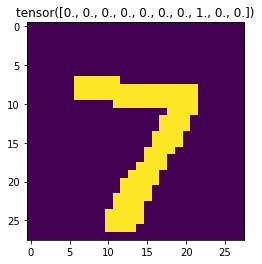

In [82]:
img, target = dataset[0]
plt.imshow(img[0])
plt.title(target)

Text(0.5, 1.0, 'tensor([[[0., 0., 0.,  ..., 0., 0., 0.],\n         [0., 0., 0.,  ..., 0., 0., 0.],\n         [0., 0., 0.,  ..., 0., 0., 0.],\n         ...,\n         [0., 0., 0.,  ..., 0., 0., 0.],\n         [0., 0., 0.,  ..., 0., 0., 0.],\n         [0., 0., 0.,  ..., 0., 0., 0.]]])')

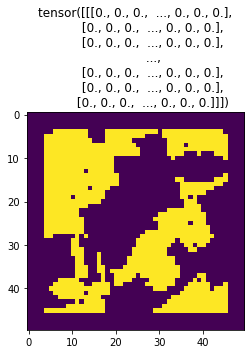

In [75]:
img, target = next(iter(dataloader))
plt.imshow(img[0, 0])
plt.title(target[0])

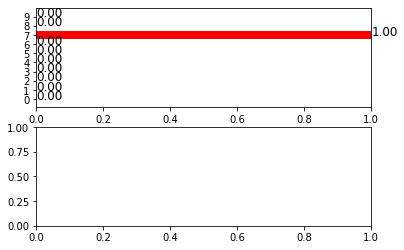

In [86]:
fig, ax = plt.subplots(2, 1)
colors = ["red" for _ in range(10)]
colors[target[0].argmax()] = "green"
ax[0].barh(np.arange(10), target, tick_label=range(10), color=colors)
ax[0].set_xlim(0, 1)
for idx, value in enumerate(target):
    ax[0].text(value, idx, f"{value.item():.2f}", fontsize=12, ha='left')

In [85]:
target.shape

torch.Size([10])

## Dataloader

In [12]:
morp_operation = morpop.ParallelMorpOperations.erosion(('disk', 3))
dataloader = mrda.DiskorectDataset.get_loader(
    random_gen_fn=gfo3.get_random_diskorect_channels,
    random_gen_args={'size': (50, 50), 'n_shapes': 20, 'max_shape': (20, 20), 'p_invert': 0.5, 'n_holes': 10, 'max_shape_holes': (10, 10), 'noise_proba': 0.02},
    morp_operation=morp_operation,
    n_inputs=100,
    batch_size=100,
    generate_infinite=True,
    num_workers=0,
)

dataloader2 = mrda.DiskorectDataset.get_loader(
    random_gen_fn=gfo3.get_random_diskorect_channels,
    random_gen_args={'size': (50, 50), 'n_shapes': 20, 'max_shape': (20, 20), 'p_invert': 0.5, 'n_holes': 10, 'max_shape_holes': (10, 10), 'noise_proba': 0.02},
    morp_operation=morp_operation,
    n_inputs=100 * 100,
    batch_size=100,
    generate_infinite=True,
    num_workers=0,
)


In [13]:
%%time
for _ in range(int(1e2)):
    for batch in dataloader:
        pass

CPU times: user 2min 17s, sys: 90.5 ms, total: 2min 17s
Wall time: 11.5 s


In [14]:
%%time
for batch in dataloader2:
    pass

CPU times: user 2min 14s, sys: 132 ms, total: 2min 14s
Wall time: 11.3 s


# Net

## BiSE

### Ellipses

In [105]:
reload_modules()
model = bise.BiSE(
    kernel_size=(7, 7),
    initializer=inits.InitBiseEllipseWeightsRoot(init_bias_value=1),
    weights_optim_mode=bise.BiseWeightsOptimEnum.ELLIPSE_ROOT,
    bias_optim_mode=bise.BiseBiasOptimEnum.POSITIVE,
    out_channels=3,
)

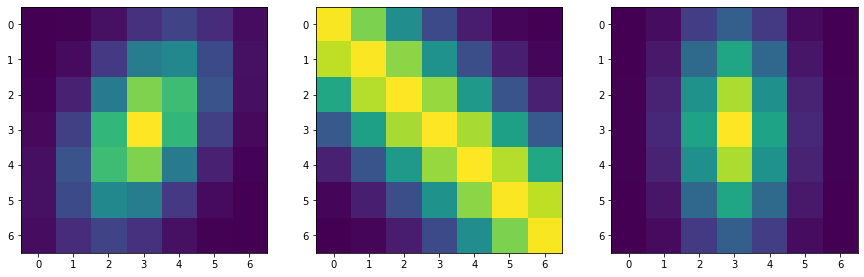

In [106]:
plt.figure(figsize=(15, 5))
for chout in range(model._normalized_weight.shape[0]):
    plt.subplot(1, 3, chout + 1)
    plt.imshow(model._normalized_weight[chout, 0].detach())

### From Operations

In [107]:

# selem = morp.disk(4)
selem = np.zeros((5, 5))
selem[0, 1] = 1
selem[0, 2] = 1
net1 = bise.BiSE.bise_from_selem(selem, "erosion", weight_P = 5, activation_P=10)
net2 = bise.BiSE.bise_from_selem(selem, "dilation", weight_P = 5, activation_P=10)
# net.conv.weight.data = net.conv.weight.data + torch.rand(net.conv.weight.data.shape) / 10

In [108]:
# %%time
print(net1.find_selem_and_operation_chan(0))
print(net2.find_selem_and_operation_chan(0))

(array([[[False,  True,  True, False, False],
        [False, False, False, False, False],
        [False, False, False, False, False],
        [False, False, False, False, False],
        [False, False, False, False, False]]]), 'erosion')
(array([[[False,  True,  True, False, False],
        [False, False, False, False, False],
        [False, False, False, False, False],
        [False, False, False, False, False],
        [False, False, False, False, False]]]), 'dilation')


In [109]:
net1.binary()
net2.binary()

BiSEBase(
  (conv): Conv2d(1, 1, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), bias=False, padding_mode=replicate)
  (activation_threshold_layer): SoftplusThresholdLayer()
  (bias_handler): BiasBiseSoftplusReparametrized(
    (softplus_layer): Softplus(beta=1, threshold=20)
  )
  (weights_handler): WeightsThresholdedBise(
    (threshold_layer): SoftplusThresholdLayer()
  )
)

In [110]:
morp_operation = ParallelMorpOperations.erosion(('disk', 3))
dataset = DataModule.select("DiskorectDataset")(
    random_gen_args={'size': (50, 50), 'n_shapes': 30, 'max_shape': (20, 20), 'p_invert': 0.5, 'n_holes': 10, 'max_shape_holes': (10, 10), 'noise_proba': 0.02, "border": (1, 1)},
    morp_operation=morp_operation,
    # n_inputs=1000000,
    # batch_size=100,
    # num_workers=0,
)

In [111]:
net1.binary(False)
net2.binary(False)
img, tar = dataset[0]
otp_biseero = net1(img.unsqueeze(0)).detach().numpy()[0, 0]
otp_ero = morp.binary_erosion(img[0].numpy(), selem)

otp_bisedila = net2(img.unsqueeze(0)).detach().numpy()[0, 0]
otp_dila = morp.binary_dilation(img[0].numpy(), selem)


otp_bimonn = net2(net1(img)).detach().numpy()[0, 0]

otp_ope = morp.binary_dilation(morp.binary_erosion(img[0].numpy(), selem), selem)
# otp_ope = morp.binary_opening(img[0].numpy(), selem)

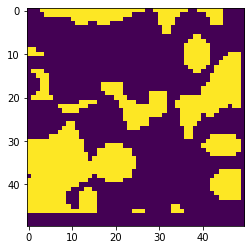

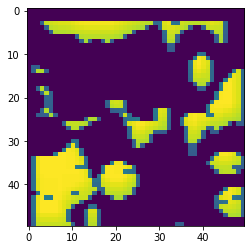

In [112]:
plt.figure()
plt.imshow(otp_dila)

plt.figure()
plt.imshow(otp_bisedila)

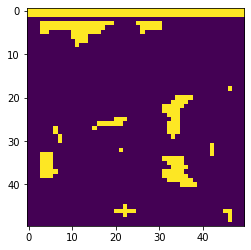

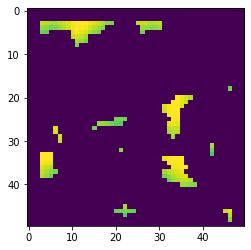

In [106]:
plt.figure()
plt.imshow(otp_ero)

plt.figure()
plt.imshow(otp_biseero)

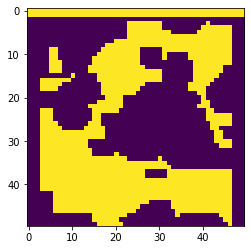

In [82]:
plt.imshow(morp.binary_erosion(img[0].numpy(), selem))
# plt.imshow(morp.binary_dilation(img[0].numpy(), selem))

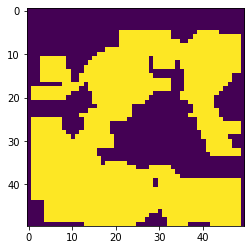

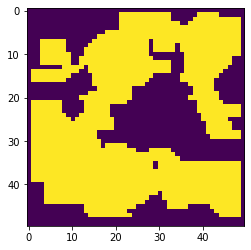

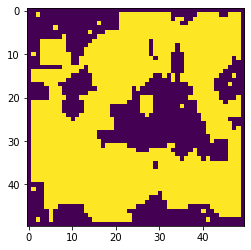

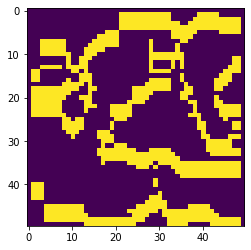

In [83]:
plt.figure()
plt.imshow(otp_bimonn)

plt.figure()
plt.imshow(otp_ope)

plt.figure()
plt.imshow(img[0])

plt.figure()
plt.imshow(otp_bimonn != otp_ope)

In [10]:
%%time
weight_values = net._normalized_weight.unique()
possible_values = (weight_values >= -net.bias[0])
net.is_dilation_by(
    net._normalized_weight[0, 0],
    net.bias[0],
    (net._normalized_weight >= weight_values[possible_values][0]).squeeze().cpu().detach().numpy()
)


CPU times: user 3.38 ms, sys: 0 ns, total: 3.38 ms
Wall time: 2.62 ms


tensor(True)

In [20]:
reload_modules()
net = bise.BiSE((7, 7))

In [23]:
net.find_closest_selem_and_operation_chan(0, )

(array([[False, False, False, False, False, False, False],
        [False, False, False, False, False, False, False],
        [False, False, False, False, False, False, False],
        [False, False, False,  True, False, False, False],
        [False, False, False, False, False, False, False],
        [False, False, False, False, False, False, False],
        [False, False, False, False, False, False, False]]),
 'dilation',
 12.631749)

In [16]:
net._normalized_weight

tensor([[[[0.2545, 0.3041, 0.3222, 0.2288, 0.3238, 0.2319, 0.2436],
          [0.3751, 0.3237, 0.2633, 0.3169, 0.2688, 0.2800, 0.3529],
          [0.3472, 0.2508, 0.3233, 0.2579, 0.2382, 0.2103, 0.1749],
          [0.3163, 0.3901, 0.2533, 0.8253, 0.2500, 0.1981, 0.2915],
          [0.2876, 0.2653, 0.2536, 0.2127, 0.3785, 0.2326, 0.2806],
          [0.2544, 0.2250, 0.2896, 0.2587, 0.2529, 0.3269, 0.1887],
          [0.2229, 0.3557, 0.2040, 0.1945, 0.2027, 0.3239, 0.2309]]]],
       grad_fn=<SigmoidBackward>)

In [14]:
reload_modules()
x = torch.ones((3, 1, 50, 50))

net = bise.BiSE(kernel_size=(50, 50), padding=0, stride=25)
net(x)

tensor([[[[1.]]],


        [[[1.]]],


        [[[1.]]]], grad_fn=<SigmoidBackward>)

In [25]:
net = nn.Conv2d(1, 1, (50, 50))
net.weight.data = torch.ones_like(net.weight)
net(x)

tensor([[[[2499.9868]]],


        [[[2499.9868]]],


        [[[2499.9868]]]], grad_fn=<MkldnnConvolutionBackward>)

In [37]:
torch.ones(1, 1, 1, 1).squeeze(-1).squeeze(-1).shape

torch.Size([1, 1])

### Tests

In [4]:
reload_modules()
n_chin = 10
n_chout = 20

layer1 = bise.BiSE(kernel_size=(5, 5), in_channels=n_chin, out_channels=n_chout * n_chin, groups=n_chin)
layer2 = bise.BiSE(kernel_size=(1, 1), in_channels=n_chin * n_chout, out_channels=n_chout, groups=n_chout)


In [10]:
layer2.learned_operation.shape

(20,)

In [103]:
x = torch.rand((10, n_chin, 5, 5))

In [104]:
net(x).shape

torch.Size([10, 1500, 5, 5])

## Bisel

In [122]:
%matplotlib inline

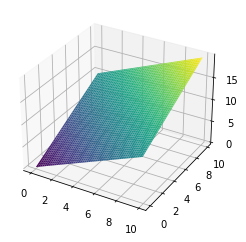

In [125]:
X = np.arange(0, 10, 0.1)
Y = np.arange(0, 10, 0.1)
XX, YY = np.meshgrid(X, Y)
ZZ = YY + XX

ax = plt.figure().add_subplot(projection='3d')
ax.plot_surface(XX, YY, ZZ, cmap='viridis', edgecolor='none')

In [98]:

n_chin = 10
n_chout = 20

netb = bisel.BiSEL(kernel_size=(5, 5), in_channels=n_chin, out_channels=n_chout,)
netb.cuda()

netf = nn.Conv2d(30, 50, (5, 5))
netf.cuda()

x = torch.ones((1, n_chin, 50, 50)).cuda()


In [105]:
netb.bias_lui.shape

torch.Size([20])

In [43]:
netb.activation_P_bise.shape

torch.Size([20, 10])

In [37]:
netb.luis.bias.shape

torch.Size([20])

In [30]:
netb.luis.coefs.shape

torch.Size([20, 10])

In [17]:
netb.coef.shape

torch.Size([20, 10])

In [146]:
netb = bisel.BiSEL(kernel_size=(5, 5), in_channels=n_chin, out_channels=n_chout,)

BiSEL(
  (bises): BiSE(
    (conv): Conv2d(10, 100, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), groups=10, bias=False, padding_mode=replicate)
    (activation_threshold_layer): TanhLayer()
    (bias_handler): BiasSoftplus(
      (softplus_layer): Softplus(beta=1, threshold=20)
    )
    (weights_handler): WeightsThresholdedBise(
      (threshold_layer): SoftplusThresholdLayer()
    )
  )
  (luis): LUI(
    (conv): Conv2d(100, 10, kernel_size=(1, 1), stride=(1, 1), groups=10, bias=False, padding_mode=replicate)
    (activation_threshold_layer): TanhLayer()
    (bias_handler): BiasBiseSoftplusReparametrized(
      (softplus_layer): Softplus(beta=1, threshold=20)
    )
    (weights_handler): WeightsThresholdedBise(
      (threshold_layer): SoftplusThresholdLayer()
    )
  )
)

In [150]:
tqdm

tqdm.std.tqdm

In [156]:


n_chins = np.arange(1, 10)
n_chouts = np.arange(1, 10)

bin_times = np.zeros((len(n_chins), len(n_chouts)))

bar = tqdm(total=len(n_chins) * len(n_chouts))

for n_chin_idx, n_chin in enumerate(n_chins):
    for n_chout_idx, n_chout in enumerate(n_chouts):
        bar.update(1)
        netb = bisel.BiSEL(kernel_size=(5, 5), in_channels=n_chin, out_channels=n_chout,)
        tim = %timeit -q -o -n 5 netb.binary();
        bin_times[n_chin_idx, n_chout_idx] = tim.average

  0%|          | 0/81 [00:00<?, ?it/s]

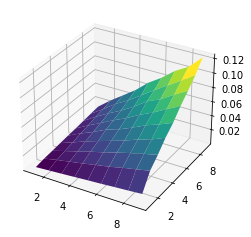

In [157]:
XX, YY = np.meshgrid(n_chins, n_chouts)

ax = plt.figure().add_subplot(projection='3d')
ax.plot_surface(XX, YY, bin_times, cmap='viridis', edgecolor='none')

In [116]:
%%timeit
netb.forward_save(x)

2.07 ms ± 8.87 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [115]:
%%timeit
netb.binary()

280 ms ± 1.86 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [85]:
%%timeit
netb.bises.weight

3.76 µs ± 5.63 ns per loop (mean ± std. dev. of 7 runs, 100000 loops each)


In [77]:
netb.bises.bias.shape

torch.Size([1500])

In [65]:
torch.stack([torch.stack([torch.ones((7, 7)) for _ in range(3)]) for _ in range(4)]).shape

torch.Size([4, 3, 7, 7])

In [55]:
netb.bises.weight.shape

torch.Size([1500, 1, 5, 5])

In [54]:
%%timeit
netb.binary()

3.95 s ± 16 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [5]:
%%timeit

otp = netb(x)
otp.sum().backward()

/hdd/aouadt/these/projets/3d_segm/deep_morpho/models/bisel.py:21: UserWarning: __floordiv__ is deprecated, and its behavior will change in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values. To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor').
  m = x // div1


7.53 ms ± 193 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [6]:
%%timeit

otp = netf(x)
otp.sum().backward()

419 µs ± 11.8 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


In [7]:
7.5 / 0.4

18.75

In [9]:
n_chin = 30
n_chout = 40

device = torch.device("cuda")
# device = torch.device("cpu")

layer1 = nn.Conv2d(in_channels=n_chin, out_channels=n_chout*n_chin, kernel_size=(5, 5), groups=n_chin, padding="same").to(device)
layer2 = nn.Conv2d(in_channels=n_chout*n_chin, out_channels=n_chout, kernel_size=(1, 1), groups=n_chout, padding="same").to(device)

# layer1.bias = nn.Parameter(torch.zeros_like(layer1.bias))
# layer1.weight = nn.Parameter(torch.ones_like(layer1.weight))

# layer2.bias = nn.Parameter(torch.zeros_like(layer2.bias))
# layer2.weight = nn.Parameter(torch.ones_like(layer2.weight))


In [13]:
print(layer1.weight.shape)
print(layer2.weight.shape)

torch.Size([1200, 1, 5, 5])
torch.Size([40, 30, 1, 1])


In [12]:
layer1.bias.shape

torch.Size([1200])

In [101]:
x = torch.zeros((1, n_chin, 50, 50))
for chin in range(n_chin):
    x[:, chin, :] = chin + 1

x = x.to(device)

In [123]:
def invert_euclidian(x, div1, div2):
    """x = mq + r
    Returns rq + m
    """
    m = x // div1
    r = x % div1
    return div2 * r + m

def recalibrate_input_lui(x, n_chin, n_chout):
    index = invert_euclidian(torch.arange(n_chout*n_chin), n_chin, n_chout).to(x.device)
    return torch.index_select(x, 1, index)
    # return x[:, index, ...]


In [108]:
assert torch.tensor([invert_euclidian(i, n_chin, n_chout) for i in range(n_chin * n_chout)]).eq(
    invert_euclidian(torch.arange(n_chin * n_chout), n_chin, n_chout)
).all()


/tmp/ipykernel_23211/991823678.py:5: UserWarning: __floordiv__ is deprecated, and its behavior will change in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values. To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor').
  m = x // div1


In [1]:
%%timeit

ot1 = layer1(x)
# ot1 = ot1[:, [invert_euclidian(i, n_chin, n_chout) for i in range(n_chout*n_chin)], ...]
ot1 = recalibrate_input_lui(ot1, n_chin, n_chout)
ot2 = layer2(ot1)

ot2.sum().backward()

# print(ot1)
# print(ot11)
# print(ot2)

NameError: name 'layer1' is not defined

In [ ]:
ot1 = layer1(x)
# ot1 = ot1[:, [invert_euclidian(i, n_chin, n_chout) for i in range(n_chout*n_chin)], ...]
ot1 = recalibrate_input_lui(ot1, n_chin, n_chout)
ot2 = layer2(ot1)

ot2.sum().backward()

/tmp/ipykernel_23211/3894914656.py:5: UserWarning: __floordiv__ is deprecated, and its behavior will change in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values. To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor').
  m = x // div1


In [42]:
netb.coefs.shape

torch.Size([50, 30])

In [48]:
ot1 = layer1(x).detach()

In [44]:
%%timeit

otp = layer1(x)
otp.sum().backward()

969 µs ± 3.93 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


In [49]:
%%timeit

otp = layer2(ot1)
otp.sum().backward()

1.7 ms ± 13.7 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


## DilationSum

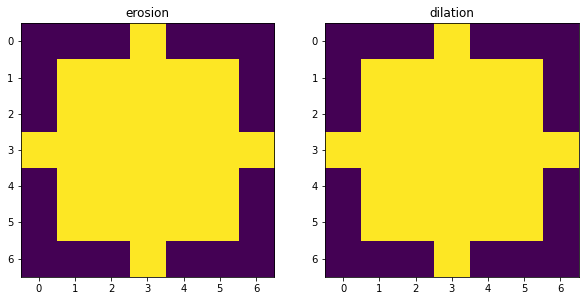

In [5]:
reload_modules()

morp_operation = arm.SequentialMorpOperations(
    name="opening", 
    selems=[morp.disk(3), morp.disk(3)],
    operations=['erosion', 'dilation'],
    device=device
)

plot_horizontal(morp_operation.selems, morp_operation.operations)

dataloader = mrda.get_loader(
    batch_size=32, 
    n_inputs=500_000,
    random_gen_fn=gfo3.get_random_rotated_diskorect,
    random_gen_args={'size': (50, 50), 'n_shapes': 15, 'max_shape': (15, 15), 'p_invert': .5,
                    'border': (4, 4)},
    device=device,
    morp_operation=morp_operation,
)



In [ ]:
img, target = next(iter(dataloader))

In [69]:
reload_modules()
net = dis.DilationSumLayer(kernel_size=(5, 5), padding=2)
net.to(device)

DilationSumLayer(
  (unfolder): Unfolder()
  (maxpool): MaxPool2d(kernel_size=(5, 5), stride=(5, 5), padding=0, dilation=1, ceil_mode=False)
)

In [59]:
net.kron_weight(img.shape[-2:]).shape

torch.Size([230, 230])

In [52]:
net.unfolder._right_operator[torch.Size([50, 50])].shape

torch.Size([50, 230])

In [67]:
net.unfolder(img[0, 0]).shape

torch.Size([240, 240])

In [70]:
net(img).shape

torch.Size([32, 1, 50, 50])

# Parallel Morp Operations Tests

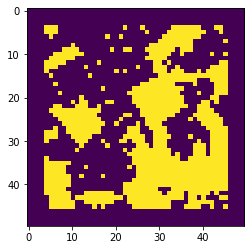

In [70]:
x = gfo3.get_random_diskorect_channels(
    size=(50, 50, 1), 
    n_shapes=30,
    max_shape=(15, 15),
    p_invert=0.5,
    border=(4, 4),
    n_holes=15,
    max_shape_holes=(7, 7),
    noise_proba=0.05
)
plt.imshow(x)

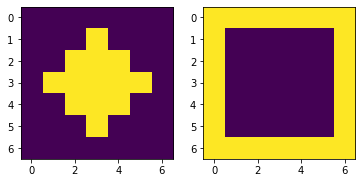

In [73]:
# reload_modules()

W = 7

selem1 = np.zeros((W, W))
selem1[1:-1, 1:-1] = selm.disk(W // 2 - 1)

selem2 = np.ones((W, W))
selem2[1:-1, 1:-1] = 0

mp = morpop.ParallelMorpOperations.hit_or_miss_transform(selem1, selem2)
# mp = morpop.ParallelMorpOperations.erosion(selem1)
identity = ('dilation', ('identity', 3), False)
mp = morpop.ParallelMorpOperations(
    operations=[
        [
            [identity, 'union'],
            [identity, 'union'],
            [identity, 'union'],
            [identity, 'union'],
        ],
        [
            [identity, ('erosion', selem1, True), identity, identity, ('intersection', [0, 1])],
            [identity, identity, identity, ('dilation', selem2, False), ('intersection', [2, 3])],
        ],
        [
            [identity, identity, 'union']
        ]
    ]
)

outp = mp(x)

plt.subplot(121)
plt.imshow(selem1)

plt.subplot(122)
plt.imshow(selem2)


In [90]:
mp.ui_arrays

[[('union', array([1], dtype=uint8)),
  ('union', array([1], dtype=uint8)),
  ('union', array([1], dtype=uint8)),
  ('union', array([1], dtype=uint8))],
 [('intersection', array([1, 1, 0, 0], dtype=uint8)),
  ('intersection', array([0, 0, 1, 1], dtype=uint8))],
 [('union', array([1, 1], dtype=uint8))]]

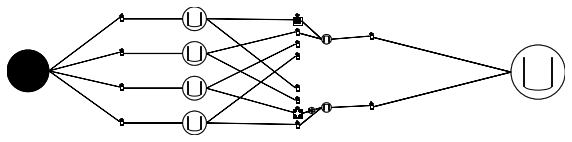

In [74]:
disp = mov.MorpOperationsVizualiser(mp)
disp.draw(figsize=(10, 10))

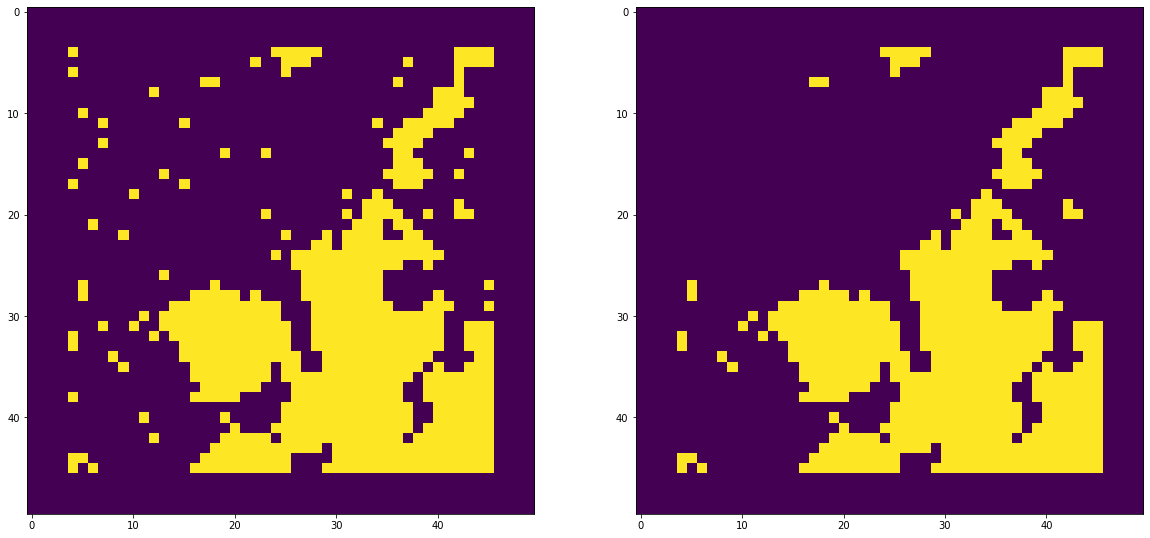

In [52]:
plt.figure(figsize=(20, 20))

plt.subplot(121)
plt.imshow(x)

plt.subplot(122)
plt.imshow(outp)

In [13]:
selem = np.array([[0, 0, 1]])
np.ones((3, 3))[np.where(selem)]

array([1.])

In [62]:
x = np.zeros((10, 10, 1))
x[4, 4, 0] = 1

In [72]:
import copy
mop2 = copy.deepcopy(mop)

In [73]:
mop2.operations.append("banana")

In [76]:
l = [1, 2, 3]
l.extend([3, 3])

In [77]:
l

[1, 2, 3, 3, 3]

In [75]:
mop.operations

[[[<function deep_morpho.morp_operations.ParallelMorpOperations._erodila_op_converter.<locals>.<lambda>(x)>,
   <function deep_morpho.morp_operations.ParallelMorpOperations._ui_converter.<locals>.<lambda>(x)>]]]

[[0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]]


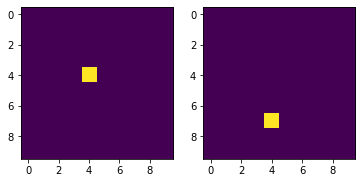

In [70]:
reload_modules()
# selem = np.zeros((3, 3))
# selem[0, 1] = 1
mop = morpop.ParallelMorpOperations.translation(3, 0)

plt.subplot(121)
plt.imshow(x)

plt.subplot(122)
plt.imshow(mop(x))

# Duality Learning

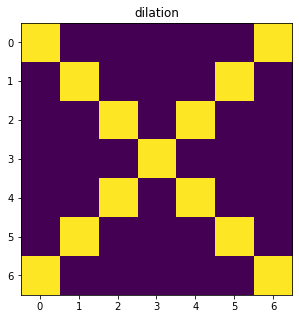

In [43]:
reload_modules()

morp_operation = arm.SequentialMorpOperations(
    name="dilation", 
    selems=[('dcross', 7)],
    operations=['dilation'],
    device='cpu'
)

plot_horizontal(morp_operation.selems, morp_operation.operations)

dataloader = mrda.MultiRectDatasetGenerator.get_loader(
    batch_size=32, 
    n_inputs=500_000,
    random_gen_fn=gfo3.get_random_rotated_diskorect,
    random_gen_args={'size': (50, 50), 'n_shapes': 15, 'max_shape': (15, 15), 'p_invert': .5,
                    'border': (4, 4)},
    device='cpu',
    morp_operation=morp_operation,
)



In [62]:
imgs, targets = next(iter(dataloader))
img = imgs[0, 0]
target = targets[0]

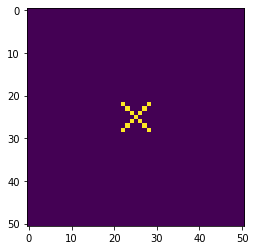

In [63]:
plt.imshow(arm.array_erosion(ar=target, selem=img))

# Training

## Dilation / Erosion

Opening 49


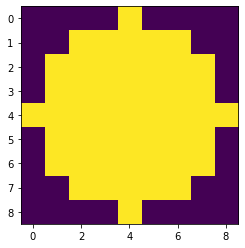

In [118]:
reload_modules()

# morp_operation = 'Dilation'
# morp_operation = 'Erosion'
morp_operation = 'Opening'

# selem = np.zeros((5, 5))
# selem[np.arange(5), 5 - np.arange(1, 6)] = 1
# selem[np.arange(5), np.arange(5)] = 1
# selem[:, 2] = 1
# selem[2, :] = 1
selem = morp.disk(4)
plt.imshow(selem)
print(morp_operation, selem.sum())

dataloader = mrda.get_loader(
    batch_size=32, 
    n_inputs=500_000,
#     random_gen_fn=gfo.random_multi_rect,
#     random_gen_args={
#         'size': (50, 50), 
#         'n_rectangles': 8,
#         'max_shape': (10, 10), 
#     },
    random_gen_fn=gfo3.get_random_rotated_diskorect,
    random_gen_args={'size': (50, 50), 'n_shapes': 15, 'max_shape': (15, 15), 'p_invert': .5},
    device=device, 
    selem=selem,
    morp_operation=morp_operation,
)

0


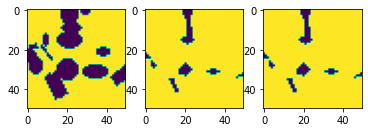

In [139]:
img, target = next(iter(dataloader))
img = img[0, 0].detach().cpu()

fig = plt.figure()
ax = fig.add_subplot(131)
ax.imshow(img)

selems = []

selem = np.zeros((5, 5))
selem[2, :] = 1
selems.append(selem)

selem = np.zeros((5, 5))
selem[:, 2] = 1
selems.append(selem)


morp_fn = arm.sequentiel_morp_operations(
    img,
    selems=selems,
    operations=['dilation', 'dilation']
)

oimg = morp_fn(img)
ax = fig.add_subplot(132)
ax.imshow(oimg)

oimg2 = arm.array_dilation(img, selem=np.ones((5, 5)))
ax = fig.add_subplot(133)
ax.imshow(oimg2)

print((oimg - oimg2).sum())

In [130]:
img.shape

torch.Size([50, 50])

In [11]:
reload_modules()
loss = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam

if morp_operation.lower() != "opening":
    observables = [
        obs.PlotParametersDilation(100),
        obs.PlotPreds(100),
        obs.WeightsHistogramDilation(1000)
    ]
    
    model = lbise.LightningBiSE(
        model_args={
            "in_channels": 1, "out_channels": 1, "kernel_size": (5, 5)
        },
        learning_rate=1e-2,
        loss=loss,
        optimizer=optimizer,
        output_dir="deep_morpho/results",
        observables=observables
    )
else:
    observables = [
        obs.PlotParametersMultipleDilations(1),
        obs.PlotPreds(1),
        obs.WeightsHistogramMultipleDilations(1)
    ]
    
    model = lon.LightningOpeningNet(
        model_args={
            "share_weights": True, "in_channels": 1, "out_channels": 1, "kernel_size": (5, 5)
        },
        learning_rate=5e-2,
        loss=loss,
        optimizer=optimizer,
        output_dir="deep_morpho/results",
        observables=observables
    )


model.to(device)

logger = TensorBoardLogger("deep_morpho/results", name=morp_operation)
print(logger.log_dir)

logger.experiment.add_graph(model, torch.ones(1, 1, 50, 50).to(device))
logger.experiment.add_image("target_SE", selem[np.newaxis, :].astype(float))

trainer = Trainer(
    max_epochs=1,
    gpus=1 if torch.cuda.is_available() else 0,
    logger=logger,
    progress_bar_refresh_rate=10,
    callbacks=observables.copy()
)

trainer.fit(model, dataloader)


GPU available: True, used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type              | Params
--------------------------------------------
0 | model | OpeningNet        | 55    
1 | loss  | BCEWithLogitsLoss | 0     
--------------------------------------------
55        Trainable params
0         Non-trainable params
55        Total params
0.000     Total estimated model params size (MB)


deep_morpho/results/Opening/version_13


Validation sanity check: 0it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

In [68]:
img, target = dataloader.dataset[0]
otp = model(img.unsqueeze(0).cpu())


- Unet Version 15: training on $3 \cdot 10^8$ images with softmax before weight
- Dilation Version 0: training on $3 \cdot 10^8$ images without softmax, max min norm

In [103]:
model = model.load_from_checkpoint(join("deep_morpho/results/Unet/version_15/checkpoints/epoch=0-step=93749.ckpt"))

<ipython-input-3-2732c24916c7>:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig = plt.figure(figsize=(5*n_figs, 5))


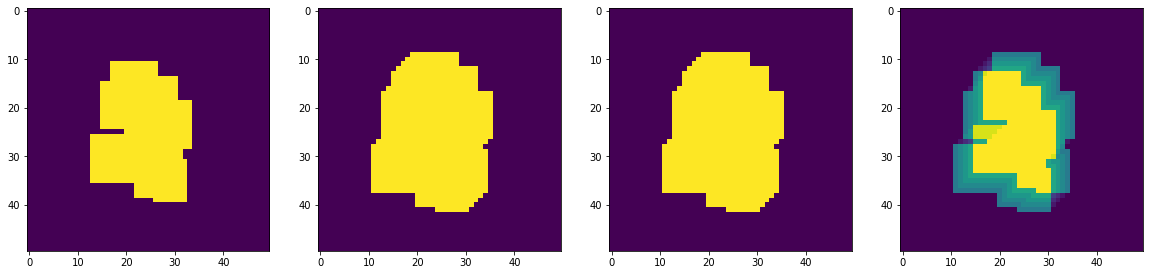

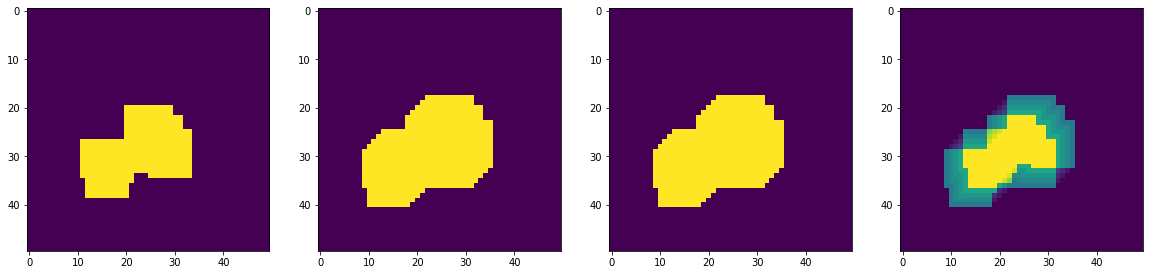

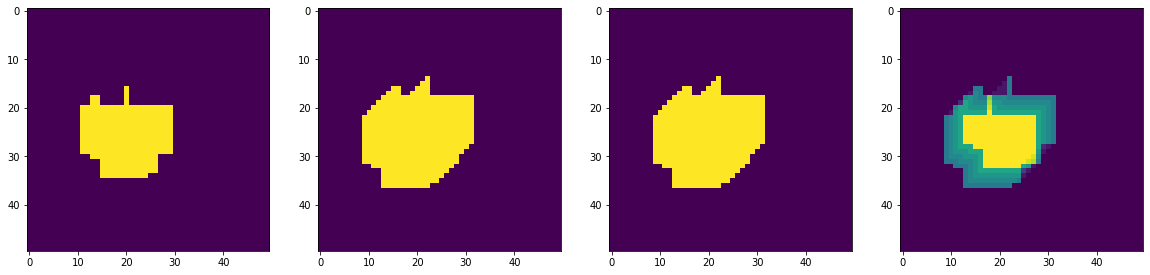

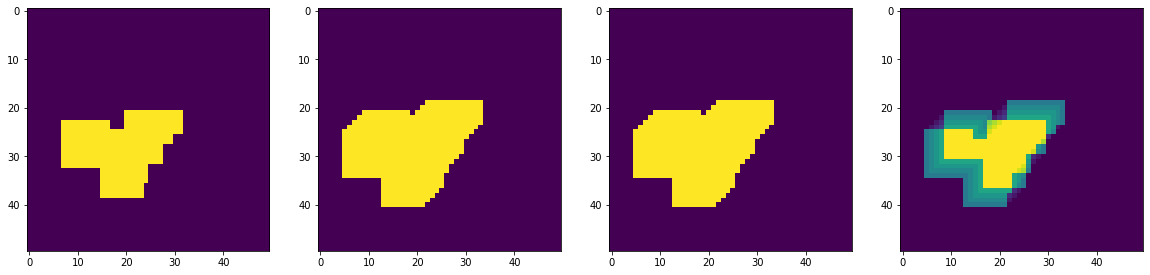

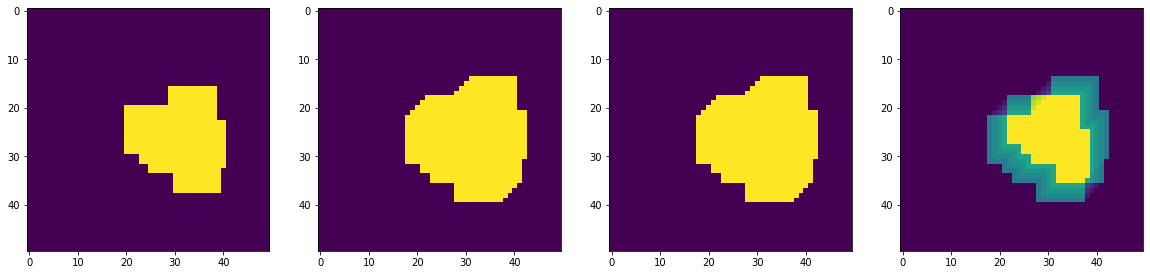

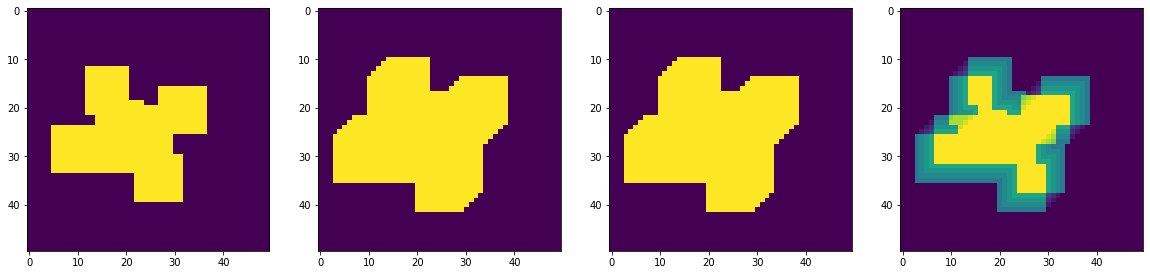

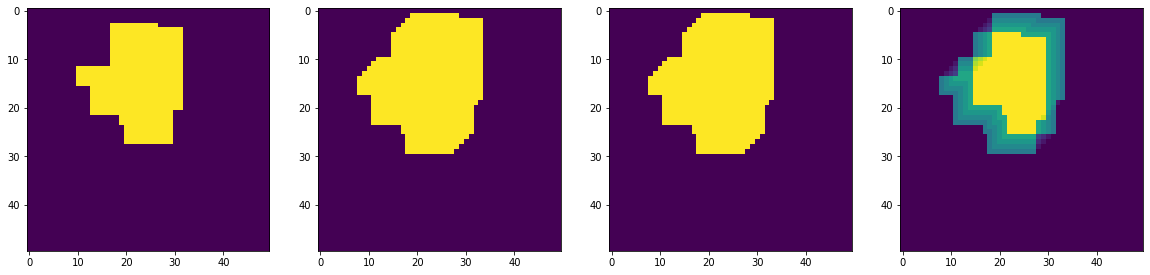

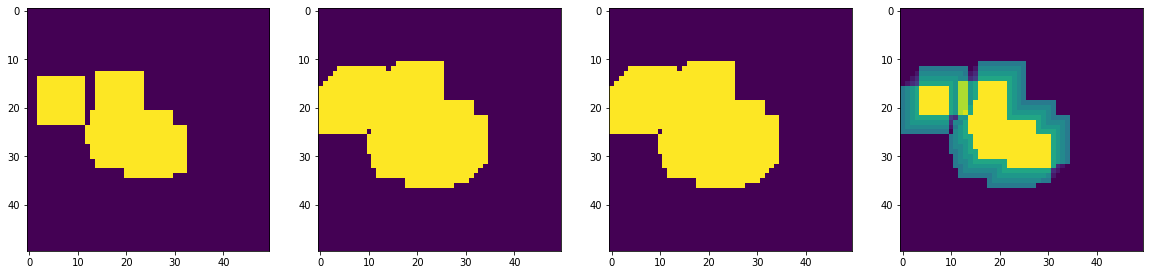

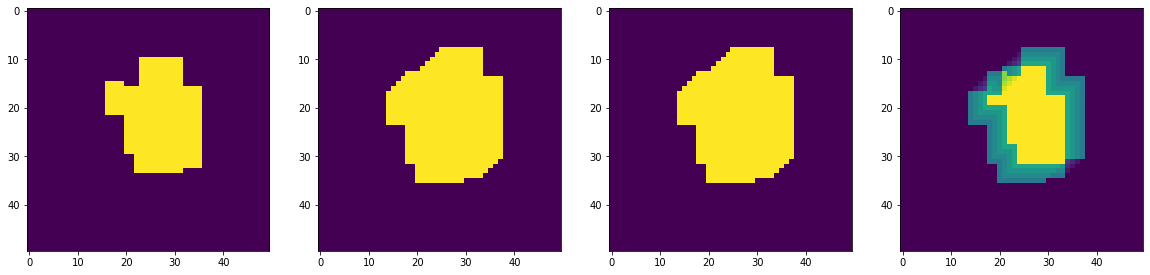

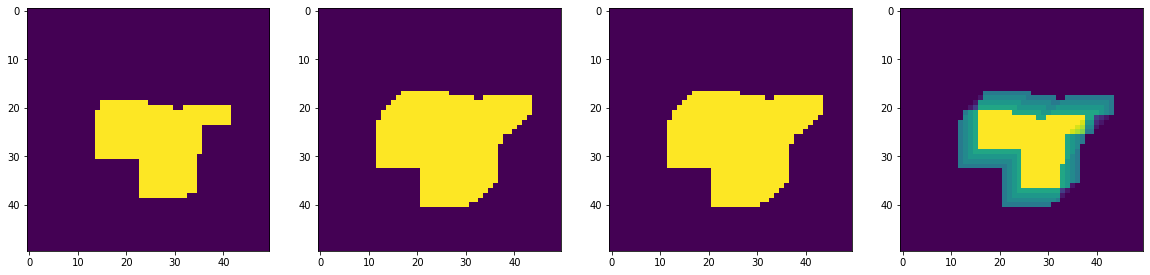

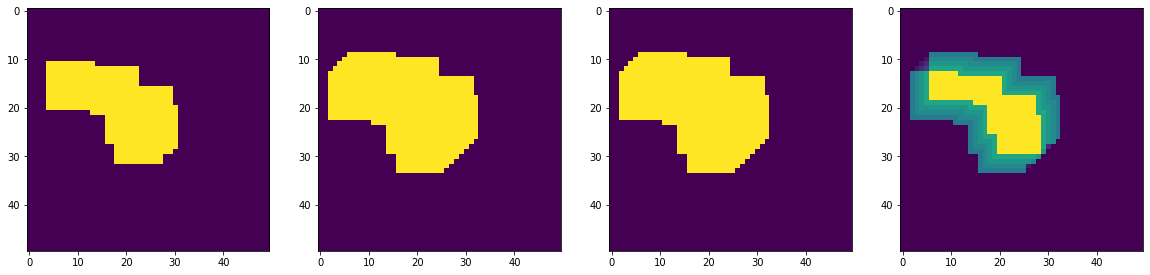

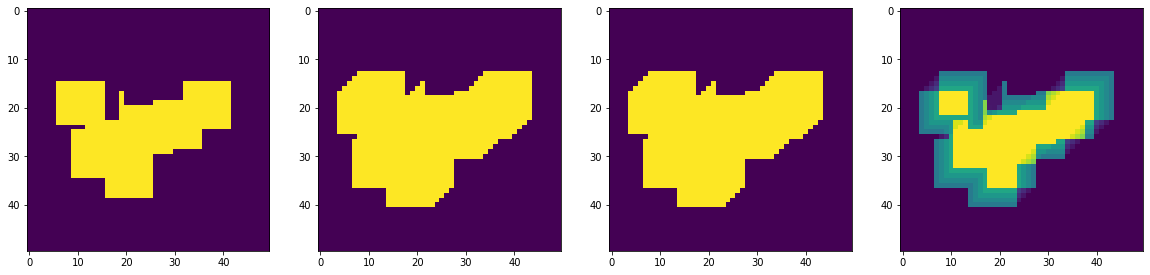

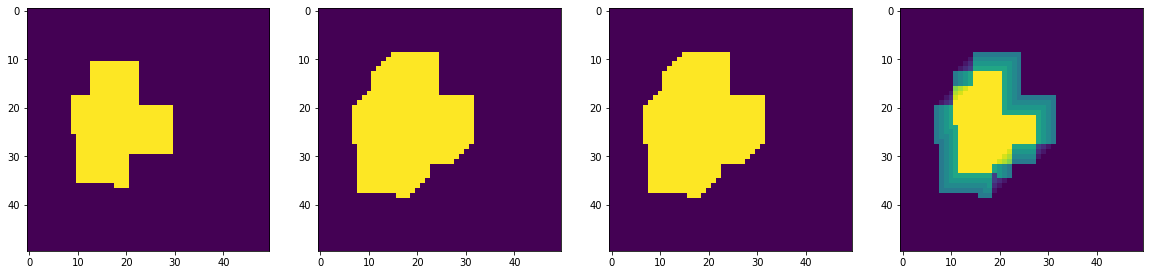

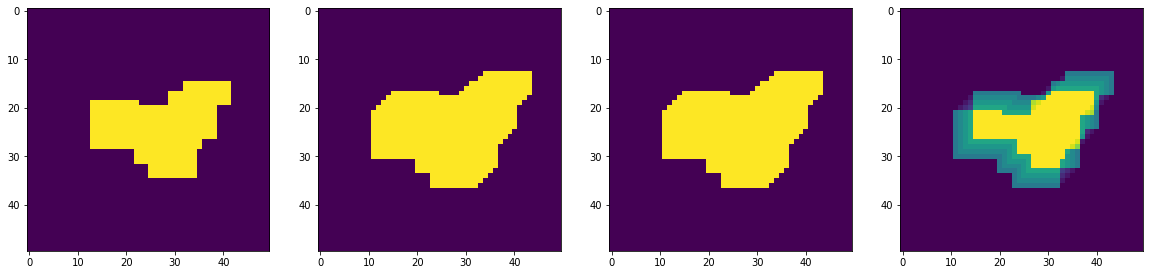

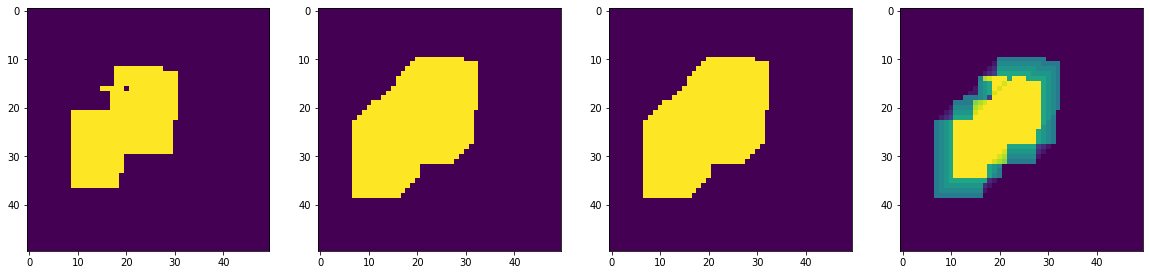

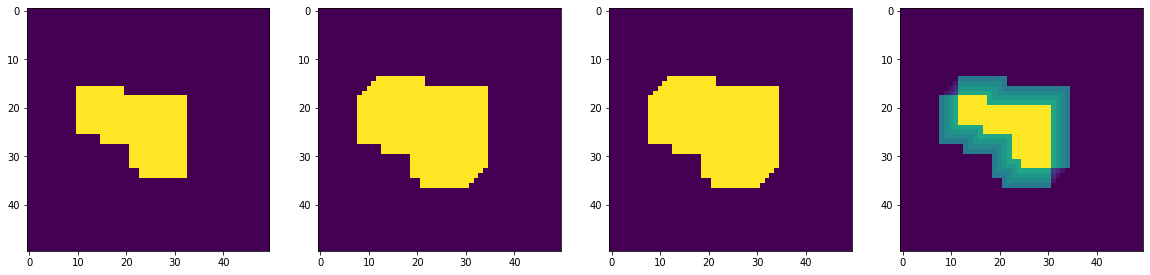

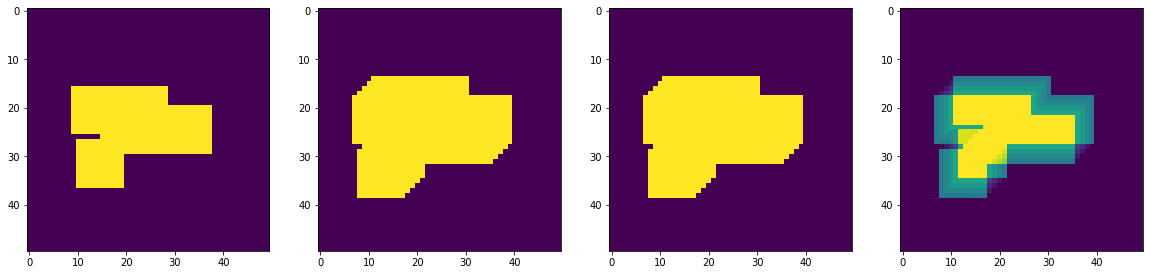

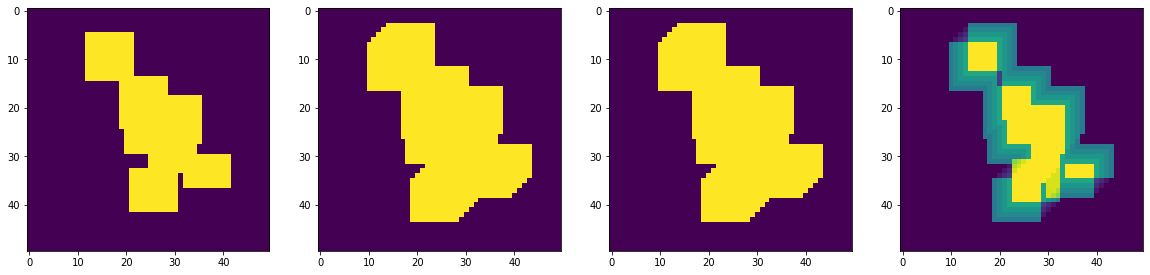

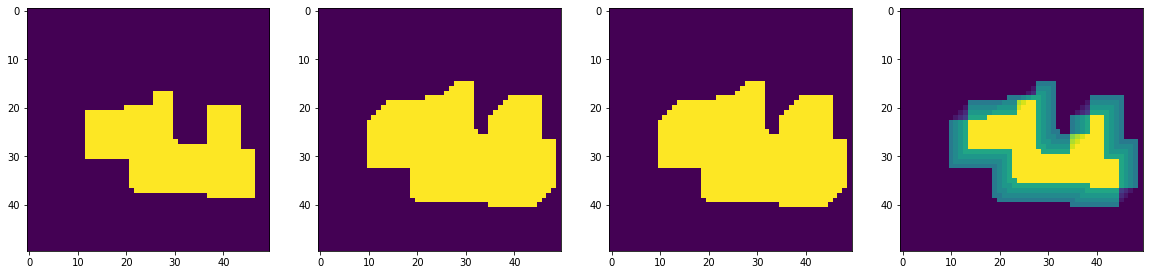

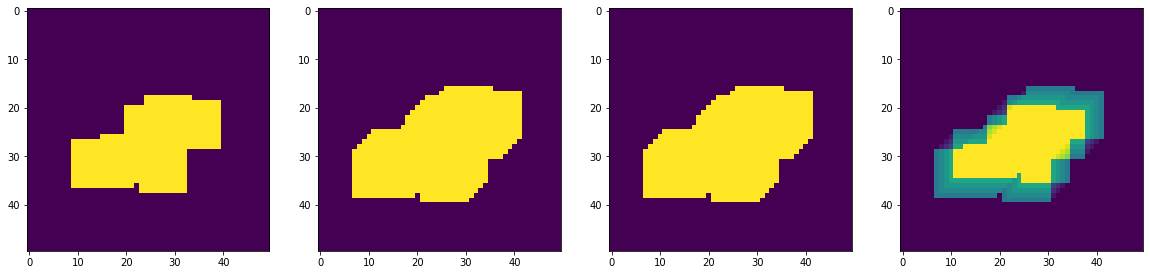

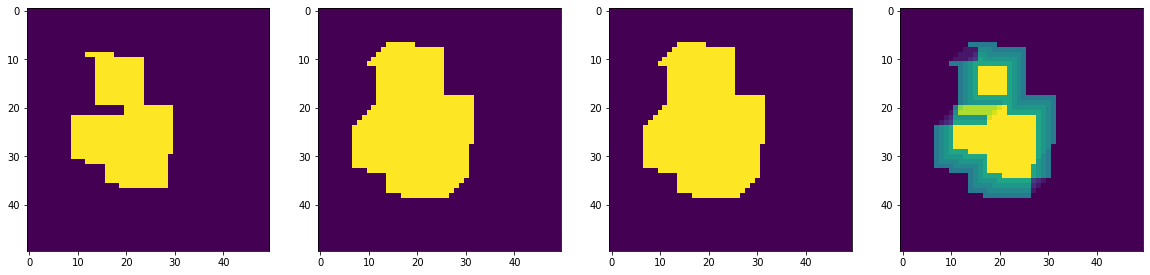

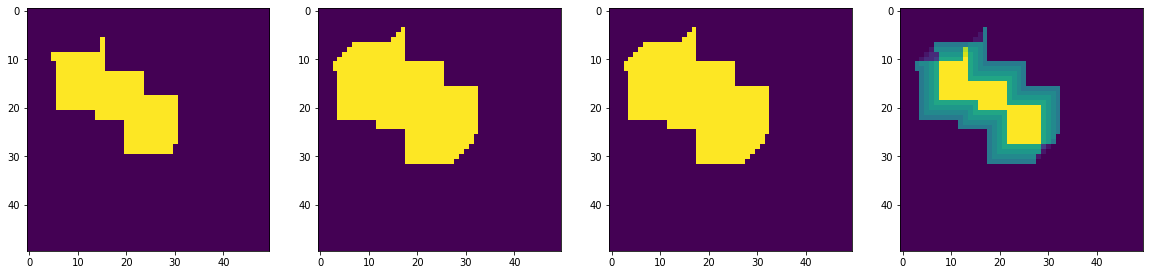

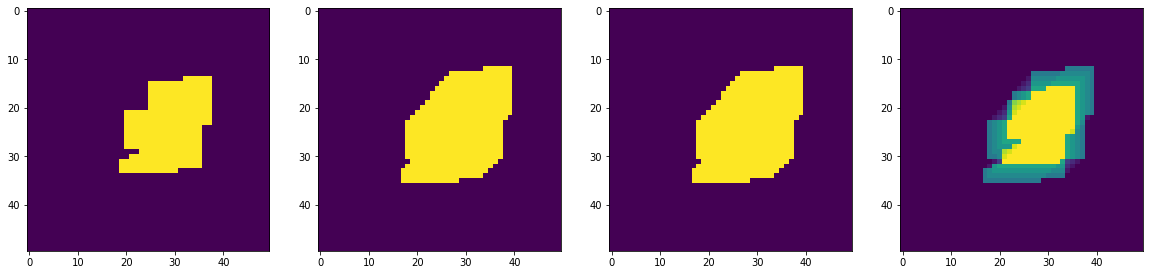

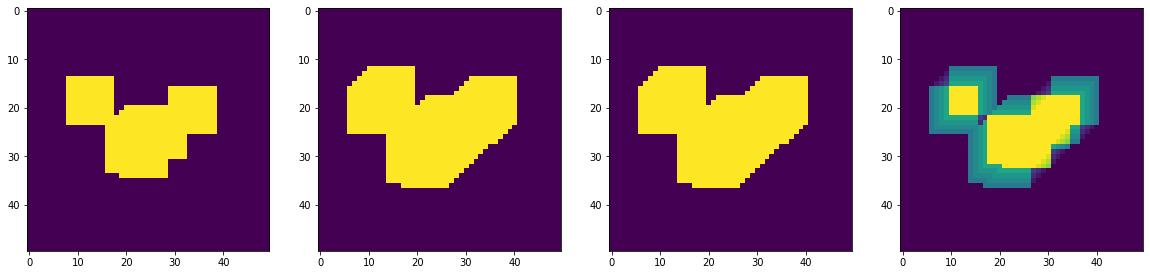

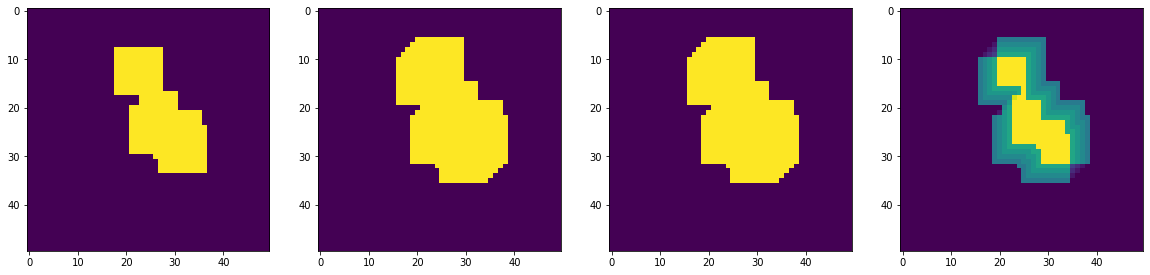

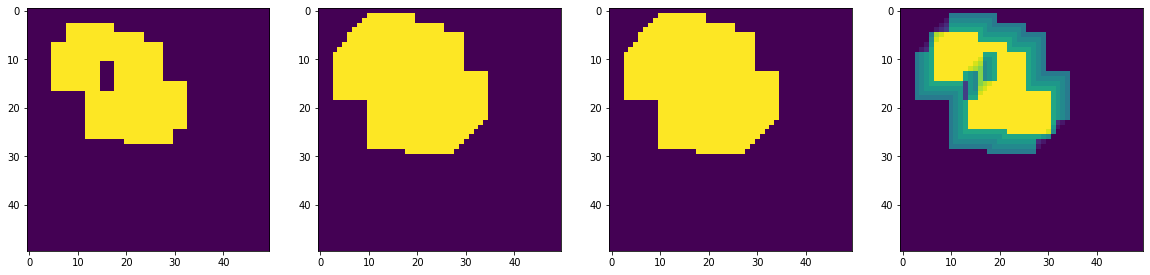

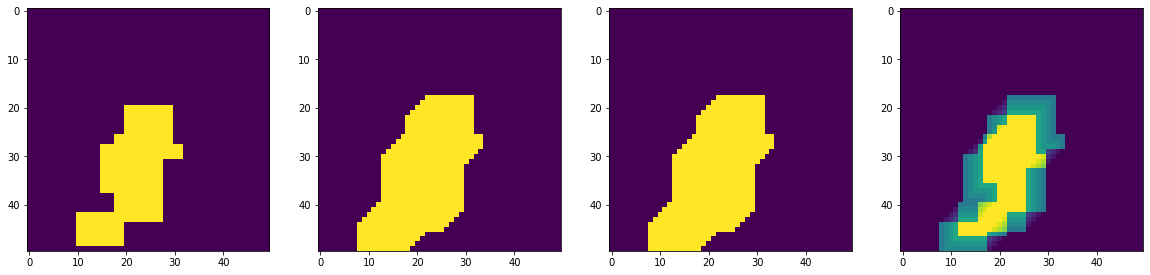

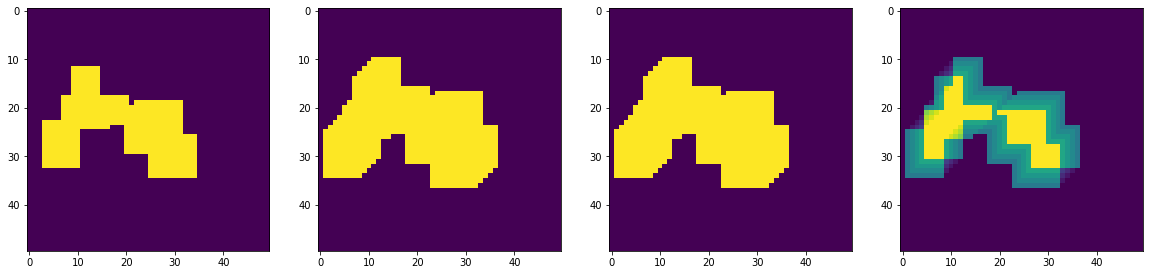

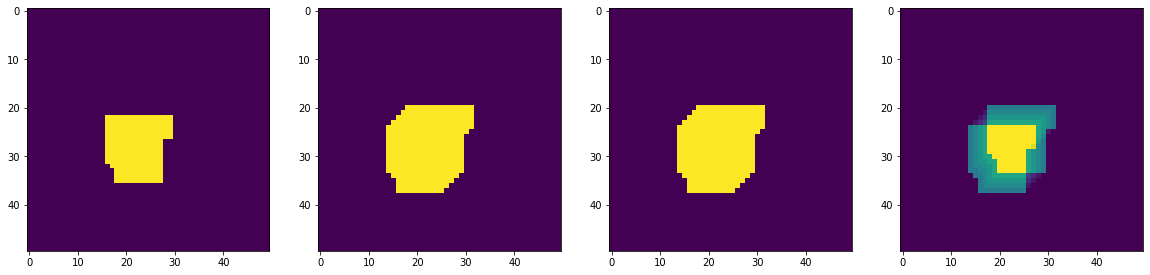

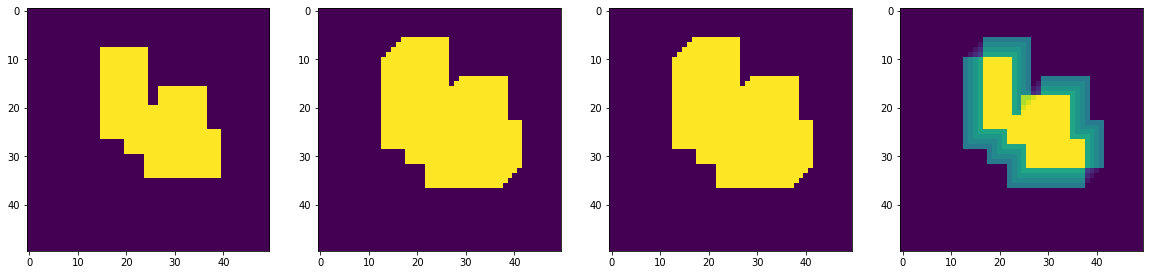

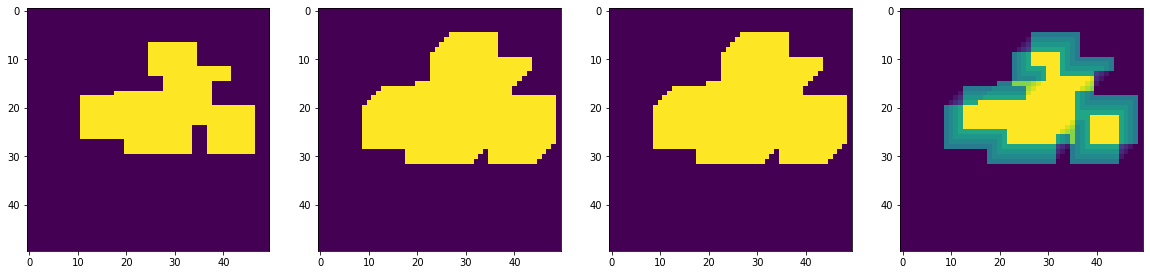

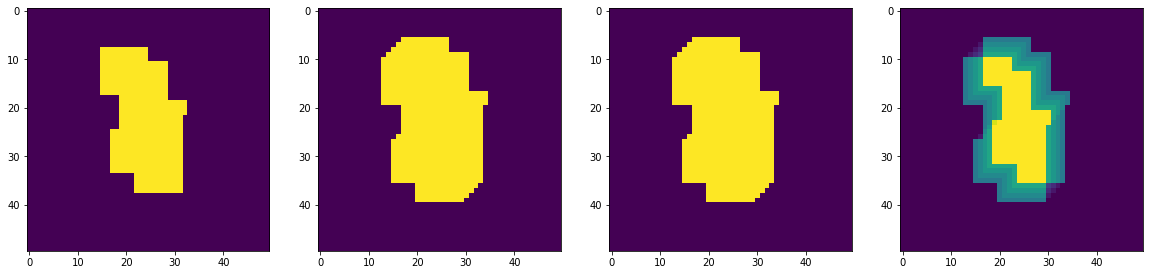

In [113]:
model.to(device)
inputs, targets = next(iter(dataloader))
outputs = model(inputs)
for idx in range(len(inputs)):
    plot_horizontal([tensor[idx].squeeze().cpu().detach() for tensor in [
        inputs, targets, outputs > 0.05, outputs]])

In [110]:
print(model.model.conv.weight)
print(model.model._normalized_weight)
print(model.model.P_)

Parameter containing:
tensor([[[[-0.1435, -0.1434, -0.1436, -0.1433,  0.9307],
          [-0.1434, -0.1434, -0.1434,  0.0202, -0.1433],
          [-0.1435, -0.1433,  0.0130, -0.1434, -0.1434],
          [-0.1433,  0.0191, -0.1431, -0.1431, -0.1435],
          [ 0.9319, -0.1432, -0.1434, -0.1435, -0.1435]]]], device='cuda:0',
       requires_grad=True)
tensor([[[[1.4809e-05, 5.0633e-05, 0.0000e+00, 8.8175e-05, 4.0749e-01],
          [7.8492e-05, 6.5323e-05, 7.1099e-05, 6.2133e-02, 9.0181e-05],
          [3.1579e-05, 8.9384e-05, 5.9403e-02, 5.0689e-05, 6.7584e-05],
          [8.9418e-05, 6.1683e-02, 1.8620e-04, 1.8275e-04, 8.5349e-06],
          [4.0793e-01, 1.2621e-04, 4.5783e-05, 1.2316e-05, 1.6386e-05]]]],
       device='cuda:0', grad_fn=<DivBackward0>)
Parameter containing:
tensor([1.], device='cuda:0', requires_grad=True)


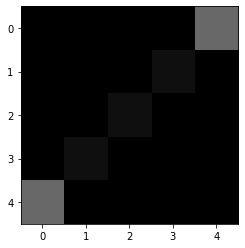

In [109]:
# plt.imshow(torch.sigmoid(model.model.conv.weight).cpu().detach()[0, 0], cmap='gray',
#           vmin=0, vmax=1)
plt.imshow(model.model._normalized_weight.cpu().detach()[0, 0], cmap='gray',
          vmin=0, vmax=1)

## Opening

9.0


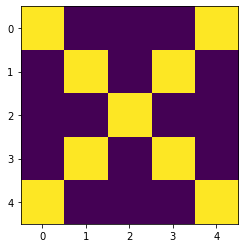

In [16]:
reload_modules()
selem = np.zeros((5, 5))
selem[np.arange(5), 5 - np.arange(1, 6)] = 1
selem[np.arange(5), np.arange(5)] = 1
# selem = morp.disk(2)
plt.imshow(selem)
print(selem.sum())

dataloader = mrda.get_loader(
    batch_size=32, 
    n_inputs=1_000_000, 
    size=(50, 50), 
    n_rectangles=8,
    device=device, 
    max_shape=(10, 10), 
    selem=selem,
    morp_operation="opening",
)

In [17]:
reload_modules()
loss = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam

observables = [
    obs.PlotParametersMultipleDilations(1000),
    obs.PlotPreds(),
    obs.WeightsHistogramMultipleDilations(1000)
]

model = lon.LightningOpeningNet(
    model_args={
        "share_weights": True, "in_channels": 1, "out_channels": 1, "kernel_size": (5, 5)
    },
    learning_rate=1e-2,
    loss=loss,
    optimizer=optimizer,
    output_dir="deep_morpho/results",
    observables=observables
)
model.to(device)

logger = TensorBoardLogger("deep_morpho/results", name='Opening')
print(logger.log_dir)

logger.experiment.add_graph(model, torch.ones(1, 1, 50, 50).to(device))
logger.experiment.add_image("target_SE", selem[np.newaxis, :])

trainer = Trainer(
    max_epochs=1,
    gpus=1 if torch.cuda.is_available() else 0,
    logger=logger,
    progress_bar_refresh_rate=10,
    callbacks=observables.copy()
)

trainer.fit(model, dataloader)


GPU available: True, used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type              | Params
--------------------------------------------
0 | model | OpeningNet        | 56    
1 | loss  | BCEWithLogitsLoss | 0     
--------------------------------------------
56        Trainable params
0         Non-trainable params
56        Total params
0.000     Total estimated model params size (MB)


deep_morpho/results/Opening/version_0


Validation sanity check: 0it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

/hdd/aouadt/these/projets/3d_segm/general/array_morphology.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(ar).unsqueeze(0).unsqueeze(0).float().to(device)


# Activated Space


In [113]:
from scipy.special import factorial, beta, comb

def ratio_activated(Omega):
    S = np.arange(1, Omega+1)
    return 1 / factorial(Omega - S) * beta(S + 1, Omega - S + 1)


Text(0.5, 1.0, 'For all $S$ per card(S). ${card}(\\Omega) =$49')

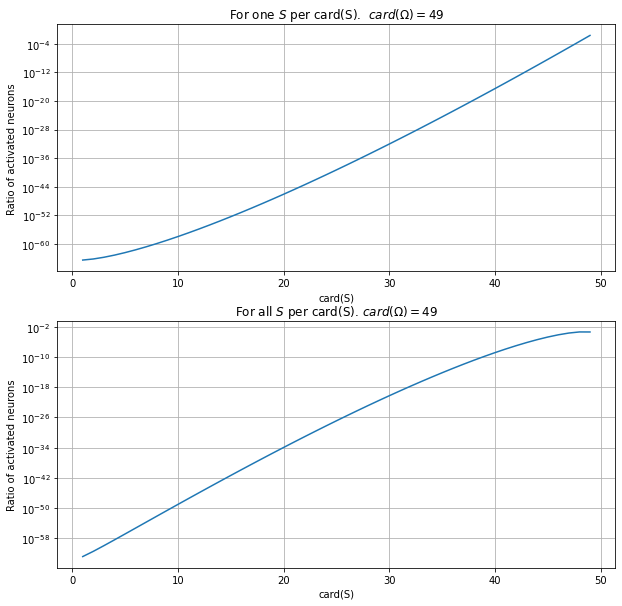

In [146]:
Omega = 49
S = np.arange(1, Omega+1)

plt.figure(figsize=(10, 10))
plt.subplot(211)
plt.plot(S, ratio_activated(Omega))
plt.xlabel('card(S)')
plt.ylabel('Ratio of activated neurons')
plt.yscale('log')
plt.grid()
plt.title(r"For one $S$ per card(S).  ${card}(\Omega) =$" + f"{Omega}")

plt.subplot(212)
plt.plot(S, ratio_activated(Omega)*comb(Omega, np.arange(1, Omega+1)) / np.arange(1, len(S) + 1))
plt.xlabel('card(S)')
plt.ylabel('Ratio of activated neurons')
plt.yscale('log')
plt.grid()
plt.title(r"For all $S$ per card(S). ${card}(\Omega) =$" + f"{Omega}")


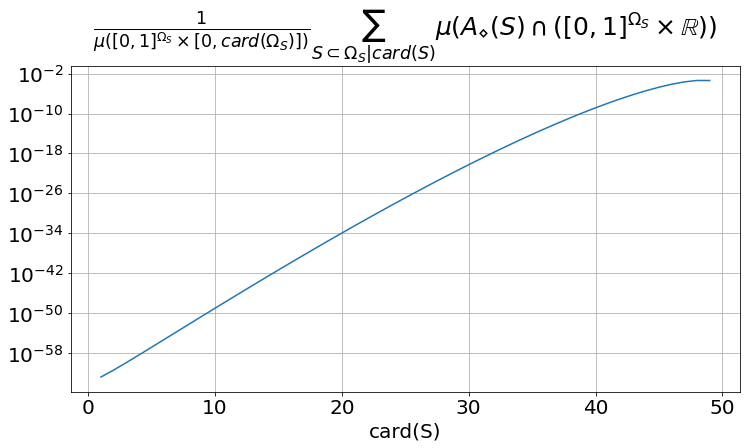

In [194]:
plt.figure(figsize=(12, 6))
plt.plot(S, ratio_activated(Omega)*comb(Omega, np.arange(1, Omega+1)) / np.arange(1, len(S) + 1))
plt.xlabel('card(S)', fontsize=20)
# plt.ylabel('Ratio of activated neurons', fontsize=20)
plt.yscale('log')
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.title(
    (
    	r"$\frac{1}{\mu([0, 1]^{\Omega_S} \times [0, card(\Omega_S)])}\sum_{S \subset \Omega_S | card(S)}\mu(A_{\diamond}(S) \cap ([0, 1]^{\Omega_S} \times \mathbb{R}))$"
        # ",   "
		# r"card$(\Omega_S) =$" + f"{Omega}"
	),
    fontsize=25,
)
plt.grid()
plt.savefig("figures_for_manuscript/chapter5/ratio_activated_on_S.png", bbox_inches='tight', pad_inches=0)
# plt.title(r"${card}(\Omega) =$" + f"{Omega}", fontsize=20)


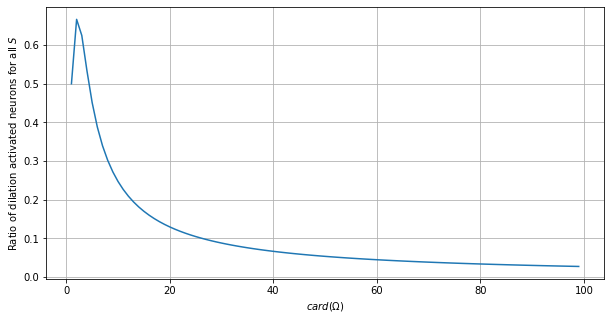

In [115]:
Omegas = np.arange(1, 100)
theory_ratios = np.zeros_like(Omegas).astype(float)
for idx, omega in enumerate(Omegas):
    theory_ratios[idx] = (ratio_activated(omega) * comb(omega, np.arange(1, omega+1))).sum()

plt.figure(figsize=(10, 5))
plt.plot(Omegas, theory_ratios)
plt.xlabel(r'$card(\Omega)$')
plt.ylabel('Ratio of dilation activated neurons for all $S$')
# plt.yscale('log')
plt.grid()

In [154]:
# omegas = np.arange(2, 100)
N = 100000

card_selems = np.zeros((len(Omegas), N))
activated = np.zeros((len(Omegas), N))
dilations = np.zeros((len(Omegas), N))
erosions = np.zeros((len(Omegas), N))

for idx in tqdm(Omegas):
    omga = Omegas[idx]
    W = torch.rand(N, omega, 1, 1)
    B = -torch.rand(N) * omega

    net = lui.LUI(in_channels=omega, out_channels=N, threshold_mode={"weight": "identity", "activation": "tanh"}, bias_optim_mode=bise.BiseBiasOptimEnum.RAW)
    net.set_param_from_weights(W)
    net.set_param_from_bias(B);
    learned_selems, learned_operations, is_activated = net.find_selem_and_operation()
    activated[idx] = is_activated
    card_selems[idx] = learned_selems.reshape(N, -1).sum(axis=1)
    dilations[idx] = (learned_operations == net.operation_code["dilation"]) | (card_selems[idx] == 1)
    erosions[idx] = (learned_operations == net.operation_code["erosion"]) | (card_selems[idx] == 1)
    # is_dilations[idx] = (learned_operations == net.operation_code["dilation"]).sum()

N_activated = activated.sum(axis=1)
N_dilations = dilations.sum(axis=1)
N_erosions = erosions.sum(axis=1)



0it [00:00, ?it/s]

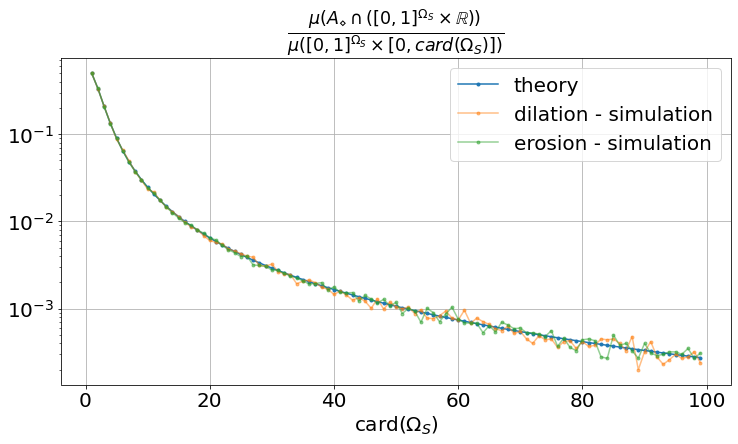

In [193]:
plt.figure(figsize=(12, 6))

# plt.plot(Omegas, N_activated / N, label="activated - simulation", marker=".")
plt.plot(Omegas, theory_ratios / np.arange(1, len(theory_ratios) + 1), label="theory", marker=".", alpha=1)
plt.plot(Omegas, N_dilations / N, label="dilation - simulation", marker=".", alpha=.5)
plt.plot(Omegas, N_erosions / N, label="erosion - simulation", marker=".", alpha=.5)
plt.xlabel(r"card($\Omega_S$)", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.title(
    r"$\frac{\mu(A_{\diamond} \cap ([0, 1]^{\Omega_S} \times \mathbb{R}))}{\mu([0, 1]^{\Omega_S} \times [0, card(\Omega_S)])}$",
    fontsize=25,
)
# plt.title("Ratio of activated neurons")
# plt.ylabel(r"$\mu$")
plt.yscale("log")
# plt.plot(Omegas,)
plt.legend(fontsize=20)
plt.grid()
plt.savefig("figures_for_manuscript/chapter5/ratio_activated_on_omega.png", bbox_inches='tight', pad_inches=0)


# BiMoNN

## BiSE

In [137]:
model = bise.BiSE(
    kernel_size=(7, 7),
    initializer=inits.InitBiseConstantVarianceWeights(input_mean=.5),
    weights_optim_mode=bise_base.BiseWeightsOptimEnum.THRESHOLDED,
    bias_optim_mode=bise.BiseBiasOptimEnum.RAW,
    threshold_mode={"weight": "identity", "activation": "tanh"}
)

loss = nn.BCELoss(reduction="mean")



In [135]:

dataset = mrda.DiskorectDataset(
    random_gen_fn=gfo3.get_random_diskorect_channels,
    random_gen_args={'size': (50, 50), 'n_shapes': 20, 'max_shape': (20, 20), 'p_invert': 0.5, 'n_holes': 10, 'max_shape_holes': (10, 10), 'noise_proba': 0.02, "border": (0, 0)},
    morp_operation=morpop.ParallelMorpOperations.dilation(('disk', 2)),
    len_dataset=1000,
    seed=100,
    do_symetric_output=False,
)

x, _ = dataset[0]
# x = 1 - x

In [124]:
model.weight_threshold_layer

IdentityLayer()

## Bimonn

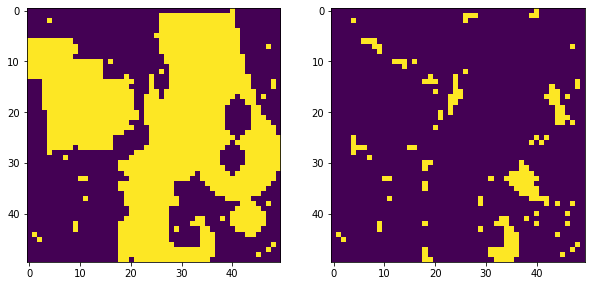

In [7]:
reload_modules()
selem = morp.disk(3)


morp_operation = morpop.ParallelMorpOperations.white_tophat(('disk', 3))

# plot_horizontal(morp_operation.selems, morp_operation.operations)

dataloader = mrda.DiskorectDataset.get_loader(
    batch_size=32, 
    n_inputs=500_000,
    random_gen_fn=gfo3.get_random_diskorect_channels,
    random_gen_args={'size': (50, 50), 'n_shapes': 20, 'max_shape': (20, 20), 
                     'p_invert': 0.5, 'n_holes': 10, 'max_shape_holes': (10, 10), 
                     'noise_proba': 0.02, 'border': (0, 0)},
    device=device,
    morp_operation=morp_operation,
)

img, target = next(iter(dataloader))

plt.figure(figsize=(10, 5))

plt.subplot(121)
plt.imshow(img[0, 0].cpu().detach())

plt.subplot(122)
plt.imshow(target[0, 0].cpu().detach())


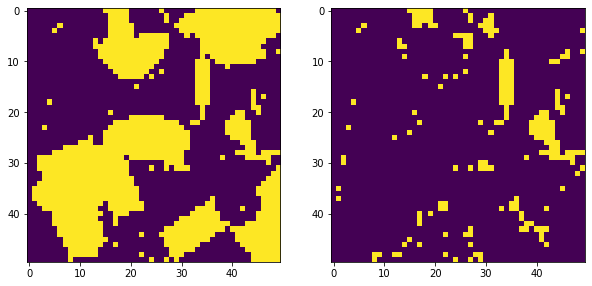

In [5]:
img, target = next(iter(dataloader))

plt.figure(figsize=(10, 5))

plt.subplot(121)
plt.imshow(img[0, 0].cpu().detach())

plt.subplot(122)
plt.imshow(target[0, 0].cpu().detach())


In [20]:

net = bimonn.BiMoNN(
    kernel_size=5,
    channels=[1,500, 500],
    atomic_element="bisel",
    threshold_mode={'activation': "tanh", 'weight': 'softplus'},
    constant_activation_P=False,
    activation_P=1,
    constant_weight_P=True,
    weights_optim_mode=bise_base.BiseWeightsOptimEnum.NORMALIZED,
    initializer_args={"bise_init_method": inits.InitBiseEnum.CUSTOM_CONSTANT_DUAL, "bise_init_args": {}, 'input_mean':.5},
)
net.to(device);

loss_fn = nn.BCELoss()

# otp = net(img.cuda())

# loss_value = loss_fn(otp, target.cuda())
# loss_value.backward()


In [22]:
print(net.numel_float())
print(net.layers.numel_float())

7016000
7016000


In [6]:
%%timeit
net.layers[1].bises.update_closest_selems()

2.06 s ± 20.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [7]:
%%timeit
net.layers[1].bises.update_learned_selems()

376 ms ± 4.41 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [16]:
%%timeit
net.layers[1].binary(update_binaries=True)

2.49 s ± 58.8 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [7]:
otp = net(img.cuda())

loss_value = loss_fn(otp, target.cuda())
loss_value.backward()


ValueError: Using a target size (torch.Size([32, 1, 50, 50])) that is different to the input size (torch.Size([32, 4, 50, 50])) is deprecated. Please ensure they have the same size.

In [8]:
for name, param in net.layer1.bises[0].named_parameters():
    print(param.grad)
# net.layer1.bises[0].weights_handler.grad

AttributeError: 'BiMoNN' object has no attribute 'layer1'

/hdd/aouadt/these/projets/3d_segm/deep_morpho/models/bisel.py:21: UserWarning: __floordiv__ is deprecated, and its behavior will change in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values. To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor').
  m = x // div1


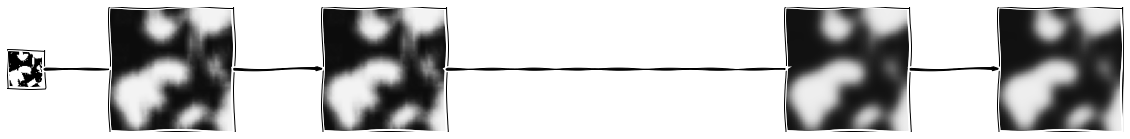

In [12]:
reload_modules()

with plt.xkcd():
    vizf = bimonn_viz.BimonnForwardVizualiser(model=net, inpt=img.cuda())
    vizf.draw(figsize=(20, 10))

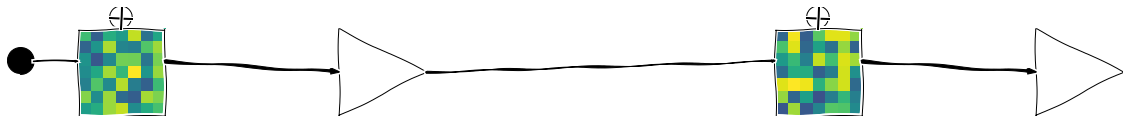

In [12]:
reload_modules()

with plt.xkcd():
    vizf = bimonn_viz.BimonnVizualiser(model=net, mode="weights")
    vizf.draw(figsize=(20, 10))

In [25]:
otp = net.forward_save(img.cuda())

In [21]:
otp[0].keys()

dict_keys([0, (0, 0), 'output'])

In [11]:
new_weight = net.layer2.lui_0.weight + 0
new_weight[0, 0] = 100
net.layer2.lui_0.set_weights(new_weight)

tensor([[100.0000,   0.1165]], device='cuda:0', grad_fn=<CopySlices>)

## Binarization

In [4]:
import deep_morpho_old.models.lightning_bimonn as lbimonn_old
reload(lbimonn_old)

<module 'deep_morpho_old.models.lightning_bimonn' from '/hdd/aouadt/these/projets/3d_segm/deep_morpho_old/models/lightning_bimonn.py'>

In [3]:
reload_modules()
n_classes = 10

def print_params(layer):
    print("binary params:", layer.numel_binary())
    print("learnable params:", sum([param.numel() for param in layer.parameters() if param.requires_grad]))


model_args = {
    "kernel_size": (5, 5),
    "channels": [100, 100, 100],
    "atomic_element": 'bisel',
    "input_size": (1, 28, 28),
    "n_classes": n_classes,
    "threshold_mode": {
        "weight": 'softplus',
        "activation": 'tanh',
    },
    "initializer_method": inits.InitBimonnEnum.INPUT_MEAN,
    "initializer_args": {
        "bise_init_method": inits.InitBiseEnum.CUSTOM_CONSTANT_RANDOM_BIAS,
        "lui_init_method": inits.InitBiseEnum.CUSTOM_CONSTANT_CONSTANT_WEIGHTS_RANDOM_BIAS,
        "bise_init_args": {"ub": 1e-2, "max_output_value": 0.95, "p_for_init": "auto"},
        "input_mean": .5,
    },
    "closest_selem_method": bise_base.ClosestSelemEnum.MIN_DIST_DIST_TO_CST,
    "bias_optim_mode": bise_base.BiseBiasOptimEnum.POSITIVE,
    "bias_optim_args": {"offset": 0},
    "weights_optim_mode": bise_base.BiseWeightsOptimEnum.THRESHOLDED,
    "weights_optim_args": {"constant_P": True, "factor": 1},
}


model = lbimonn.LightningBiMoNNClassifierLastLinearNotBinary(
    learning_rate=1e-1,
    loss=nn.BCELoss(),
    optimizer=optim.Adam,
    model_args=model_args,
)
print_params(model.model)


{'bise_init_method': <InitBiseEnum.CUSTOM_CONSTANT_RANDOM_BIAS: 6>, 'lui_init_method': <InitBiseEnum.CUSTOM_CONSTANT_CONSTANT_WEIGHTS_RANDOM_BIAS: 14>, 'bise_init_args': {'ub': 0.01, 'max_output_value': 0.95, 'p_for_init': 'auto'}, 'input_mean': 0.5}
binary params: 1349400
learnable params: 1350420


In [7]:
help(nn.BCELoss().forward)

Help on method forward in module torch.nn.modules.loss:

forward(input: torch.Tensor, target: torch.Tensor) -> torch.Tensor method of torch.nn.modules.loss.BCELoss instance
    Defines the computation performed at every call.
    
    Should be overridden by all subclasses.
    
    .. note::
        Although the recipe for forward pass needs to be defined within
        this function, one should call the :class:`Module` instance afterwards
        instead of this since the former takes care of running the
        registered hooks while the latter silently ignores them.



In [4]:
model

LightningBiMoNNClassifierLastLinearNotBinary(
  (model): BiMoNNClassifierLastLinearNotBinary(
    (layers): BinarySequential(
      (0): BiSEL(
        (bises): BiSE(
          (conv): Conv2d(1, 100, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), bias=False, padding_mode=replicate)
          (activation_threshold_layer): TanhLayer()
          (bias_handler): BiasSoftplus(
            (softplus_layer): Softplus(beta=1, threshold=20)
          )
          (weights_handler): WeightsThresholdedBise(
            (threshold_layer): SoftplusThresholdLayer()
          )
        )
        (luis): LUI(
          (conv): Conv2d(100, 100, kernel_size=(1, 1), stride=(1, 1), groups=100, bias=False, padding_mode=replicate)
          (activation_threshold_layer): TanhLayer()
          (bias_handler): BiasRaw()
          (weights_handler): WeightsThresholdedBise(
            (threshold_layer): SoftplusThresholdLayer()
          )
        )
      )
      (1): BiSEL(
        (bises): BiSE(
          

In [14]:
from general.nn.pytorch_lightning_module.obs_lightning_module import NetLightning
from deep_morpho.models.generic_lightning_model import GenericLightningModel

In [7]:
model.model.binary()

BimonnDenseNotBinary(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layers): BinarySequential(
    (0): DenseLUI(
      (conv): Conv2d(7840, 200, kernel_size=(1, 1), stride=(1, 1), bias=False, padding_mode=replicate)
      (activation_threshold_layer): TanhLayer()
      (bias_handler): BiasSoftplus(
        (softplus_layer): Softplus(beta=1, threshold=20)
      )
      (weights_handler): WeightsThresholdedBise(
        (threshold_layer): SoftplusThresholdLayer()
      )
    )
    (1): DenseLuiNotBinary(
      (conv): Conv2d(200, 10, kernel_size=(1, 1), stride=(1, 1), bias=False, padding_mode=replicate)
      (activation_threshold_layer): TanhLayer()
      (bias_handler): BiasSoftplus(
        (softplus_layer): Softplus(beta=1, threshold=20)
      )
      (weights_handler): WeightsThresholdedBise(
        (threshold_layer): SoftplusThresholdLayer()
      )
    )
  )
)

In [9]:
model = lbimonn.LightningBiMoNN.load_from_checkpoint(
    "deep_morpho/results/results_tensorboards/Bimonn_exp_77/iccv_ruche/1/mnistclassifchannel/bimonndensenotbinary/version_6/best_weights/epoch=31-step=25023.ckpt"
)
for layer in model.model.layers:
    layer.closest_selem_handler = bcs.BiseClosestActivationSpaceIteratedPositive(bise_module=layer)

# bise_net = model.model.layers[-2].bises
# bise_net.closest_selem_handler = bcs.BiseClosestActivationSpaceIterated(bise_module=bise_net)
# bise_net.update_closest_selems()


In [14]:
model.model.binary()

KeyboardInterrupt: 

In [11]:
bise_net = bise.BiSE(kernel_size=(1, 25))
bise_net.find_selem_and_operation();
bise_net.is_activated.sum()

0

In [12]:
%%timeit
bise_net.binary(update_selems=True, verbose=False)


698 µs ± 9.23 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


In [69]:
bise_net.update_learned_selems()

In [38]:
w0 = bise_net.weights + 0
w0[0, 0] = torch.tensor([
    [0.01, 1, 0.01, 0.01, 1],
    [0.01, 1, 1, 0.01, 0.01],
    [0.01, 0.01, 0.01, 0.01, 0.01],
    [0.01, 0.01, 0.01, 0.01, 0.01],
    [0.01, 0.01, 0.01, 0.01, 0.01],
])
w0[1, 0] = torch.tensor([
    [0.01, 1, 0.01, 0.01, 1],
    [0.01, 1, 1, 0.01, 0.01],
    [1, 0.01, 0.01, 0.01, 0.01],
    [0.01, 0.01, 0.01, 0.01, 0.01],
    [0.01, 0.01, 0.01, 0.01, 0.01],
])
b0 = bise_net.bias + 0
b0[0] = -0.5
b0[1] = -4.5


bise_net.set_param_from_weights(w0)
bise_net.set_param_from_bias(b0)

# bise_net.weights.shape

tensor([-0.4328,  4.4888,  1.0252,  ...,  1.3740,  1.2587,  1.1990],
       grad_fn=<IndexPutBackward0>)

In [6]:
%%timeit
model.model.binary(update_selems=True)

NameError: name 'model' is not defined

In [19]:
S0 = w0[1, 0] > .5
print(bise_net.bias_bounds_erosion(w0[1, 0], S0.detach().cpu().numpy()))


(4.199999809265137, 5.0)


In [29]:
bise_net.find_selem_and_operation()

idx = 0
learnd1 = bise_net.learned_selem[idx] + 0
op1 = bise_net.learned_operation[idx] + 0
act1 = bise_net.is_activated[idx] + 0

learnd2, op2 = bise_net.find_selem_and_operation_chan(idx)
act2 = learnd2 is not None

print(learnd1, learnd2)
print(op1, op2)
print(act1, act2)

[[[0 1 0 0 1]
  [0 1 1 0 0]
  [0 0 0 0 0]
  [0 0 0 0 0]
  [0 0 0 0 0]]] [[[False  True False False  True]
  [False  True  True False False]
  [False False False False False]
  [False False False False False]
  [False False False False False]]]
1.0 dilation
1 True


In [17]:
bise_net.update_closest_selems()

In [63]:
Ws = bise_net.weights
bias = bise_net.bias
S = Ws

bise_net.is_erosion_by_vectorized(Ws, bias, S)[0]
bise_net.is_erosion_by(Ws[0], bias[0], S[0])

banana


ValueError: zero-size array to reduction operation minimum which has no identity

In [39]:
Ws = bise_net.weights
S = bise_net.closest_selem

lbs, ubs = bise_net.bias_bounds_dilation_vectorized(Ws, S)
lb, ub = bise_net.bias_bounds_dilation(Ws[0], S[0])

print(np.abs(lbs[0] - lb).sum()/lb, np.abs(ubs[0] - ub).sum()/ub)

0.0 0.0


In [34]:
Ws = Ws.cpu().detach().numpy().reshape(Ws.shape[0], -1)
S = S.reshape(S.shape[0], -1)

In [36]:
posW = Ws > 0

print(Ws[0][S[0] & (Ws[0] > 0)].sum())
print(np.where(S & posW, Ws, 0).sum(1)[0])

2.7534404
2.7534409


In [9]:
lbs[0] - lb

0.07291336357593536

In [75]:
reload_modules()
bise_net.closest_selem_handler = bcs.BiseClosestMinDistOnCst2(bise_module=bise_net)

In [76]:
bise_net.update_closest_selems()

In [93]:
bise_net.closest_selem.shape

(10000, 5, 5)

In [36]:
%%timeit
bise_net.update_closest_selems()


186 ms ± 3.62 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [69]:
ar1 = np.arange(300*400).reshape(300, 400)
ar2 = np.random.rand(300, 400) > 0.5

In [73]:
print(ar1)
print(ar2)

NameError: name 'Ws' is not defined

In [70]:
%%timeit
np.array([ar1[k, ar2[k]].sum() for k in range(ar1.shape[0])])

1.67 ms ± 14.4 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


In [58]:
ar1[np.arange(30), ar2[:]]

IndexError: too many indices for array: array is 4-dimensional, but 5 were indexed

In [38]:
%%timeit
bise_net.update_learned_selems()


In [10]:
bise_net.binary(update_binaries=True)

BiSE(
  (conv): Conv2d(100, 1000, kernel_size=(28, 28), stride=(1, 1), groups=100, bias=False, padding_mode=replicate)
  (activation_threshold_layer): TanhLayer()
  (bias_handler): BiasSoftplus(
    (softplus_layer): Softplus(beta=1, threshold=20)
  )
  (weights_handler): WeightsThresholdedBise(
    (threshold_layer): SoftplusThresholdLayer()
  )
)

In [14]:
%%timeit
for chan in range(model.model.layers[1].bises.n_elements):
    model.model.layers[1].bises.weight[chan].sum()
# model.model.layers[1].bises.weight.sum()

369 ms ± 29.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [22]:
reload_modules()

# model_args_old = {k: v for k, v in model_args.items()}
# model_args_old[""]

model_old = lbimonn_old.LightningBiMoNNClassifierMaxPoolNotBinary(
    learning_rate=1e-1,
    loss=nn.BCELoss(),
    optimizer=optim.Adam,
    model_args=model_args,
)
print_params(model_old.model)


binary params: 6094
learnable params: 6214


In [43]:
%%timeit
model.model.binary(update_binaries=True)

28.6 s ± 473 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [28]:
print_params(model.layers[0])

binary params: 6100
learnable params: 6100


In [31]:
%%timeit
model.layers[0].binary(update_binaries=True)

852 ms ± 6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


## Bimonn Classifier

In [44]:
model = bimonn.BiMoNNClassifierMaxPoolNotBinary(
    atomic_element="bisel",
    kernel_size=[5, 5, 5],
    n_classes=10,
    input_size=(10, 28, 28),
    channels=[200, 200, 200],
    do_maxpool=True
)

In [40]:
print(model.layers.numel_float())
print(sum([p.numel() for p in model.layers.parameters() if p.requires_grad]))

227220
227220


In [38]:
print(model.classification_layer.numel_binary() + model.layers.numel_binary())
print(model.numel_binary())


424200
226200


In [39]:
print(model.classification_layer.numel_float() + model.layers.numel_float())
print(model.numel_float())


426240
227220


In [45]:
model.numel_binary()

2319200

In [46]:
model.numel_binary() / model.numel_float()

0.999129767966845

In [35]:
model.numel_binary() + model.layers[0].numel_binary()

814200

In [44]:
torch.isin(torch.ones(5), torch.tensor([0, 1]))

tensor([True, True, True, True, True])

In [52]:
np.array([]).mean()

/tmp/ipykernel_22533/1464929575.py:1: RuntimeWarning: Mean of empty slice.
  np.array([]).mean()
/hdd/python_venvs/torchenv/lib/python3.8/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


nan

In [38]:
for child in model.children():
    print(type(child))

<class 'torch.nn.modules.container.Sequential'>
<class 'deep_morpho.models.layers_not_binary.BiSELNotBinary'>


In [34]:
model.layers[0].numel_binary()

28200

In [31]:
model.layers[-1].numel_float()

787020

In [22]:
model

BiMoNNClassifierLastLinearNotBinary(
  (layers): Sequential(
    (0): BiSEL(
      (bises): BiSE(
        (conv): Conv2d(1, 100, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), bias=False, padding_mode=replicate)
        (activation_threshold_layer): TanhLayer()
        (bias_handler): BiasSoftplus(
          (softplus_layer): Softplus(beta=1, threshold=20)
        )
        (weights_handler): WeightsThresholdedBise(
          (threshold_layer): SoftplusThresholdLayer()
        )
      )
      (luis): LUI(
        (conv): Conv2d(100, 100, kernel_size=(1, 1), stride=(1, 1), groups=100, bias=False, padding_mode=replicate)
        (activation_threshold_layer): TanhLayer()
        (bias_handler): BiasRaw()
        (weights_handler): WeightsThresholdedBise(
          (threshold_layer): SoftplusThresholdLayer()
        )
      )
    )
    (1): BiSELNotBinary(
      (bises): BiSE(
        (conv): Conv2d(100, 1000, kernel_size=(28, 28), stride=(1, 1), groups=100, bias=False, padding_mode=re

In [21]:
hasattr(model, "numel_float")

True

# Regularization

In [43]:
D = 49
W = torch.rand(D).unique()
W.requires_grad = True
# B = torch.rand(1, requires_grad=True)
B = torch.tensor([2.], requires_grad=True)

regu = rda.DifferentiableProjectionActivated(weights=W, bias=B)()
loss = regu()

print(loss)

loss.backward()

print(W.grad)
print(B.grad)

print(regu.T)
print(W.grad[regu.T])

print(regu.K)
print(regu.S)

In [6]:
%%timeit
regu = rda.DifferentiableProjectionActivated(weights=W, bias=B)
loss = regu()
loss.backward()

704 ms ± 17.7 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [57]:
loss_regu = rda.RegularizationProjActivated()

# netl = models.LightningBiMoNNClassifierLastLinearNotBinary(
#     model_args={
#         "atomic_element": "bisel",
#         "kernel_size": 3,
#         "channels": [2, 2],
#         "n_classes": 10,
#         "input_size": (10, 5, 5),
#         "closest_selem_handler": bcs.BiseClosestMinDistOnCst,
#     },
#     learning_rate=.1,
#     loss=loss_regu,
#     optimizer=optim.Adam,
# )
model = models.BiMoNN(
    kernel_size=7,
    channels=[1, 1],
    # closest_selem_handler=bcs.BiseClosestActivationSpaceIteratedPositive,
    closest_selem_method=bcs.ClosestSelemEnum.MIN_DIST_ACTIVATED_POSITIVE,
).to(device)

loss_regu.set_model(model);

optimizer = optim.Adam(model.parameters(), lr=1e-1)

In [59]:
loss_regu()

tensor(0.4170, device='cuda:0', grad_fn=<AddBackward0>)

In [61]:
model.layers[0].bises.closest_selem_handler()

(array([[[False, False, False, False, False, False, False],
         [False,  True, False, False, False, False, False],
         [False, False, False, False, False, False, False],
         [False, False, False, False, False, False, False],
         [False, False, False, False, False, False, False],
         [False, False, False, False, False, False, False],
         [False, False, False, False, False, False, False]]]),
 array(['1'], dtype='<U1'),
 array([0.41700044]))

In [48]:
optimizer.zero_grad()
# loss_regu.set_model(model);
loss = loss_regu()
loss.backward()
optimizer.step()

In [49]:
[print(name, p.grad) for name, p in model.named_parameters() if p.requires_grad]

layers.0.bises.activation_threshold_layer.P_ None
layers.0.bises.bias_handler.param tensor([0.3889], device='cuda:0')
layers.0.bises.weights_handler.param tensor([[[[ 0.0027,  0.0022,  0.0015, -0.0708,  0.0010,  0.0017,  0.0020],
          [ 0.0020,  0.0019,  0.0027,  0.0009,  0.0034,  0.0031,  0.0007],
          [ 0.0031,  0.0021,  0.0004,  0.0012,  0.0032,  0.0021,  0.0008],
          [ 0.0017,  0.0022,  0.0027,  0.0035,  0.0034,  0.0015,  0.0020],
          [ 0.0025,  0.0025,  0.0034,  0.0027,  0.0034,  0.0025,  0.0023],
          [ 0.0016,  0.0006,  0.0018,  0.0028,  0.0031,  0.0035,  0.0017],
          [ 0.0029,  0.0007,  0.0021,  0.0017,  0.0032,  0.0019,  0.0003]]]],
       device='cuda:0')
layers.0.luis.activation_threshold_layer.P_ None
layers.0.luis.bias_handler.param None
layers.0.luis.weights_handler.param tensor([[[[0.]]]], device='cuda:0')


[None, None, None, None, None, None]

In [34]:
W = torch.ones(3, 1, 5, 5)
B = torch.ones(3)

weights = []
biases = []

for w, b in zip(W, B):
    weights.append(w.reshape(-1))
    biases.append(-b)


W[0] = W[0] + 2
B[0] = B[0] + 2

In [36]:
biases

[tensor(-1.), tensor(-1.), tensor(-1.)]

## Proj On Constant

In [57]:
# net = models.BiMoNNClassifierLastLinearNotBinary(
#     atomic_element="bisel",
#     kernel_size=3,
#     channels=[50, 50],
#     n_classes=10,
#     input_size=(10, 28, 28),
#     closest_selem_handler=bcs.BiseClosestMinDistOnCst,
# )
loss_old = rdc.RegularizationProjConstantOld()
loss_new = rdc.RegularizationProjConstantNew()


netl = models.LightningBiMoNNClassifierLastLinearNotBinary(
    model_args={
        "atomic_element": "bisel",
        "kernel_size": 3,
        "channels": [50, 50],
        "n_classes": 10,
        "input_size": (10, 28, 28),
        "closest_selem_handler": bcs.BiseClosestMinDistOnCst,
    },
    learning_rate=.1,
    loss=loss_new,
    optimizer=optim.Adam,
)
loss_new.set_model(netl.model)

{'bise_init_method': <InitBiseEnum.CUSTOM_CONSTANT_RANDOM_BIAS: 6>, 'lui_init_method': <InitBiseEnum.CUSTOM_CONSTANT_CONSTANT_WEIGHTS_RANDOM_BIAS: 14>, 'bise_init_args': {'ub': 0.01, 'max_output_value': 0.95, 'p_for_init': 'auto'}, 'input_mean': 0.5}


RegularizationProjConstantNew(
  (model): BiMoNNClassifierLastLinearNotBinary(
    (layers): BinarySequential(
      (0): BiSEL(
        (bises): BiSE(
          (conv): Conv2d(10, 500, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=10, bias=False, padding_mode=replicate)
          (activation_threshold_layer): TanhLayer()
          (bias_handler): BiasSoftplus(
            (softplus_layer): Softplus(beta=1, threshold=20)
          )
          (weights_handler): WeightsThresholdedBise(
            (threshold_layer): SoftplusThresholdLayer()
          )
        )
        (luis): LUI(
          (conv): Conv2d(500, 50, kernel_size=(1, 1), stride=(1, 1), groups=50, bias=False, padding_mode=replicate)
          (activation_threshold_layer): TanhLayer()
          (bias_handler): BiasBiseSoftplusReparametrized(
            (softplus_layer): Softplus(beta=1, threshold=20)
          )
          (weights_handler): WeightsThresholdedBise(
            (threshold_layer): SoftplusThreshol

In [67]:
t1 = torch.rand(5, requires_grad=False)
t2 = torch.rand(5, requires_grad=False)

tc = torch.cat([t1, t2])
t1[0] = 0
tc
# tc.sum().backward()

tensor([0.7859, 0.0756, 0.2820, 0.6915, 0.8281, 0.6292, 0.2681, 0.5693, 0.6752,
        0.7352])

In [64]:
t2.grad

tensor([1., 1., 1., 1., 1.])

In [63]:
t1.grad

/hdd/python_venvs/torchenv/lib/python3.8/site-packages/torch/_tensor.py:1083: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at  aten/src/ATen/core/TensorBody.h:482.)
  return self._grad


In [36]:
isinstance(loss_new, loss_old.__class__)

False

In [53]:
optimizer = optim.Adam(net.parameters(), lr=1e-3)


loss_old.set_model(net)
loss_new.set_model(net)

optimizer.zero_grad()
value_old = loss_old(net)
value_old.backward()
grad_old = copy.deepcopy([(name, p.grad) for name, p in net.named_parameters() if p.requires_grad])

optimizer.zero_grad()
value_new = loss_new(net)
value_new.backward()
grad_new = copy.deepcopy([(name, p.grad) for name, p in net.named_parameters() if p.requires_grad])

print(value_old, value_new)

tensor(4842.5352, grad_fn=<AddBackward0>) tensor(4842.5352, grad_fn=<AddBackward0>)


In [54]:
grad_new

[('layers.0.bises.activation_threshold_layer.P_', None),
 ('layers.0.bises.bias_handler.param',
  tensor([-0.6900, -0.5274, -0.6537, -0.4964, -0.5296, -0.6049, -0.5875, -0.6021,
          -0.5396, -0.6729, -0.5902, -0.7443, -0.6844, -0.6282, -0.5373, -0.5672,
          -0.4410, -0.7263, -0.6712, -0.5275, -0.6627, -0.6781, -0.4382, -0.5696,
          -0.5953, -0.5663, -0.6004, -0.5735, -0.6375, -0.5781, -0.7886, -0.3623,
          -0.5976, -0.6683, -0.6271, -0.6678, -0.5694, -0.5094, -0.5804, -0.4876,
          -0.6883, -0.6311, -0.5971, -0.6839, -0.6112, -0.6290, -0.6434, -0.5422,
          -0.7378, -0.5837, -0.6329, -0.6694, -0.6474, -0.4450, -0.5983, -0.7649,
          -0.6174, -0.6674, -0.4605, -0.6708, -0.6495, -0.5264, -0.5224, -0.6264,
          -0.6226, -0.4918, -0.5844, -0.5787, -0.7514, -0.5306, -0.6545, -0.6391,
          -0.7251, -0.6641, -0.6550, -0.6018, -0.5990, -0.6958, -0.6193, -0.6504,
          -0.5871, -0.6511, -0.4626, -0.6249, -0.5237, -0.7018, -0.5320, -0.6667,
  

In [55]:
grad_old

[('layers.0.bises.activation_threshold_layer.P_', None),
 ('layers.0.bises.bias_handler.param',
  tensor([-0.6900, -0.5274, -0.6537, -0.4964, -0.5296, -0.6049, -0.5875, -0.6021,
          -0.5396, -0.6729, -0.5902, -0.7443, -0.6844, -0.6282, -0.5373, -0.5672,
          -0.4410, -0.7263, -0.6712, -0.5275, -0.6627, -0.6781, -0.4382, -0.5696,
          -0.5953, -0.5663, -0.6004, -0.5735, -0.6375, -0.5781, -0.7886, -0.3623,
          -0.5976, -0.6683, -0.6271, -0.6678, -0.5694, -0.5094, -0.5804, -0.4876,
          -0.6883, -0.6311, -0.5971, -0.6839, -0.6112, -0.6290, -0.6434, -0.5422,
          -0.7378, -0.5837, -0.6329, -0.6694, -0.6474, -0.4450, -0.5983, -0.7649,
          -0.6174, -0.6674, -0.4605, -0.6708, -0.6495, -0.5264, -0.5224, -0.6264,
          -0.6226, -0.4918, -0.5844, -0.5787, -0.7514, -0.5306, -0.6545, -0.6391,
          -0.7251, -0.6641, -0.6550, -0.6018, -0.5990, -0.6958, -0.6193, -0.6504,
          -0.5871, -0.6511, -0.4626, -0.6249, -0.5237, -0.7018, -0.5320, -0.6667,
  

In [10]:
[print(name, p.grad) for name, p in net.named_parameters() if p.requires_grad]

layers.0.bises.activation_threshold_layer.P_ None
layers.0.bises.bias_handler.param None
layers.0.bises.weights_handler.param None
layers.0.luis.activation_threshold_layer.P_ None
layers.0.luis.bias_handler.param None
layers.0.luis.weights_handler.param None
layers.1.bises.activation_threshold_layer.P_ None
layers.1.bises.bias_handler.param None
layers.1.bises.weights_handler.param None
layers.1.luis.activation_threshold_layer.P_ None
layers.1.luis.bias_handler.param None
layers.1.luis.weights_handler.param None
layers.2.bises.activation_threshold_layer.P_ None
layers.2.bises.bias_handler.param tensor([-1.2649, -1.2249, -1.2377, -1.2477, -1.2539, -1.2394, -1.2364, -1.2653,
        -1.2404, -1.2279, -1.2388, -1.2298, -1.2397, -1.2535, -1.2456, -1.2345,
        -1.2301, -1.2435, -1.2342, -1.2305, -1.2548, -1.2259, -1.2382, -1.2523,
        -1.2651, -1.2253, -1.2734, -1.2373, -1.2680, -1.2282, -1.2481, -1.2429,
        -1.2507, -1.2403, -1.2524, -1.2726, -1.2568, -1.2703, -1.2264, -1.2607

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [71]:
loss_old = rdc.RegularizationProjConstantOld()
loss_new = rdc.RegularizationProjConstant()

loss_old.set_model(net);
loss_new.set_model(net);

In [63]:
print(loss_new.weights_list.keys())
print([(len(w), w[0].shape) for w in loss_new.weights_list.values()])

dict_keys([9, 10, 200])
[(2, torch.Size([2000, 9])), (1, torch.Size([200, 10])), (1, torch.Size([200, 200]))]


In [72]:
%%timeit
loss_old()

82.2 ms ± 2.1 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [73]:
%%timeit
loss_new()

77.3 ms ± 1.05 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [17]:
%%timeit
loss_old.set_model(net)

2.81 µs ± 12.1 ns per loop (mean ± std. dev. of 7 runs, 100000 loops each)


In [28]:
%%timeit
loss_new.set_model(net)

186 ms ± 5.12 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [27]:
loss_new.set_model(net)


RegularizationProjConstant(
  (model): BiMoNNClassifierLastLinearNotBinary(
    (layers): BinarySequential(
      (0): BiSEL(
        (bises): BiSE(
          (conv): Conv2d(10, 2000, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=10, bias=False, padding_mode=replicate)
          (activation_threshold_layer): TanhLayer()
          (bias_handler): BiasSoftplus(
            (softplus_layer): Softplus(beta=1, threshold=20)
          )
          (weights_handler): WeightsThresholdedBise(
            (threshold_layer): SoftplusThresholdLayer()
          )
        )
        (luis): LUI(
          (conv): Conv2d(2000, 200, kernel_size=(1, 1), stride=(1, 1), groups=200, bias=False, padding_mode=replicate)
          (activation_threshold_layer): TanhLayer()
          (bias_handler): BiasBiseSoftplusReparametrized(
            (softplus_layer): Softplus(beta=1, threshold=20)
          )
          (weights_handler): WeightsThresholdedBise(
            (threshold_layer): SoftplusThresho

In [10]:
bise_modules = [m for m in net.modules() if isinstance(m, bise_base.BiSEBase)]

In [43]:
Wt = torch.rand(1, 25, requires_grad=True)
bt = torch.rand(1, requires_grad=True)

Wnp = Wt.cpu().detach().numpy()
bnp = bt.cpu().detach().numpy()

In [48]:
Snp, opnp, distnp = pcs.ProjectionConstantSet.compute(Wnp, bnp)

In [49]:
S, op, dist = pcs.ProjectionConstantSet.compute(Wt, bt)

In [64]:
dist.sum().backward()

In [99]:
class OneWeight(nn.Module):
    def __init__(self, weights, bias):
        super().__init__()
        self.weights = nn.Parameter(weights)
        self.bias = nn.Parameter(bias)
    
    def __repr__(self):
        return f"OneWeight(\n\tweights={self.weights},\n\tbias={self.bias}\n)"

In [168]:
Wt = torch.rand(1, 25, requires_grad=True)
bt = torch.rand(1, requires_grad=True)

weights = OneWeight(Wt, bt)
print(weights)

optimizer = optim.SGD(weights.parameters(), lr=1e-1)

all_dists = []
all_Ss = []
all_ops = []

OneWeight(
	weights=Parameter containing:
tensor([[0.7690, 0.9642, 0.9643, 0.9053, 0.2964, 0.6923, 0.8635, 0.4168, 0.8770,
         0.5067, 0.5997, 0.7812, 0.8880, 0.0432, 0.4638, 0.3259, 0.6478, 0.0691,
         0.2485, 0.5118, 0.9644, 0.3426, 0.2897, 0.6804, 0.4307]],
       requires_grad=True),
	bias=Parameter containing:
tensor([0.6087], requires_grad=True)
)


In [169]:

for _ in tqdm(range(100)):
    optimizer.zero_grad()    
    proj = pcs.ProjectionConstantSet(weights.weights, weights.bias).compute(verbose=False)
    proj.final_dist_weight.sum().backward()
    optimizer.step()
    
    all_dists.append(proj.final_dist_weight.sum().item())
    all_Ss.append(proj.S)
    all_ops.append(proj.final_operation)


  0%|          | 0/100 [00:00<?, ?it/s]

OneWeight(
	weights=Parameter containing:
tensor([[7.1816e-01, 7.1816e-01, 7.1816e-01, 7.1816e-01, 6.0380e-11, 7.1816e-01,
         7.1816e-01, 7.1816e-01, 7.1816e-01, 7.1816e-01, 7.1816e-01, 7.1816e-01,
         7.1816e-01, 8.8017e-12, 7.1816e-01, 6.6385e-11, 7.1816e-01, 1.4072e-11,
         5.0624e-11, 7.1816e-01, 7.1816e-01, 6.9792e-11, 5.9008e-11, 7.1816e-01,
         7.1816e-01]], requires_grad=True),
	bias=Parameter containing:
tensor([0.6087], requires_grad=True)
)
['1'] ['1']


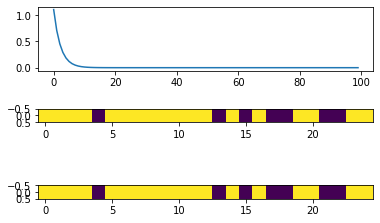

In [170]:
print(weights)
print(all_ops[0], all_ops[-1])
plt.subplot(3, 1, 1)
plt.plot(all_dists)

plt.subplot(3, 1, 2)
plt.imshow(all_Ss[0])

plt.subplot(3, 1, 3)
plt.imshow(all_Ss[-1])

# LogicalNotBise

## Loss for opening

<IPython.core.display.Javascript object>


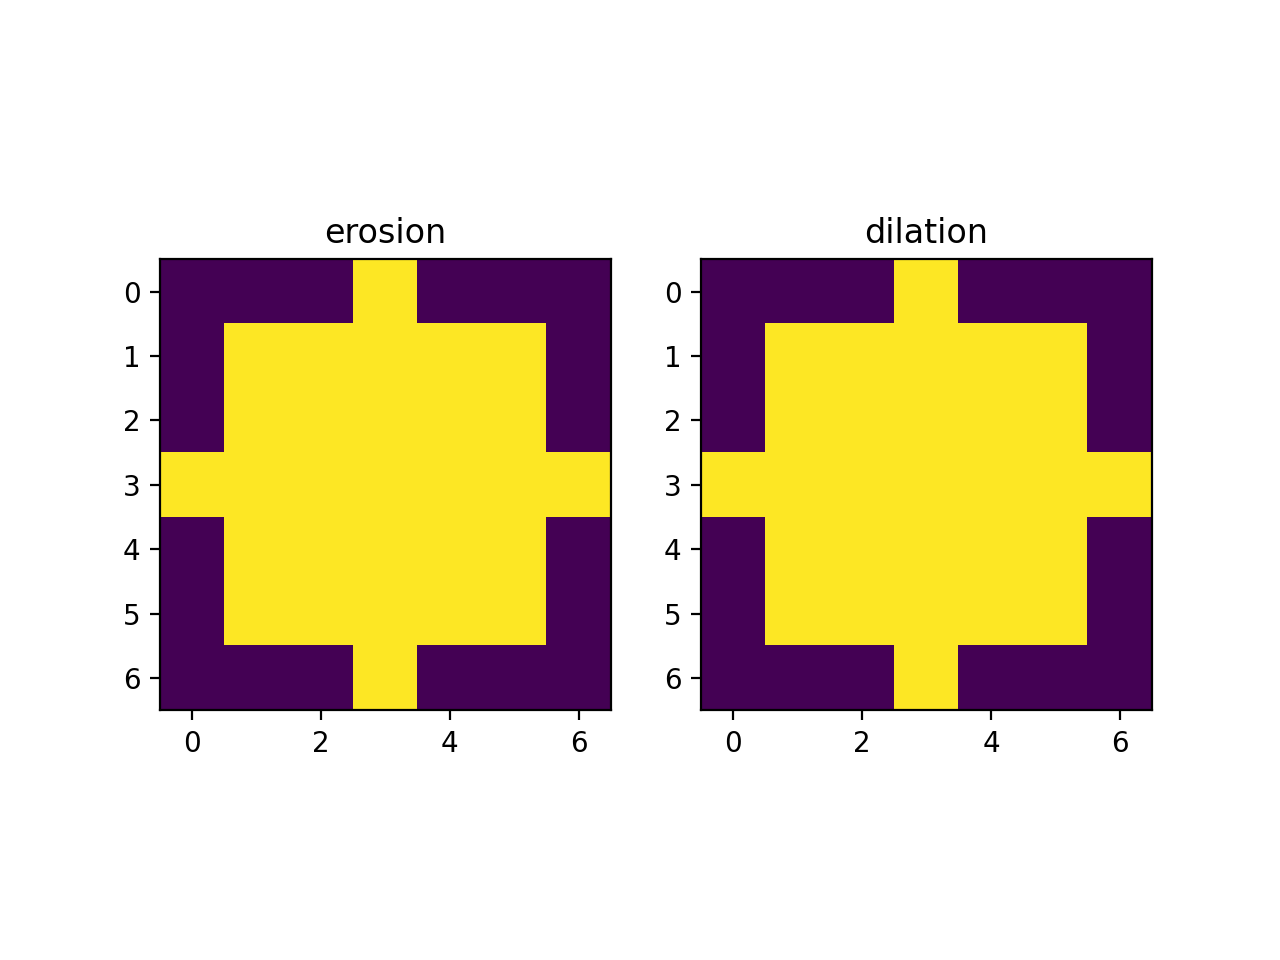

/hdd/aouadt/these/projets/3d_segm/general/array_morphology.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(ar).unsqueeze(0).unsqueeze(0).float().to(device)


In [159]:
reload_modules()

morp_operation = arm.SequentialMorpOperations(
    operations=['erosion', 'dilation'],
    selems=[selm.disk(3), selm.disk(3)],
    device=device,
    name="opening"
)

fig = plt.figure()
for selem_idx, selem in enumerate(morp_operation.selems):
    ax = fig.add_subplot(1, len(morp_operation), selem_idx + 1)
    ax.imshow(selem)
    ax.set_title(morp_operation.operations[selem_idx])

dataloader = mrda.get_loader(
    batch_size=32, 
    n_inputs=500_000,
    random_gen_fn=gfo3.get_random_rotated_diskorect,
    random_gen_args={'size': (50, 50), 'n_shapes': 15, 'max_shape': (15, 15), 'p_invert': .5},
    device=device, 
    selem=selem,
    morp_operation=morp_operation.morp_fn,
)

img, target = next(iter(dataloader))
img.requires_grad = False
target.requires_grad = False

In [161]:
%%time

reload_modules()
alphas = np.linspace(-5, 5, 100)
loss_values2 = []
loss = nn.BCELoss()
# for idx1, alpha1 in tqdm(enumerate(alphas)):

loss_values = np.zeros((len(alphas), len(alphas)))
with torch.no_grad():
    for idx1, alpha1 in tqdm(enumerate(alphas)):
    # for alpha1 in [-10]:
        for idx2, alpha2 in enumerate(alphas):
    #     for alpha2 in [-10]:
            net_dil = bimonn.BiMoNN(
                kernel_size=[(7, 7), (7, 7)], 
                logical_not=True, 
                activation_P=[20, 20], 
                alpha_init=[alpha1, alpha2],
#                 threshold_mode={"activation": "tanh", "weight": "tanh", "logical_not": "clamp"}
                threshold_mode="tanh"
            )
            for layer in net_dil.bises:
                layer.conv.weight.data = torch.FloatTensor(
                    morp_operation.selems[0].astype(float) * 10 - 5
                ).unsqueeze(0).unsqueeze(0)
            net_dil.to(device)

            with torch.no_grad():
    #             loss_values2.append(loss(net_dil(img).squeeze(), target).detach().item())
                loss_values[idx1, idx2] = loss(net_dil(img).squeeze(), target).detach().item()

100it [00:22,  4.38it/s]

CPU times: user 22.8 s, sys: 0 ns, total: 22.8 s
Wall time: 22.9 s


<IPython.core.display.Javascript object>


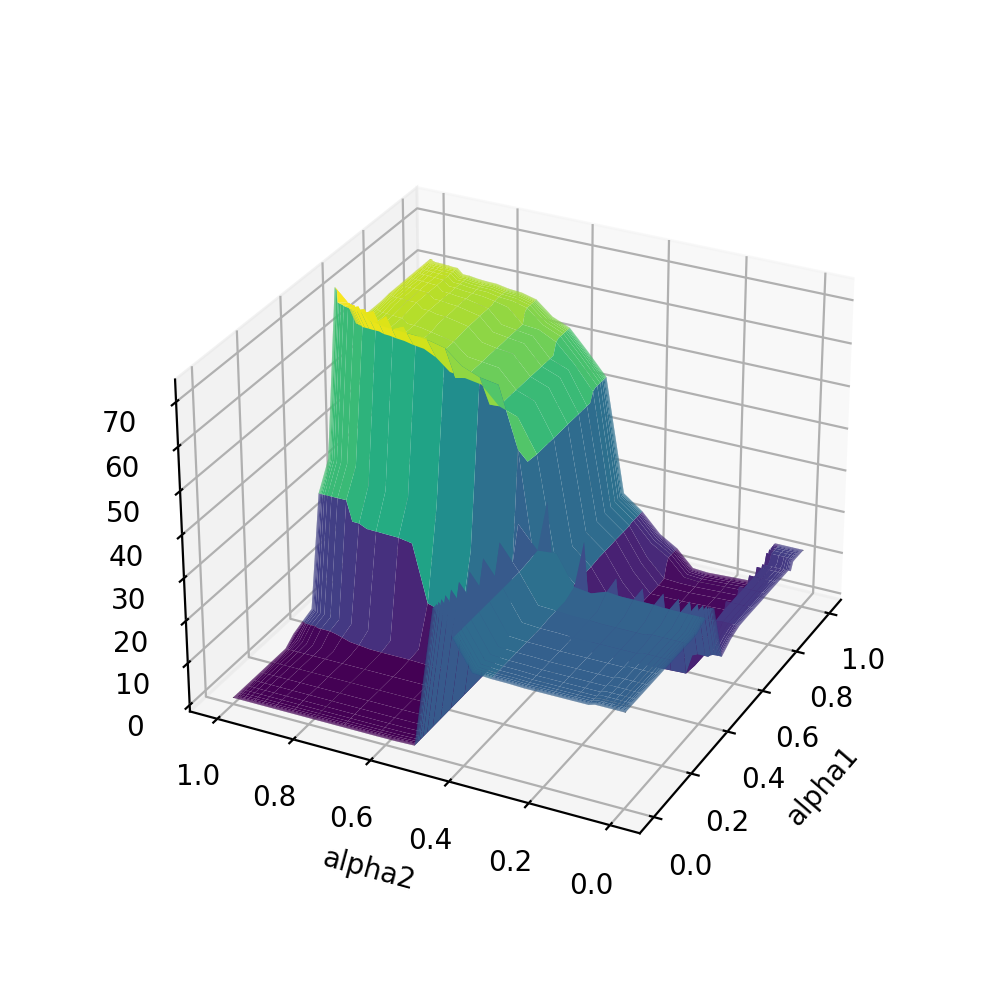

Text(0.5, 0, 'alpha2')

In [165]:
from mpl_toolkits import mplot3d
fig = plt.figure(figsize=(5, 5))

ax = plt.axes(projection='3d')

XX, YY = np.meshgrid(
    net_dil.bises[0].logical_not_layer.threshold_layer(torch.tensor(alphas)), 
    net_dil.bises[0].logical_not_layer.threshold_layer(torch.tensor(alphas)), 
#     alphas,
#     alphas
)
ax.plot_surface(YY, XX, loss_values, 
                cmap='viridis', edgecolor='none')
ax.set_xlabel("alpha1")
ax.set_ylabel("alpha2")

In [125]:
reload_modules()
net = bimonn.BiMoNN(
    kernel_size=[7, 7],
    logical_not=True,
    activation_P=20,
    alpha_init=[0, 1],
    threshold_mode={"activation": "tanh", "weight": "tanh", "logical_not": "clamp"},
)

for layer in net.bises:
    layer.conv.weight.data = torch.FloatTensor(
        morp_operation.selems[0].astype(float) * 10 - 5
    ).unsqueeze(0).unsqueeze(0)
    layer.conv.weight.data *= 5
net.to(device)

BiMoNN(
  (layer1): LogicalNotBiSE(
    (conv): Conv2d(1, 1, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), bias=False)
    (weight_threshold_layer): TanhLayer()
    (activation_threshold_layer): TanhLayer()
    (logical_not_layer): LogicalNotLayer(
      (threshold_layer): ClampLayer()
    )
  )
  (layer2): LogicalNotBiSE(
    (conv): Conv2d(1, 1, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), bias=False)
    (weight_threshold_layer): TanhLayer()
    (activation_threshold_layer): TanhLayer()
    (logical_not_layer): LogicalNotLayer(
      (threshold_layer): ClampLayer()
    )
  )
)

In [117]:
net.bises[0]._normalized_weight

tensor([[[[0., 0., 0., 1., 0., 0., 0.],
          [0., 1., 1., 1., 1., 1., 0.],
          [0., 1., 1., 1., 1., 1., 0.],
          [1., 1., 1., 1., 1., 1., 1.],
          [0., 1., 1., 1., 1., 1., 0.],
          [0., 1., 1., 1., 1., 1., 0.],
          [0., 0., 0., 1., 0., 0., 0.]]]], device='cuda:0',
       grad_fn=<AddBackward0>)

In [118]:
def alpha_to(model, bise_idx, alpha_value):
    model.bises[bise_idx].logical_not_layer.alpha.requires_grad = False
    model.bises[bise_idx].logical_not_layer.alpha.fill_(alpha_value)


In [119]:
inter1.max()

tensor(0.9000, device='cuda:0')

inter1 in  0.0 1.0
inter2 in  0.0 1.0


<IPython.core.display.Javascript object>


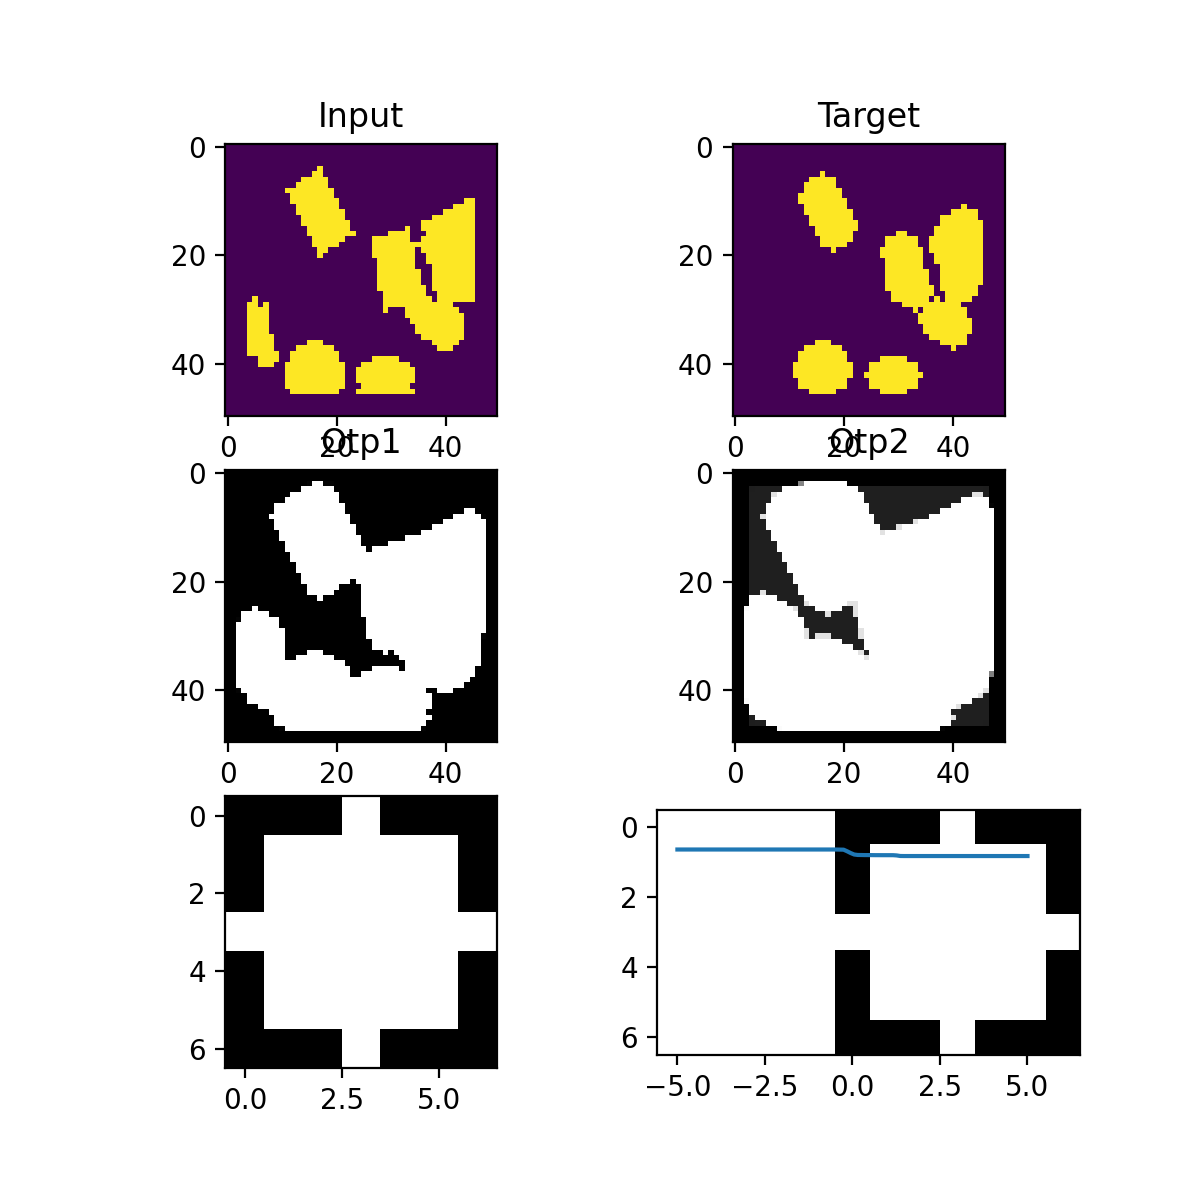

5

In [128]:
alpha_to(net, 0, 0.7)
alpha_to(net, 1, 0.55)

with torch.no_grad():
    inter1 = net.bises[0](img).detach()
    inter2 = net.bises[1](inter1).detach()

print("inter1 in ", inter1.min().item(), inter1.max().item())
print("inter2 in ", inter2.min().item(), inter2.max().item())
    
fig, ax = plt.subplots(3, 2, figsize=(6, 6))

ax[0, 0].imshow(img[0, 0].cpu())
ax[0, 1].imshow(target[0].cpu())
ax[0, 0].set_title("Input")
ax[0, 1].set_title("Target")

ax[1, 0].imshow(inter1[0, 0].cpu(), vmin=0, vmax=1, cmap='gray')
ax[1, 1].imshow(inter2[0, 0].cpu(), vmin=0, vmax=1, cmap='gray')
ax[1, 0].set_title("Otp1")
ax[1, 1].set_title("Otp2")

ax[2, 0].imshow(net.bises[0]._normalized_weight.squeeze().detach().cpu(), vmin=0, vmax=1, cmap="gray")
ax[2, 1].imshow(net.bises[1]._normalized_weight.squeeze().detach().cpu(), vmin=0, vmax=1, cmap="gray")
5

## Loss for erosion

<IPython.core.display.Javascript object>


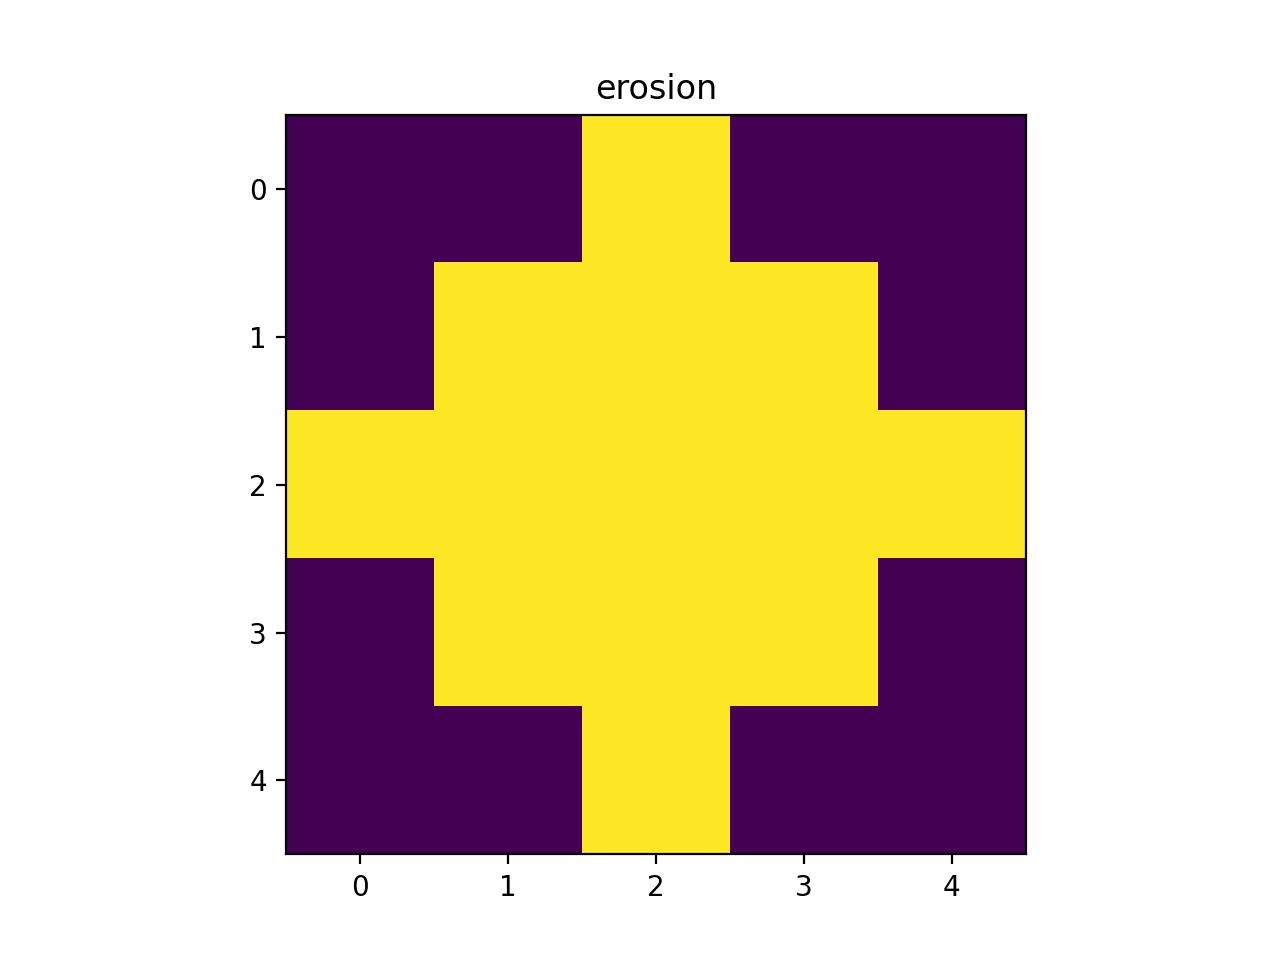

torch.Size([352, 1, 50, 50])


In [80]:
reload_modules()

morp_operation = arm.SequentialMorpOperations(
    operations=['erosion'],
    selems=[selm.disk(2)],
    device=device,
    name="opening"
)

fig = plt.figure()
for selem_idx, selem in enumerate(morp_operation.selems):
    ax = fig.add_subplot(1, len(morp_operation), selem_idx + 1)
    ax.imshow(selem)
    ax.set_title(morp_operation.operations[selem_idx])

dataloader = mrda.get_loader(
    batch_size=32, 
    n_inputs=500_000,
    random_gen_fn=gfo3.get_random_rotated_diskorect,
    random_gen_args={'size': (50, 50), 'n_shapes': 15, 'max_shape': (15, 15), 'p_invert': .5},
    device=device, 
    selem=selem,
    morp_operation=morp_operation.morp_fn,
)

img, target = next(iter(dataloader))
for _ in range(10):
    im2, target2 = next(iter(dataloader))
    img = torch.cat((img, im2))
    target = torch.cat((target, target2))
img.requires_grad = False
target.requires_grad = False

print(img.shape)

In [81]:
%%time

reload_modules()
alphas = np.linspace(-5, 5, 100)
loss = nn.BCELoss()

grad_values = np.zeros((len(alphas)))
loss_values = np.zeros((len(alphas)))
for idx1, alpha1 in tqdm(enumerate(alphas)):
    net_dil = bimonn.BiMoNN(
        kernel_size=[(5, 5)], 
        logical_not=True, 
        activation_P=[10], 
        alpha_init=[alpha1],
#                 threshold_mode={"activation": "tanh", "weight": "tanh", "logical_not": "clamp"}
        threshold_mode="tanh"
    )
    for layer in net_dil.bises:
        layer.conv.weight.data *= -5
#         layer.conv.weight.data = torch.FloatTensor(
#             morp_operation.selems[0].astype(float) * 10 - 5
#         ).unsqueeze(0).unsqueeze(0)
    net_dil.to(device)

    loss_v = loss(net_dil(img).squeeze(), target)
    loss_v.backward()
    grad_values[idx1] = net_dil.bises[0].alpha.grad
    loss_values[idx1] = loss_v.detach().item()

100it [00:00, 204.64it/s]

CPU times: user 499 ms, sys: 0 ns, total: 499 ms
Wall time: 498 ms


<IPython.core.display.Javascript object>


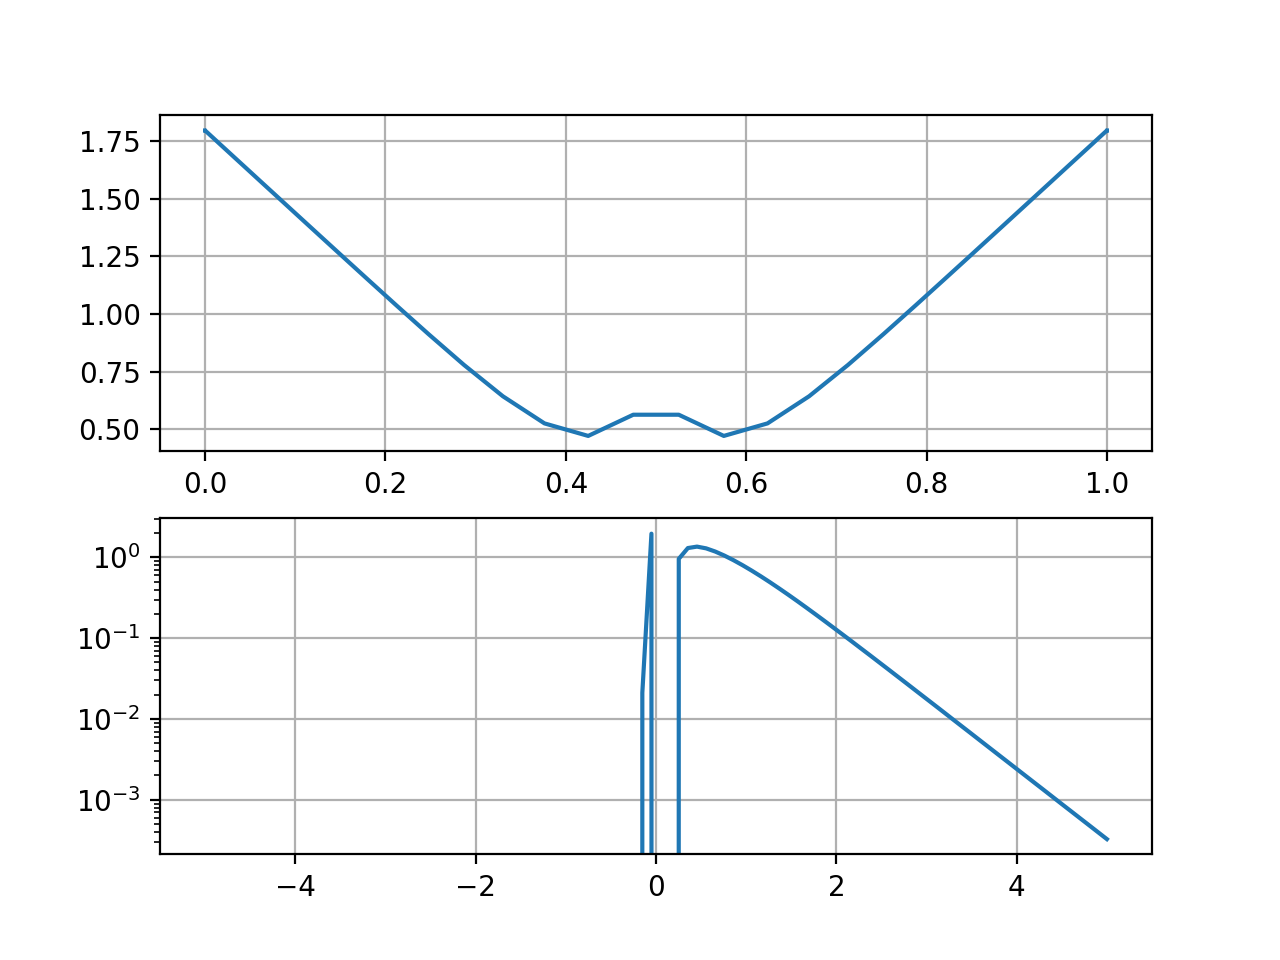

In [83]:
fig = plt.figure()

ax = fig.add_subplot(211)
ax.plot(
    net_dil.bises[0].logical_not_layer.threshold_layer(torch.tensor(alphas)), 
#     alphas,
    loss_values
)
ax.grid()
# ax.set_yscale('log')

ax = fig.add_subplot(212)
ax.plot(
    alphas, 
#     net_dil.bises[0].logical_not_layer.threshold_layer(torch.tensor(alphas)), 
    grad_values,
)
ax.set_yscale('log')
ax.grid()

In [58]:
net_dil.bises[0].conv.padding_mode

'zeros'

# BiMoNN Init

## Segmentation

In [31]:
reload_modules()

morp_operation = morpop.ParallelMorpOperations.black_tophat(('dcross', 7))

# plot_horizontal(morp_operation.selems, morp_operation.operations)

dataloader = mrda.DiskorectDataset.get_loader(
    batch_size=256, 
    n_inputs=500_000,
    random_gen_fn=gfo3.get_random_diskorect_channels,
    random_gen_args={'size': (50, 50), 'n_shapes': 20, 'max_shape': (20, 20), 
                     'p_invert': 0, 'n_holes': 10, 'max_shape_holes': (10, 10), 
                     'noise_proba': 0.02, "border": (0, 0)},
    device=device,
    morp_operation=morp_operation,
    do_symetric_output=False,
)

img, target = next(iter(dataloader))
img.mean()



tensor(0.4603)

In [32]:
%%time
reload_modules()
model = bimonn.BiMoNN(
    kernel_size=[7, 7, 7, 7, 7],
    channels=[1,4, 4, 4, 4, 1],
    # kernel_size=[7, 7],
    # channels=[1, 1, 1],
    # channels=[1,3, 3, 3, 1],
    atomic_element='bisel',
    threshold_mode={'weight': 'softplus', 'activation': 'tanh'},
    activation_P=1,
    initializer_method=inits.InitBimonnEnum.INPUT_MEAN,
    initializer_args={
            # "bise_init_method": InitBiseEnum.CUSTOM_CONSTANT,
            # "bise_init_method": inits.InitBiseEnum.CUSTOM_HEURISTIC_RANDOM_BIAS,
            "bise_init_method": inits.InitBiseEnum.CUSTOM_CONSTANT_RANDOM_BIAS,
            "lui_init_method": inits.InitBiseEnum.CUSTOM_CONSTANT_CONSTANT_WEIGHTS_RANDOM_BIAS,
            "bise_init_args": {"mean_weight": "auto", "ub": 1e-4, },
            "input_mean": 0.5
        },
    bias_optim_mode=bise_base.BiseBiasOptimEnum.RAW,
    bias_optim_args={"offset": 0},
    weights_optim_mode=bise_base.BiseWeightsOptimEnum.THRESHOLDED,
    weights_optim_args={"constant_P": True, "factor": 1},
)
model.cuda()
pass


{'bise_init_method': <InitBiseEnum.CUSTOM_CONSTANT_RANDOM_BIAS: 6>, 'lui_init_method': <InitBiseEnum.CUSTOM_CONSTANT_CONSTANT_WEIGHTS_RANDOM_BIAS: 14>, 'bise_init_args': {'mean_weight': 'auto', 'ub': 0.0001}, 'input_mean': 0.5}
CPU times: user 38.9 ms, sys: 20.7 ms, total: 59.5 ms
Wall time: 58.2 ms


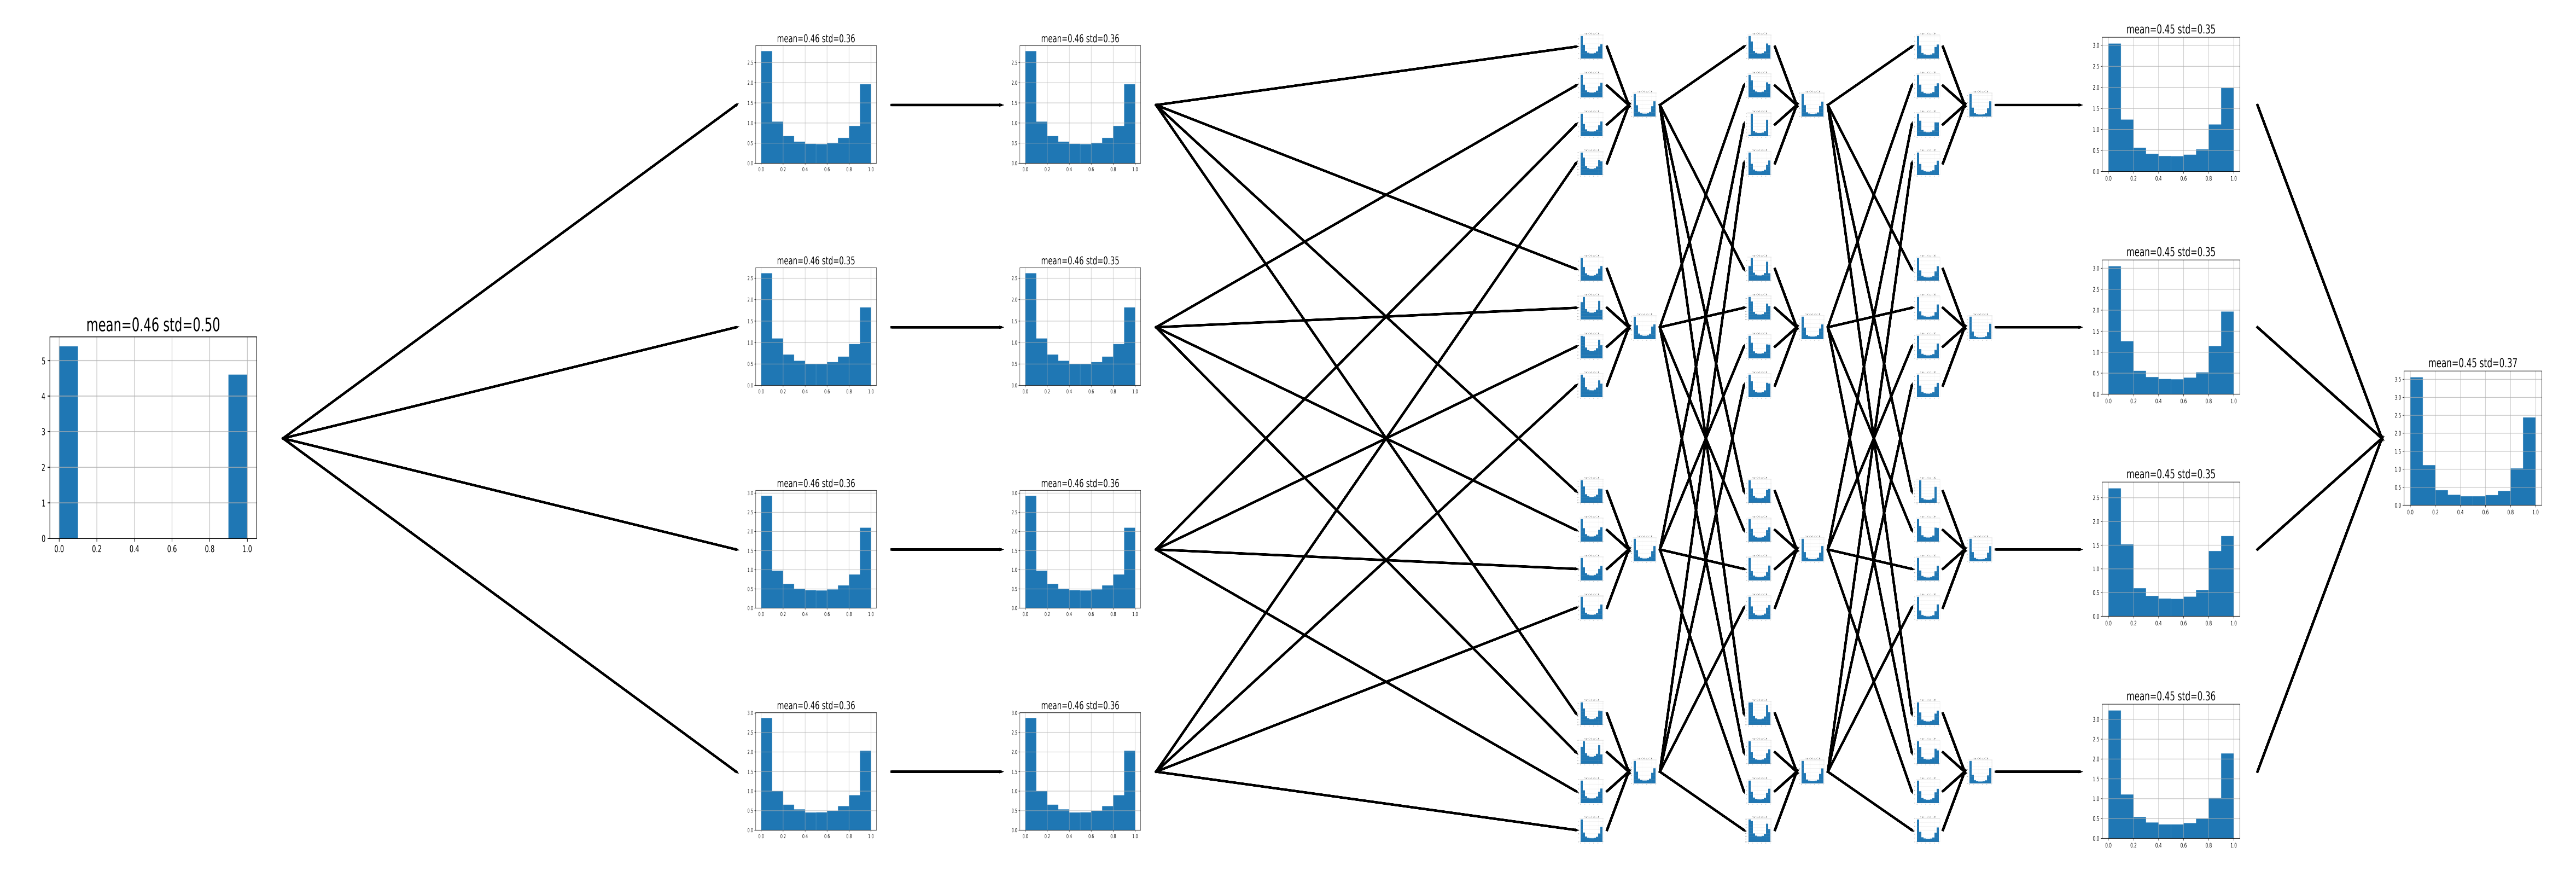

In [34]:
reload_modules()
viz_hist = bimonn_viz.BimonnHistogramVizualiser(model=model, inpt=img.cuda(), dpi=300);
viz_hist.draw(figsize=(20, 10), dpi=300)


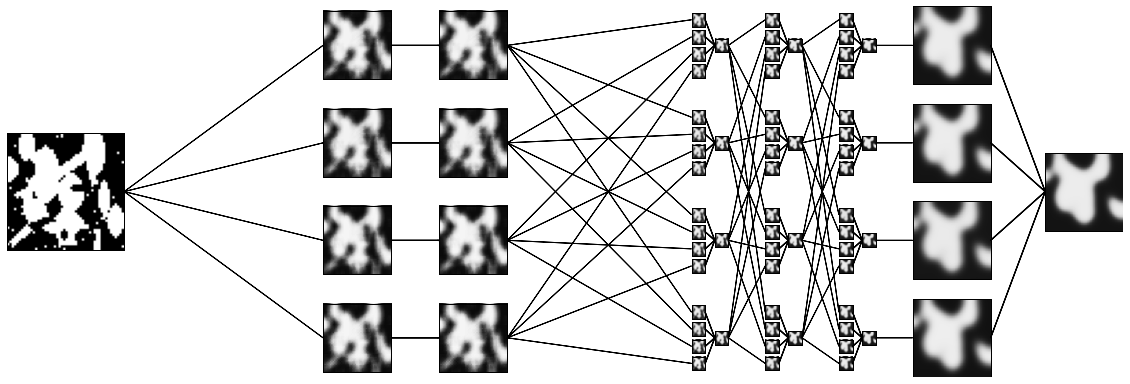

In [35]:
vizf = bimonn_viz.BimonnForwardVizualiser(model=model, inpt=img.cuda())
vizf.draw(figsize=(20, 10))

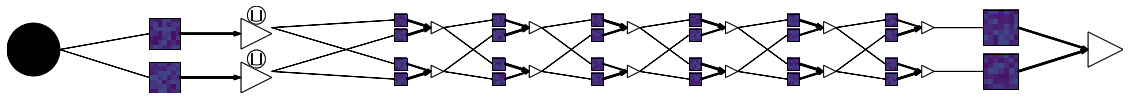

In [76]:
bimonn_viz.BimonnVizualiser(model).draw(figsize=(20, 10))


## Classification

In [29]:
reload_modules()


# plot_horizontal(morp_operation.selems, morp_operation.operations)

dataloader = MnistClassifDataset.get_loader(
    n_inputs=1000,
    train=True,
    batch_size=64,
    shuffle=True,
    num_workers=0,
    threshold=30,
    invert_input_proba=0,
)

img, target = next(iter(dataloader))
img.mean()



tensor(0.1756)

In [40]:
img = (torch.randint(0, 2, (256, 1, 28, 28))).float()

In [54]:
%%time
reload_modules()
model2 = bimonn.BiMoNNClassifier(
    kernel_size=[3, 3],
    channels=[1, 6, 1],
    n_classes=10,
    input_size=28,
    init_weight_mode=bise.InitBiseEnum.CUSTOM_CONSTANT,
    # channels=[1,3, 3, 3, 1],
    activation_P=1,
    # init_bias_value=img.mean(),
    init_bias_value_bise="auto",
    init_bias_value_lui=1.6,
    input_mean=img.mean(),
)
# model2 = LightningBiMoNNClassifier(
#     model_args={
#         "kernel_size":[3, 3],
#         "channels":[1, 6, 1],
#         "n_classes":10,
#         "input_size":28,
#         # "#":channels=[1,3, 3, 3, 1],
#         "activation_P":10,
#         "init_bias_value":img.mean(),
#     }
# )
model2.cuda()
pass


AssertionError: tensor([[[[-0.0464, -0.0471,  0.0117,  ...,  0.0050,  0.0689, -0.0404],
          [ 0.0793, -0.0039, -0.0701,  ...,  0.0622,  0.0727, -0.0303],
          [-0.0125,  0.0551, -0.0101,  ..., -0.0294,  0.0361, -0.0527],
          ...,
          [ 0.0905, -0.0095, -0.0127,  ...,  0.0050,  0.0493,  0.0817],
          [ 0.0514,  0.0792, -0.0501,  ..., -0.0364,  0.0113, -0.0213],
          [ 0.0175,  0.0123, -0.0265,  ...,  0.0770,  0.0224, -0.0798]]],


        [[[-0.0637,  0.0131,  0.0185,  ..., -0.0613, -0.0678, -0.0410],
          [-0.0690,  0.0551, -0.0328,  ...,  0.0438, -0.0255, -0.0595],
          [-0.0509,  0.0382, -0.0078,  ..., -0.0802, -0.0333,  0.0257],
          ...,
          [-0.0599,  0.0831, -0.0493,  ...,  0.0847,  0.0222, -0.0309],
          [ 0.0747, -0.0329,  0.0685,  ..., -0.0632, -0.0129,  0.0668],
          [-0.0567,  0.0410,  0.0913,  ...,  0.0516, -0.0308, -0.0383]]],


        [[[-0.0722,  0.0623, -0.0079,  ...,  0.0421,  0.0171,  0.0158],
          

In [36]:
model2.input_mean

[tensor(0.4990), 0.5]

In [32]:
curl = model2.layers[-1].bise_0
print(curl.bias)
print(curl._normalized_weight.std())
print(curl._normalized_weight.mean())

tensor([-2.0000, -2.0000, -2.0000, -2.0000, -2.0000, -2.0000, -2.0000, -2.0000,
        -2.0000, -2.0000], device='cuda:0', grad_fn=<SubBackward0>)
tensor(0.0021, device='cuda:0', grad_fn=<StdBackward0>)
tensor(0.0051, device='cuda:0', grad_fn=<MeanBackward0>)


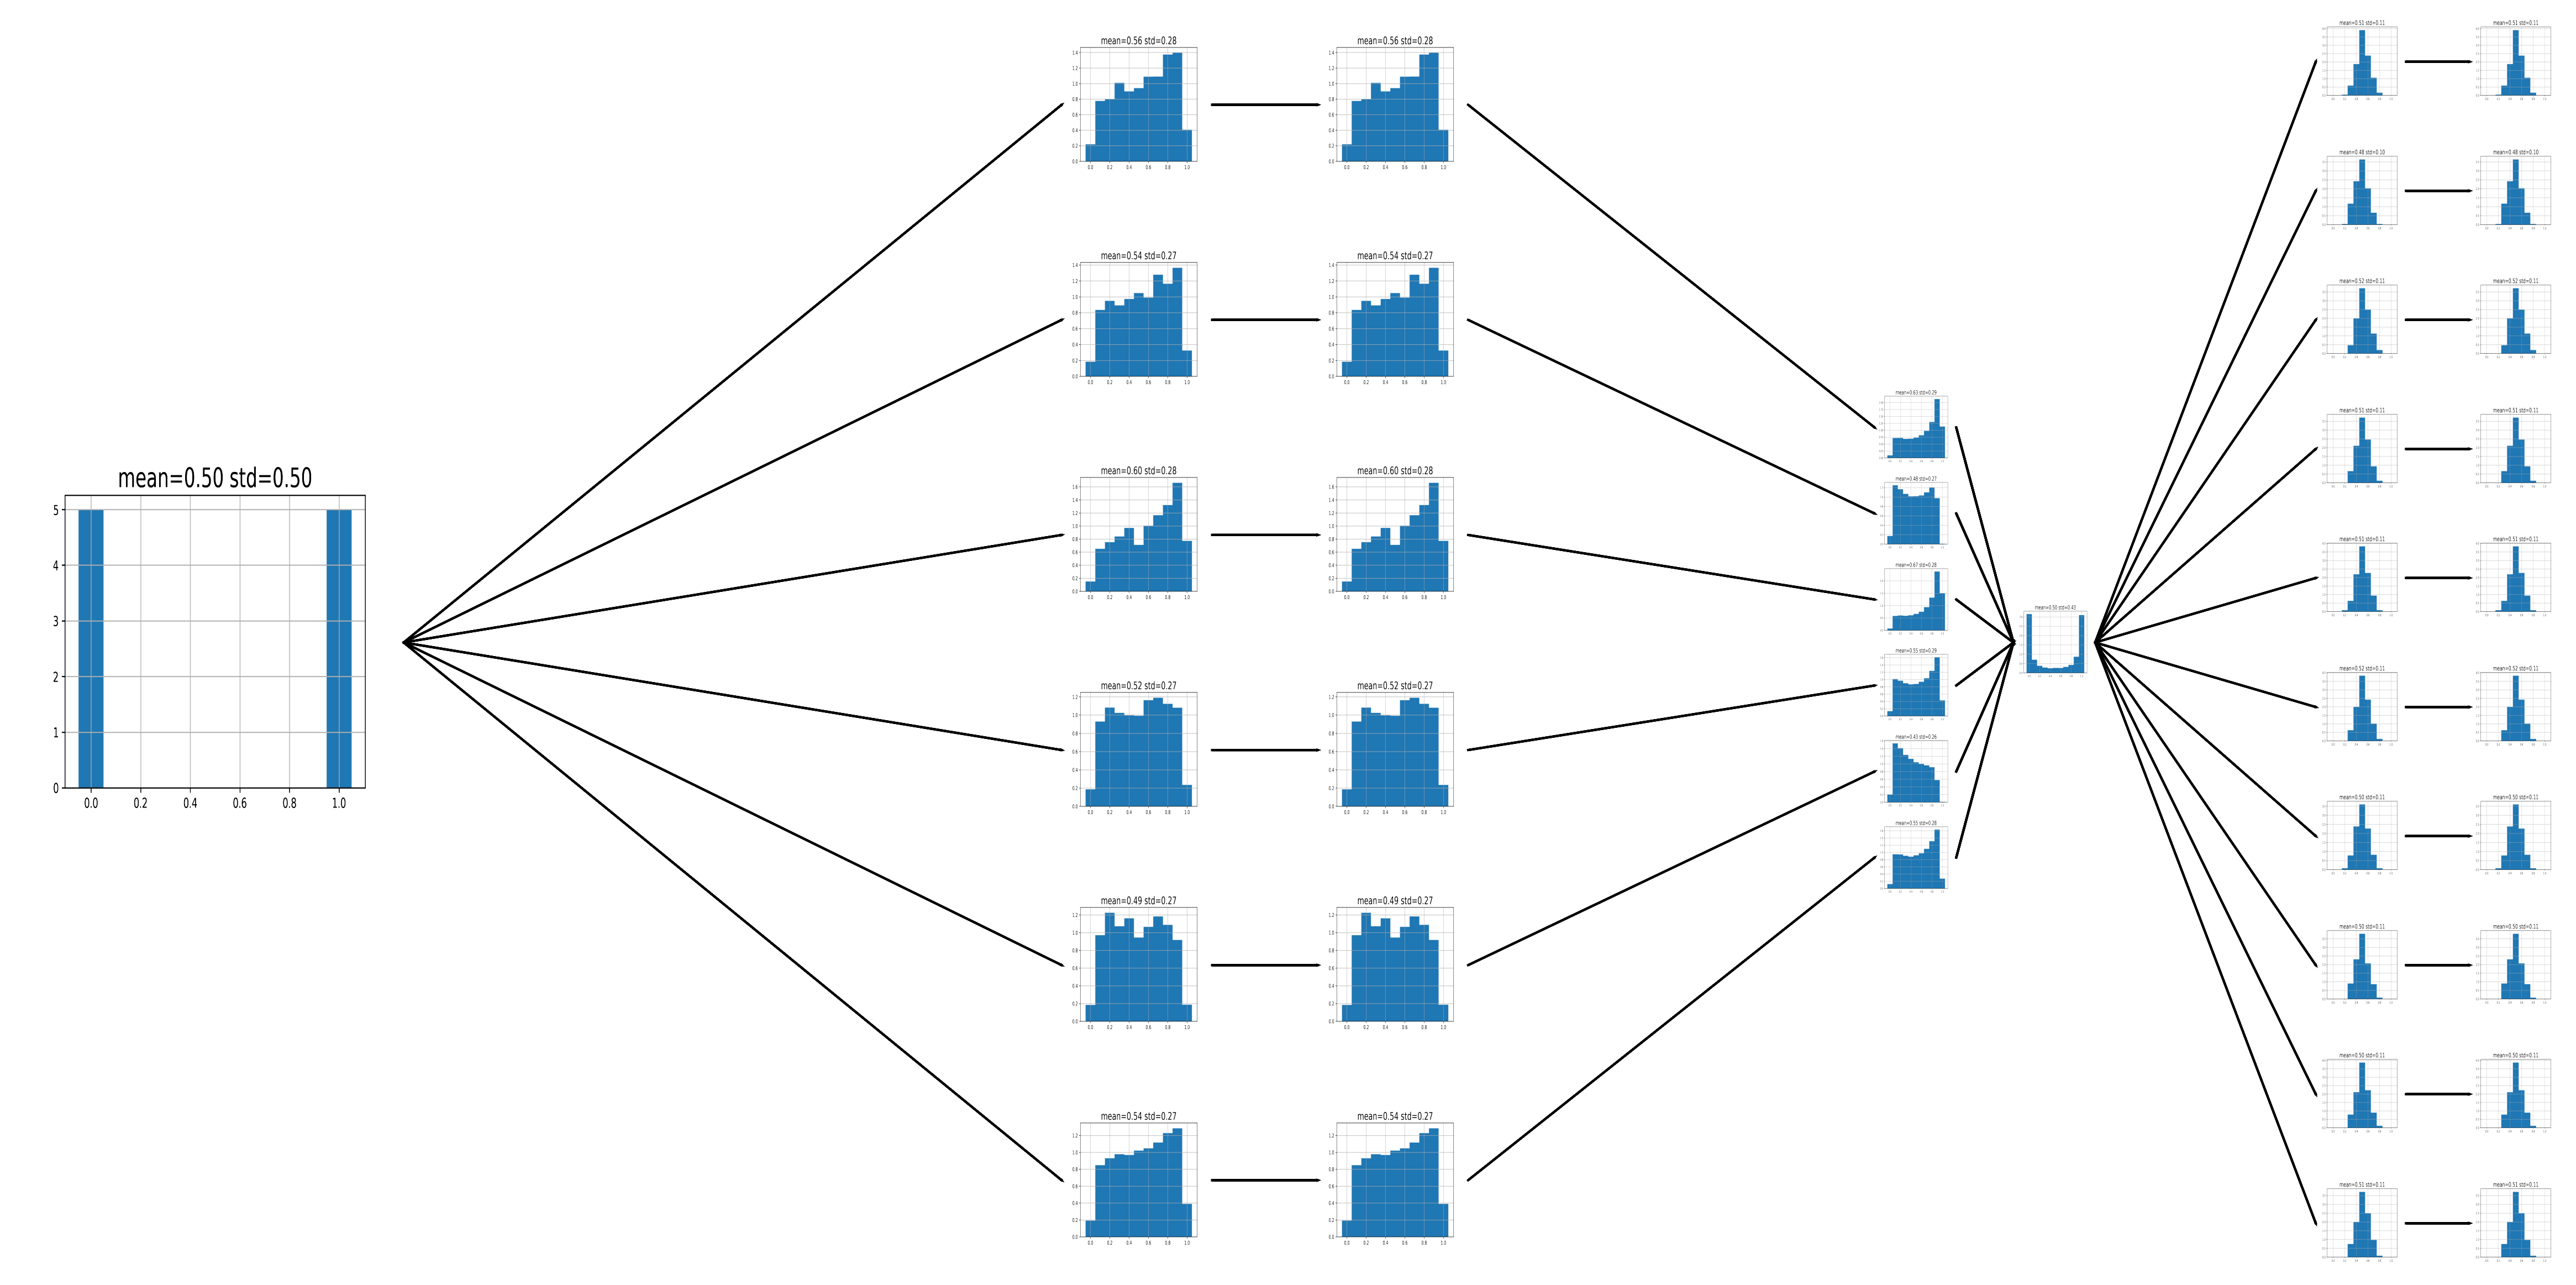

In [44]:
reload_modules()
viz_hist = bimonn_viz.BimonnHistogramVizualiser(model=model2, inpt=img.cuda(), dpi=300);
viz_hist.draw(figsize=(20, 10), dpi=300)


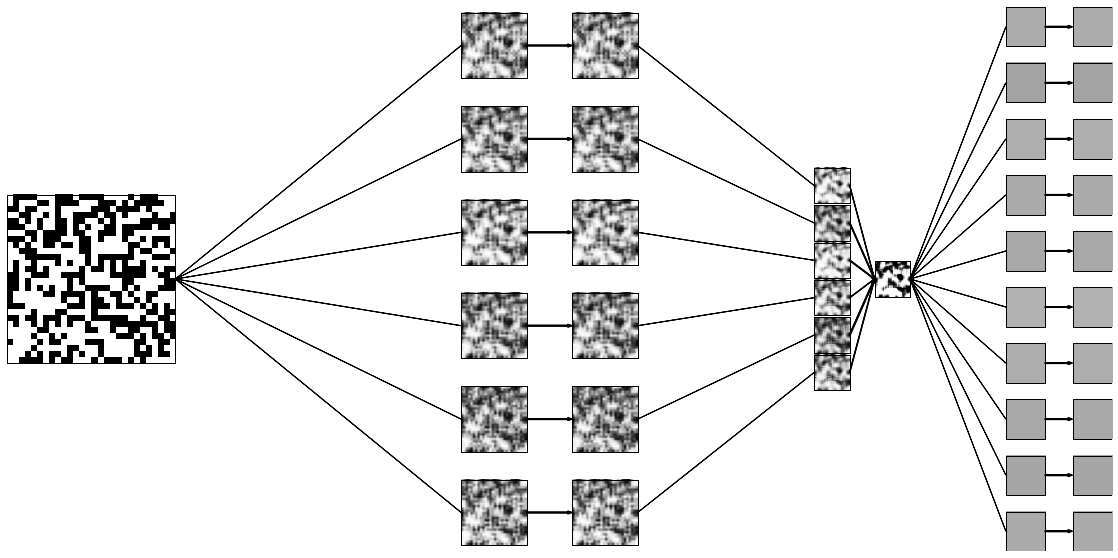

In [45]:
vizf = bimonn_viz.BimonnForwardVizualiser(model=model2, inpt=img.cuda())
vizf.draw(figsize=(20, 10))

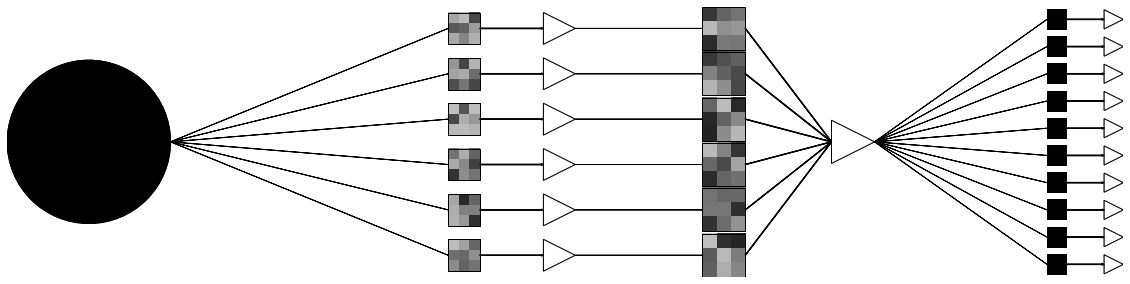

In [48]:
bimonn_viz.BimonnVizualiser(model2).draw(figsize=(20, 10))


# Results analysis

## Exp 80 - Sandbox

In [34]:
from deep_morpho.save_results_template.display_results import DisplayResults
from matplotlib.lines import Line2D


def list_dir_joined(folder: str):
    return [os.path.join(folder, k) for k in os.listdir(folder)]


TB_PATHS = []

path_global = "deep_morpho/results/results_tensorboards/Bimonn_exp_80/sandbox/dual_weights/0_"
for exp_nb in ( [] +
    ["0"] +
    # ["7"] +
    # [f"{i}" for i in range(1, 5)] +
[]):
    for version in list_dir_joined(join(path_global, exp_nb, "mnistclassifchannel", "BimonnDenseNotBinary")):
        TB_PATHS.append(version)


df, global_args, changing_args = DisplayResults().get_df_from_tb_paths(TB_PATHS)
df["test_accuracy"] = df["test_accuracy"].astype(float)
df["binary_test_accuracy"] = df["binary_test_accuracy"].astype(float)
df["test_error"] = 1 - df["test_accuracy"].astype(float)
df["binary_test_error"] = 1 - df["binary_test_accuracy"].astype(float)
df["float_params"] = df["float_params"].astype(float)


df.loc[pd.isna(df["kwargs_loss_regu"]), "kwargs_loss_regu"] = "None"
df.loc[df["loss_regu_str"] == "None", "kwargs_loss_regu"] = "None"
df["loss_coef_regu"] = df["loss_coef_regu"].apply(lambda x: x[1])
df.loc[df["loss_coef_regu"] == "None", "loss_coef_regu"] = "0"

df.loc[(df["kwargs_loss_regu"] == "None") & (df["loss_regu_str"] == "RegularizationProjConstant"), "kwargs_loss_regu"] = "exact"

df["loss_regu_delay"] = df["loss_regu_delay"].astype(int)

for col in ["val_accuracy", "test_accuracy", "binary_val_accuracy", "binary_test_accuracy"]:
    df[col] = df[col].astype(float)
# df["binary_val_accuracy"] = df["binary_val_accuracy"].astype(float)

df["float_diff_val_test"] = df["val_accuracy"] - df["test_accuracy"]
df["binary_diff_val_test"] = df["binary_val_accuracy"] - df["binary_test_accuracy"]
df["archi"] = df["tb_path"].apply(lambda x: Path(x).parent.name)
# def archi_names(x):
#     x = float(x)
#     if x < 3.2e6:
#         return "Chans [200]"
#     if x < 5e6:
#         return "3.3M params"
#     return "10M params"
# df["Architecture"] = df["float_params"].apply(archi_names)

# df["Weight Reparametrization"] = df["atomic_element"].apply(lambda x: x.replace("dual_bisel", "dual").replace("bisel", "positive"))
# df["Bias Reparametrization"] = df["bias_optim_mode"].apply(lambda x: x.lower().replace("_", " ").replace("reparametrized", "reparam").replace("interval", ""))
# df["Number of Level-sets"] = df["n_values"].astype(int)


Reading results:   0%|          | 0/100 [00:00<?, ?it/s]/hdd/aouadt/these/projets/3d_segm/deep_morpho/save_results_template/load_args.py:97: UserWarning: More than one match for \n?   loss_data[^\n]+\.(\w+)\n in ['BCELoss', 'BCELoss']
  warnings.warn(f"More than one match for {regex} in {exps}")
Args: 100%|██████████| 48/48 [00:00<00:00, 68923.86it/s]


<Axes: >

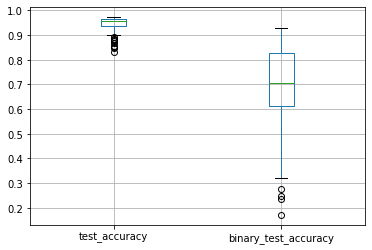

In [38]:
df.loc[:, ["test_accuracy", "binary_test_accuracy"]].boxplot()

In [44]:
hyperparam_list = [
    "apply_one_hot_target.datamodule",  # BCE vs Cross Entropy
    "learning_rate",
    "weight",  # softplus vs identity
    "bias_optim_mode",  # biais
    "loss_regu_str",  # None, Regu
    "loss_regu_delay",  # au bout de cb de batch on lance la régu
    "kwargs_loss_regu",  # None, exact, uniform, normal
    "loss_coef_data",  # 1 * loss_data + c * loss_regu
    "loss_coef_regu",  # c
    "n_params_total",
]

metrics_list = [
    "train_accuracy",
    "val_accuracy",
    "test_accuracy",
    "binary_train_accuracy",
    "binary_val_accuracy",
    "binary_test_accuracy",
    # "binary_partial_test_accuracy",
    "ratio_params_activated",
    "float_diff_val_test",
    "binary_diff_val_test",
    "ratio_params_activated"
]

df["bias_optim_mode"].unique()

array(['POSITIVE_INTERVAL_REPARAMETRIZED', 'POSITIVE_INTERVAL_PROJECTED',
       'POSITIVE', 'RAW'], dtype=object)

In [45]:
best_bin_idxes = df["binary_test_error"].argsort()
row = df.iloc[best_bin_idxes[0]]

print("Best test accuracy global for dual weights (without checking from val)")
print(row["tb_path"])
print("================================")
print(row[hyperparam_list + metrics_list])

print("Test error", 1 - row["test_accuracy"])
print("Binary test error", 1 - row["binary_test_accuracy"])

Best test accuracy global for dual weights (without checking from val)
deep_morpho/results/results_tensorboards/Bimonn_exp_80/sandbox/dual_weights/0_/0/mnistclassifchannel/BimonnDenseNotBinary/version_69
apply_one_hot_target.datamodule                               false
learning_rate                                   0.07801318442994473
weight                                                     softplus
bias_optim_mode                    POSITIVE_INTERVAL_REPARAMETRIZED
loss_regu_str                            RegularizationProjConstant
loss_regu_delay                                               10000
kwargs_loss_regu                                            uniform
loss_coef_data                                            ( 1\n, 1)
loss_coef_regu                                                0.001
n_params_total                                            3219456.0
train_accuracy                                   0.9770833333333333
val_accuracy                                    

## Exp 80 Random Experiment - Bimonn DenseLui

In [15]:
from deep_morpho.save_results_template.display_results import DisplayResults


def list_dir_joined(folder: str):
    return [os.path.join(folder, k) for k in os.listdir(folder)]


TB_PATHS = []

path_global = "deep_morpho/results/results_tensorboards/Bimonn_exp_80/sandbox/positive_weights/0_"
for exp_nb in ( [] +
    ["0"] +
    [f"{i}" for i in range(5, 7)] +
[]):
    for version in list_dir_joined(join(path_global, exp_nb, "mnistclassifchannel", "BimonnDenseNotBinary")):
        TB_PATHS.append(version)

path_global = "deep_morpho/results/results_tensorboards/Bimonn_exp_80/ruche/positive_weights/0_"
for exp_nb in range(8):
    for version in list_dir_joined(join(path_global, str(exp_nb), "mnistclassifchannel", "BimonnDenseNotBinary")):
        TB_PATHS.append(version)

path_global = "deep_morpho/results/results_tensorboards/Bimonn_exp_80/sandbox/dual_weights/0_"
for version in list_dir_joined(join(path_global, "0", "mnistclassifchannel", "BimonnDenseNotBinary")):
    TB_PATHS.append(version)



df, global_args, changing_args = DisplayResults().get_df_from_tb_paths(TB_PATHS)
df["test_accuracy"] = df["test_accuracy"].astype(float)
df["binary_test_accuracy"] = df["binary_test_accuracy"].astype(float)
df["test_error"] = 1 - df["test_accuracy"].astype(float)
df["binary_test_error"] = 1 - df["binary_test_accuracy"].astype(float)
df["float_params"] = df["float_params"].astype(float)


df.loc[pd.isna(df["kwargs_loss_regu"]), "kwargs_loss_regu"] = "None"
df.loc[df["loss_regu_str"] == "None", "kwargs_loss_regu"] = "None"
df["loss_coef_regu"] = df["loss_coef_regu"].apply(lambda x: x[1])
df.loc[df["loss_coef_regu"] == "None", "loss_coef_regu"] = "0"

df.loc[(df["kwargs_loss_regu"] == "None") & (df["loss_regu_str"] == "RegularizationProjConstant"), "kwargs_loss_regu"] = "exact"

df["loss_regu_delay"] = df["loss_regu_delay"].astype(int)

for col in ["val_accuracy", "test_accuracy", "binary_val_accuracy", "binary_test_accuracy"]:
    df[col] = df[col].astype(float)
# df["binary_val_accuracy"] = df["binary_val_accuracy"].astype(float)

df["float_diff_val_test"] = df["val_accuracy"] - df["test_accuracy"]
df["binary_diff_val_test"] = df["binary_val_accuracy"] - df["binary_test_accuracy"]
df["archi"] = df["tb_path"].apply(lambda x: Path(x).parent.name)
df["learning_rate"] = df["learning_rate"].astype(float)
# def archi_names(x):
#     x = float(x)
#     if x < 3.2e6:
#         return "Chans [200]"
#     if x < 5e6:
#         return "3.3M params"
#     return "10M params"
# df["Architecture"] = df["float_params"].apply(archi_names)

# df["Weight Reparametrization"] = df["atomic_element"].apply(lambda x: x.replace("dual_bisel", "dual").replace("bisel", "positive"))
# df["Bias Reparametrization"] = df["bias_optim_mode"].apply(lambda x: x.lower().replace("_", " ").replace("reparametrized", "reparam").replace("interval", ""))
# df["Number of Level-sets"] = df["n_values"].astype(int)


Reading results:   0%|          | 0/831 [00:00<?, ?it/s]

/hdd/aouadt/these/projets/3d_segm/deep_morpho/save_results_template/load_args.py:97: UserWarning: More than one match for \n?   loss_data[^\n]+\.(\w+)\n in ['BCELoss', 'BCELoss']
  warnings.warn(f"More than one match for {regex} in {exps}")
Args: 100%|██████████| 48/48 [00:00<00:00, 4841.56it/s]


In [16]:
df.to_csv("deep_morpho/results/exp80_mnist_results_df/mnist_dense_ls1_dual_no_partial.csv")

In [116]:
import re

def regex_find_or_none(regex: str, st: str, *args, group_nb: int = -1, **kwargs,):
    exps = re.findall(regex, st, *args, **kwargs)
    if len(exps) == 0:
        return None
    
    if len(exps) > 1:
        exps = [exps[0]]
    # assert len(exps) == 1, exps

    # for multiple parenthesis, we have to select the group. If there is only one group, -1
    if group_nb == -1:
        return exps[0]
    return exps[0][group_nb]

def parse_yaml_dict_key_line(yaml_str: str, key: str):
    return regex_find_or_none(f"( |^|\n){key}: ([^\n]+)\n", yaml_str, group_nb=1)


with open(Path(TB_PATHS[0]) / "args.yaml" ,"r") as f:
    print(parse_yaml_dict_key_line(f.read(), "seed"))

486056990


In [43]:
from deep_morpho.experiments.experiment_classification import ExperimentClassificationChannel
from deep_morpho.experiments.enforcers import ArgsClassifChannel, ArgsMnist
from deep_morpho.experiments.parser import Parser
import sys
from deep_morpho.datasets.gray_to_channels_dataset import LevelsetValuesEqualIndex

def load_args():
    args = Parser()
    # args["batch_seed"] = 2249939862
    args["batch_seed"] = 123123939
    args["dataset"] = "mnistclassifchanneldataset"
    args["model"] = "bimonndensenotbinary"
    args["batch_size"] = 128
    args["num_workers"] = 5
    args["freq_scalars"] = 50
    args["freq_imgs"] = None
    args["freq_hist"] = None
    args["freq_update_binary_batch"] = None
    args["freq_update_binary_epoch"] = None
    args["patience_reduce_lr"] = None
    args["patience_loss"] = None
    args['channel_classif_args'] = {
        "levelset_handler_mode": LevelsetValuesEqualIndex,
        # "levelset_handler_args": {"n_values": 10},
        "levelset_handler_args": {"n_values": 1},
    }

    args.parse_args(add_argv=False)
    return args


def load_model(tb_path):
    if os.path.exists(join(tb_path, 'best_weights')):
        tb_path = join(tb_path, 'best_weights', os.listdir(join(tb_path, 'best_weights'))[0])
    elif os.path.exists(join(tb_path, 'checkpoints')):
        tb_path = join(tb_path, 'checkpoints', os.listdir(join(tb_path, 'checkpoints'))[0])

    # bise_base.BiseBiasOptimEnum[df["bias_optim_mode"].iloc[0]]

    loss = nn.BCELoss()
    model = models.LightningBiMoNN.load_from_checkpoint(tb_path, loss=loss)
    model.model.binary(True)
    model.model.binary("partial")
    return model


def load_mnist_exp(model):
    args = load_args()

    exp = ExperimentClassificationChannel(
        args=args,
        dest_dir="tmp/",
        verbose=False
    )
    exp.model = model
    exp.args_enforcers = [ArgsClassifChannel(), ArgsMnist()]
    exp.setup()

    obs_binary_partial_metrics = obs.BinaryPartialModeMetricClassifChannel(
        metrics={"accuracy": exp.metric_binary_obs.metrics["accuracy"]},
        freq={"train": 1, "val": 1, "test": 1},
        plot_freq={"train": 1, "val": 1, "test": 100000},
        dataset=exp.trainloader.dataset,
    )
    exp.observables.append(obs_binary_partial_metrics)
    model.observables = exp.observables
    return exp, obs_binary_partial_metrics


def evaluate_test(tb_path: str):
    model = load_model(tb_path)
    exp, obs_binary_partial_metrics = load_mnist_exp(model)

    exp.test()


    binary_acc = exp.metric_binary_obs.last_value["test"]["accuracy"]
    float_acc = exp.metric_float_obs.last_value["test"]["accuracy"]
    binary_partial_acc = obs_binary_partial_metrics.last_value["test"]["accuracy"]

    return (exp, obs_binary_partial_metrics), (binary_acc, float_acc, binary_partial_acc)

(exp, obs_binary_partial_metrics), (binary_acc, float_acc, binary_partial_acc) = evaluate_test(TB_PATHS[0], verbose=False)

# print("Binary Error:", f"{1 - binary_acc:.4f}")
# print("Binary Partial Error:", f"{1 - binary_partial_acc:.4f}")
# print("Float Error:", f"{1 - float_acc:.4f}")


GPU available: True, used: True                                   
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: 0it [00:00, ?it/s]

--------------------------------------------------------------------------------
DATALOADER:0 TEST RESULTS
{'binary_mode/accuracy_test': 0.8242999911308289,
 'binary_mode/loss_test': 1.1322051286697388,
 'binary_mode/metrics_epoch_mean/per_batch_step/accuracy_test': 0.8243,
 'binary_mode/metrics_epoch_mean/per_batch_step/loss_test': 1.13220509185791,
 'binary_partial_mode/accuracy_test': 0.9672999978065491,
 'binary_partial_mode/loss_test': 0.030695782974362373,
 'binary_partial_mode/metrics_epoch_mean/per_batch_step/accuracy_test': 0.9673,
 'binary_partial_mode/metrics_epoch_mean/per_batch_step/loss_test': 0.03069578033015132,
 'loss/test': 0.030695712193846703,
 'metrics_batch/accuracy_test': 0.9672999978065491,
 'metrics_batch/loss_test': 0.030695712193846703,
 'metrics_epoch_mean/per_batch_step/accuracy_test': 0.9673,
 'metrics_epoch_mean/per_batch_step/loss_test': 0.030695713337510824}
--------------------------------------------------------------------------------


In [10]:
# load additionnal test experiments
path_results = Path("deep_morpho/results/exp80_mnist_results_df")
all_res = []
for tb_path in path_results.iterdir():
    if not tb_path.is_dir():
        continue
    binary_partial_json = tb_path / "BinaryPartialModeMetricClassifChannel" / "metrics.json"
    if not binary_partial_json.exists():
        continue
    float_metrics_json = load_json(tb_path / "CalculateAndLogMetrics" / "metrics.json")
    all_res.append({
        "tb_path": tb_path.name.replace("__", "/").replace("/_", "_/"),
        "binary_partial_test_accuracy": load_json(binary_partial_json)["test"]["accuracy"],
        "float_test_accuracy_2": float_metrics_json["test"]["accuracy"],
        "float_loss_test": float_metrics_json["test"]["loss"],
    })

df_res = pd.DataFrame(all_res)

In [18]:
df_res
df = df.merge(df_res, on="tb_path")
df["partial_binary_error"] = df["test_accuracy"].astype(float) - df["binary_partial_test_accuracy"].astype(float)
df["binary_error"] = df["test_accuracy"].astype(float) - df["binary_test_accuracy"].astype(float)
df["binary_partial_test_error"] = 1 - df["binary_partial_test_accuracy"].astype(float)
len(df)

731

In [17]:
df.to_csv("deep_morpho/results/exp80_mnist_results_df/mnist_dense_ls1_partial_no_dual.csv")

In [137]:
df = pd.read_csv("deep_morpho/results/exp80_mnist_results_df/mnist_dense_ls1_partial_no_dual.csv")
# df = pd.read_csv("deep_morpho/results/exp80_mnist_results_df/mnist_dense_ls1_dual_no_partial.csv")
if "binary_partial_test_error" in df.columns:
    df["binary_partial_test_error"] = 1 - df["binary_partial_test_accuracy"]
df[df.isna()] = "None"
df["is_dual"] = df["tb_path"].apply(lambda x: "dual" in x)
df.loc[df["is_dual"], "weight"] = "dual"
len(df)


/var/folders/9q/1h87lv1d0qb9rp8wm8md3fvw0000gn/T/ipykernel_24478/2787169537.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'None' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df[df.isna()] = "None"


731

In [41]:
df.loc[
    df["n_params_total"] == 10006528,
    "apply_one_hot_target.datamodule"
].unique()

array([ True, False])

In [114]:
df.loc[
    df["weight"] == "dual",
    "kwargs_loss_regu"
].value_counts()

kwargs_loss_regu
normal     51
uniform    49
Name: count, dtype: int64

apply_one_hot_target.datamodule 2
weight 3
bias_optim_mode 4
loss_regu_str 2
loss_regu_delay 6


/var/folders/9q/1h87lv1d0qb9rp8wm8md3fvw0000gn/T/ipykernel_24478/1919353507.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=fontsize)
/var/folders/9q/1h87lv1d0qb9rp8wm8md3fvw0000gn/T/ipykernel_24478/1919353507.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=fontsize)
/var/folders/9q/1h87lv1d0qb9rp8wm8md3fvw0000gn/T/ipykernel_24478/1919353507.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=fontsize)
/var/folders/9q/1h87lv1d0qb9rp8wm8md3fvw0000gn/T/ipykernel_24478/1919353507.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_tic

kwargs_loss_regu 4
loss_coef_regu 3


/var/folders/9q/1h87lv1d0qb9rp8wm8md3fvw0000gn/T/ipykernel_24478/1919353507.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=fontsize)
/var/folders/9q/1h87lv1d0qb9rp8wm8md3fvw0000gn/T/ipykernel_24478/1919353507.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=fontsize)


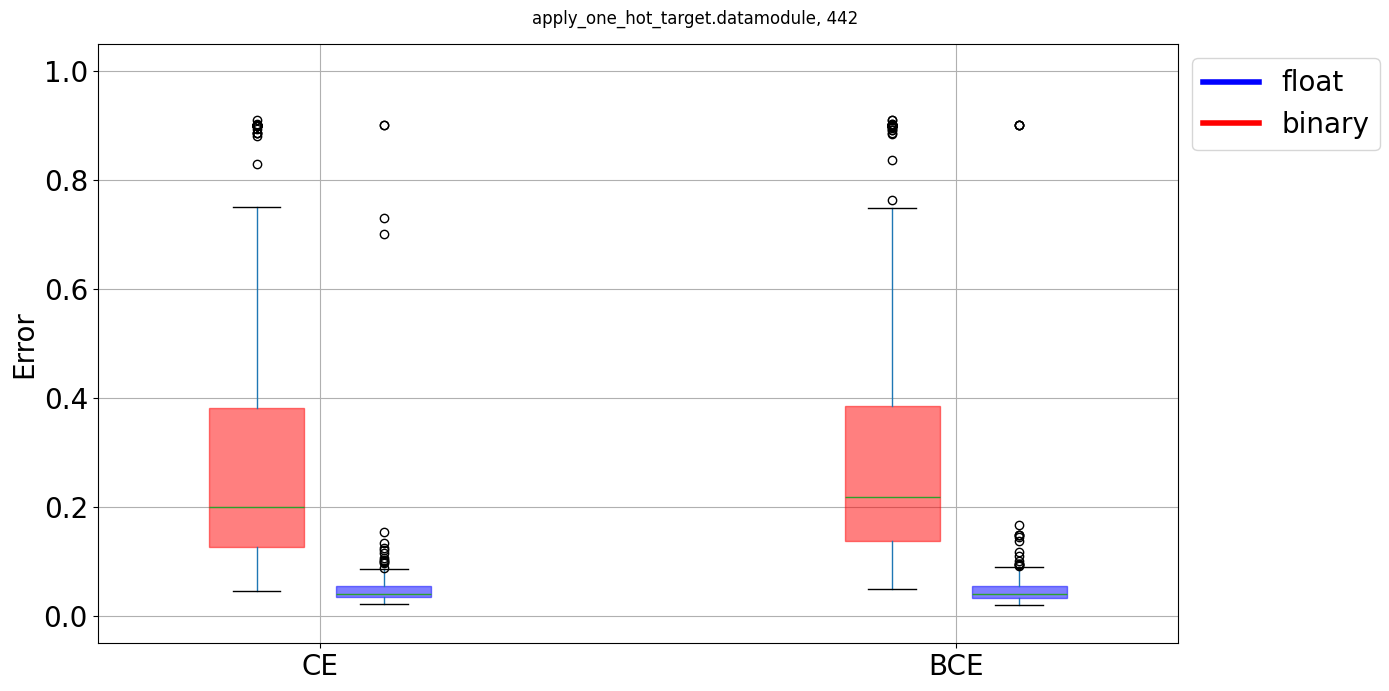

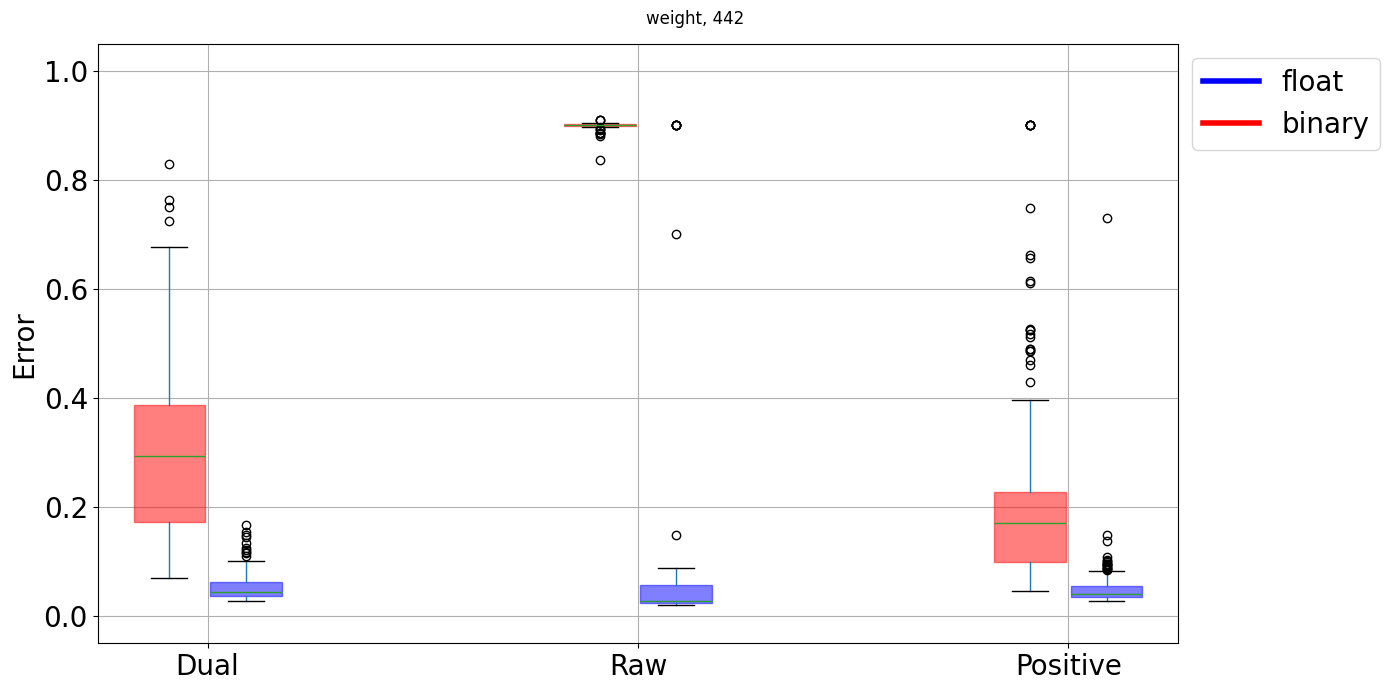

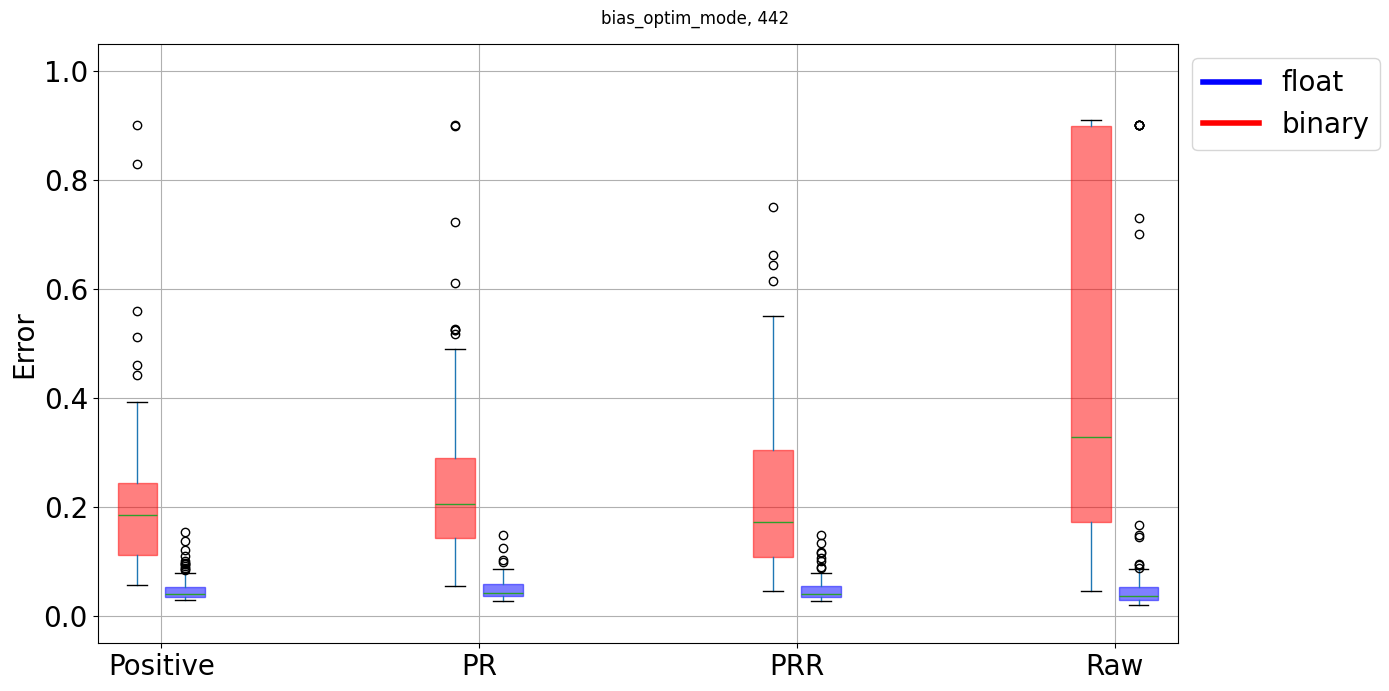

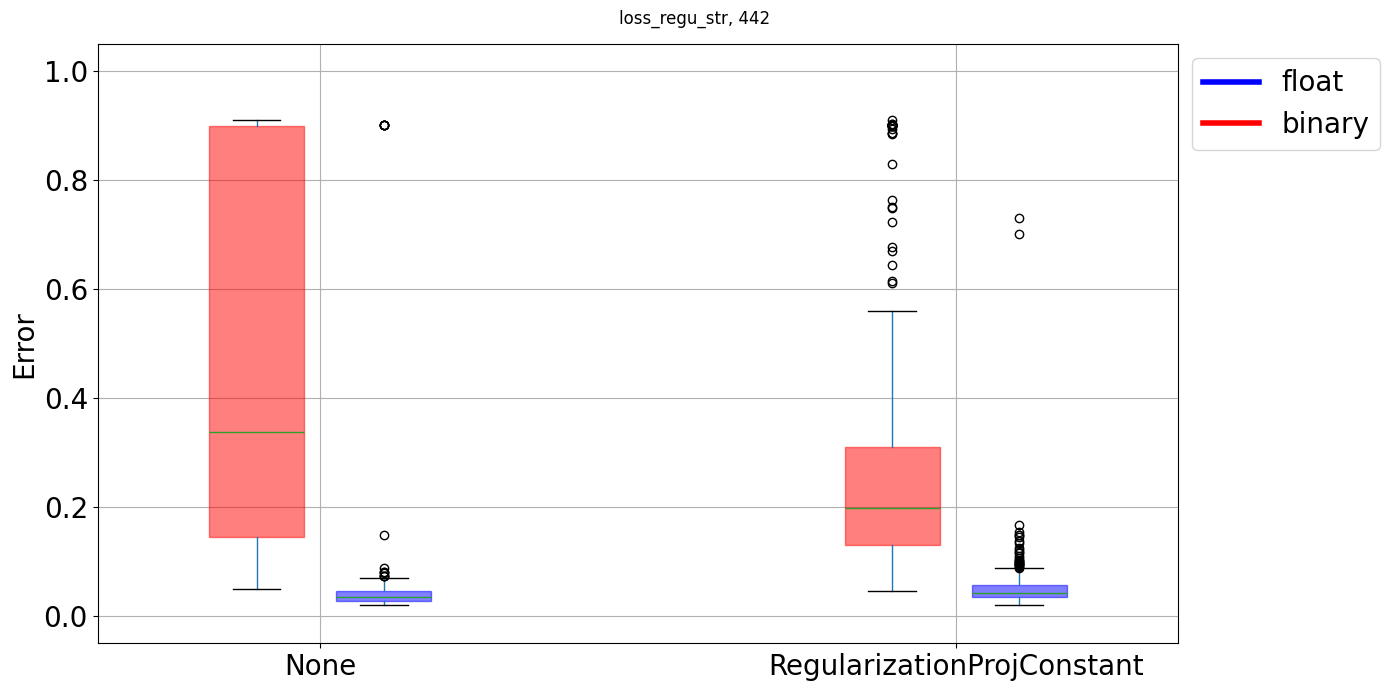

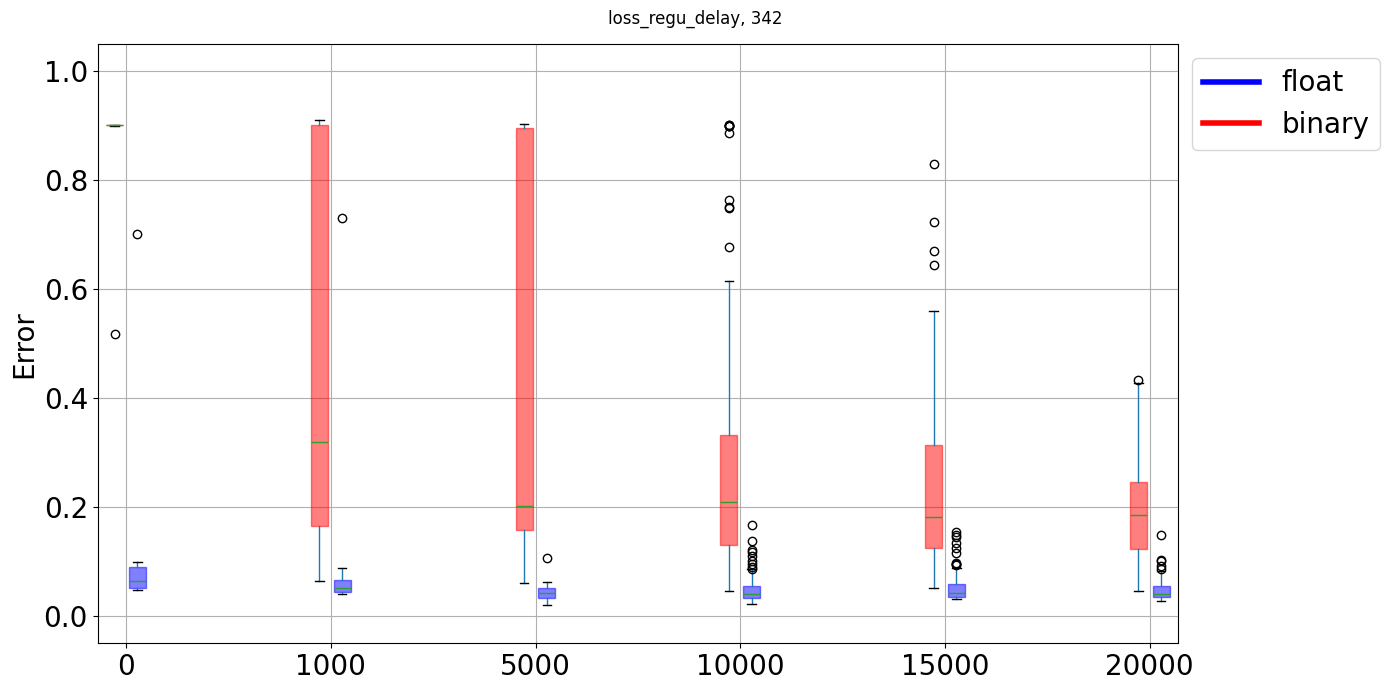

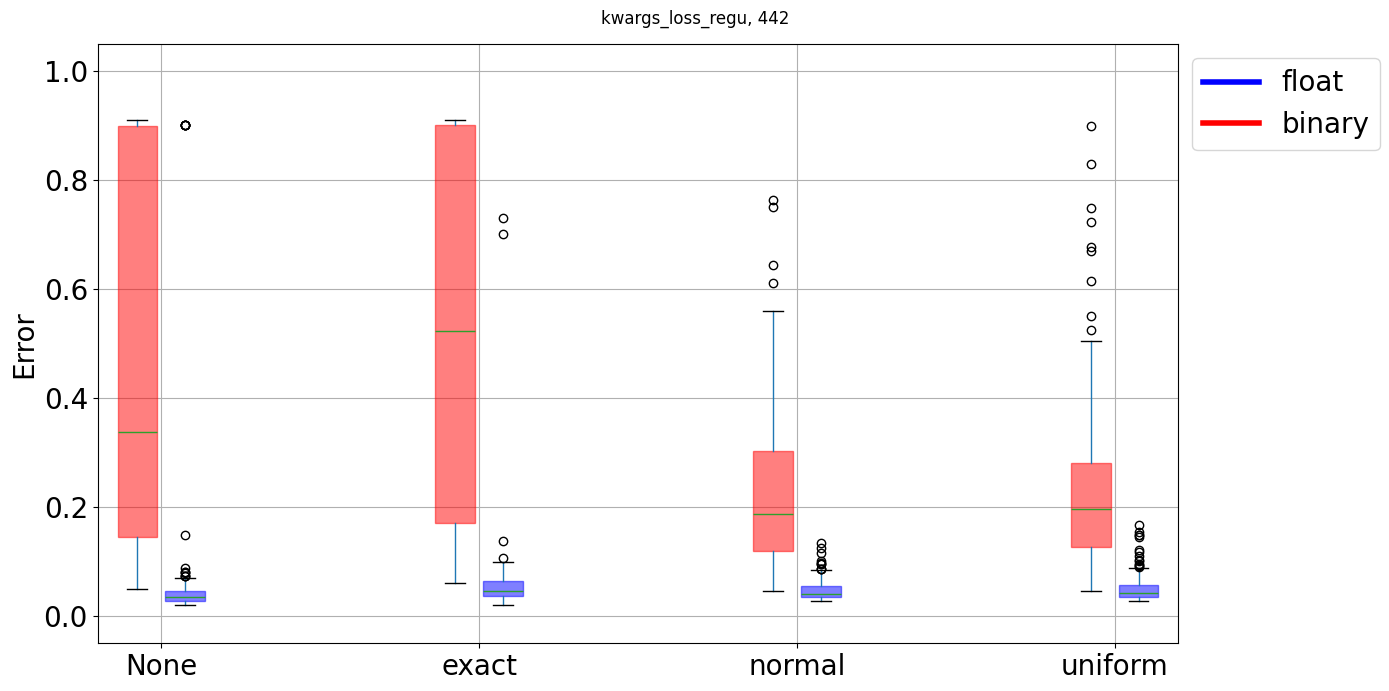

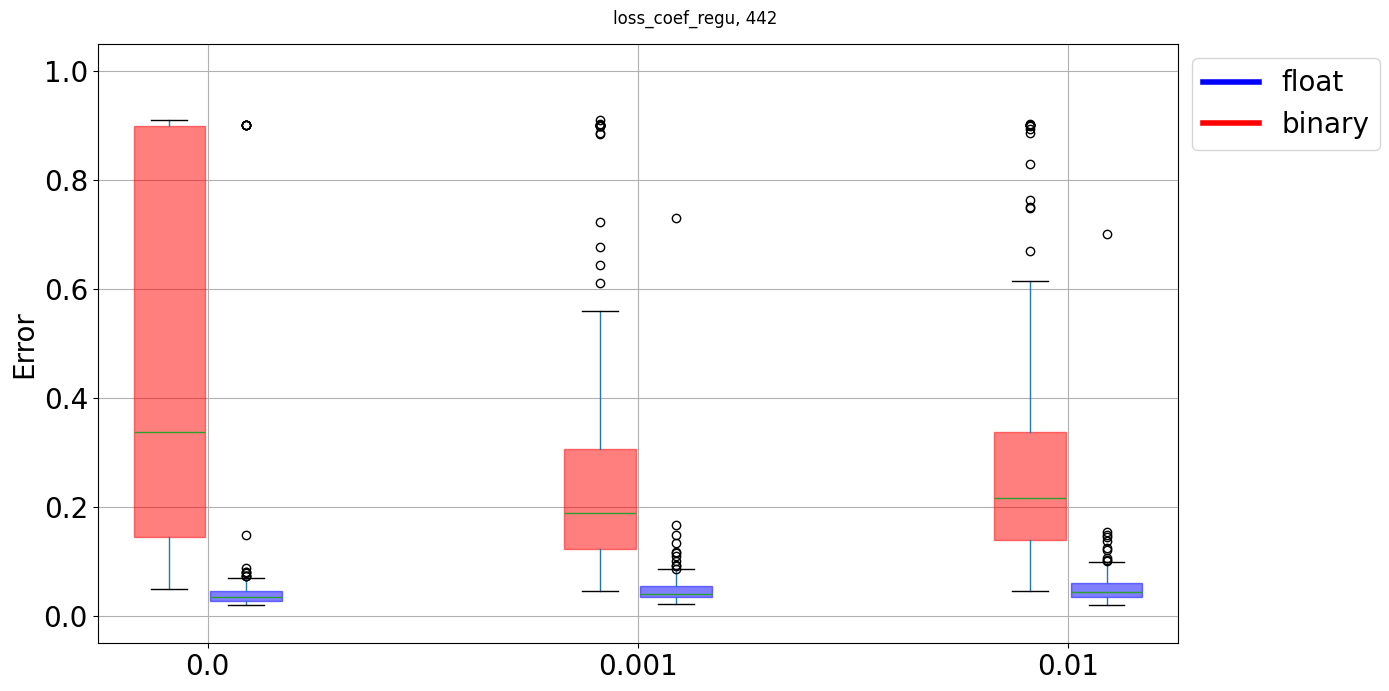

In [78]:
fontsize=20

custom_lines = [Line2D([0], [0], color="blue", lw=4), Line2D([0], [0], color="red", lw=4)]

def replace_label(x):
    return (
        x
        .replace("POSITIVE_INTERVAL_PROJECTED", "PR")
        .replace("POSITIVE_INTERVAL_REPARAMETRIZED", "PRR")
        .replace("POSITIVE", "Positive")
        .replace("RAW", "Raw")
        .replace("False", r"CE")
        .replace("True", r"BCE")
        .replace("3219456.0", "3M")
        .replace("10006528.0", "10M")
        .replace("dual", "Dual")
        .replace("softplus", "Positive")
        .replace("identity", "Raw")

    )

hyperparam_list = [
    "apply_one_hot_target.datamodule",  # BCE vs Cross Entropy
    # "learning_rate",
    "weight",  # softplus vs identity
    "bias_optim_mode",  # biais
    "loss_regu_str",  # None, Regu
    "loss_regu_delay",  # au bout de cb de batch on lance la régu
    "kwargs_loss_regu",  # None, exact, uniform, normal
    "loss_coef_regu",  # c
    # "n_params_total",
]

for hyperparam in hyperparam_list:
    cur_df = df[
        (df["n_params_total"] == 3219456.0)
        # (df["loss_regu_delay"] != 0)
    ]
    if hyperparam in ["loss_regu_delay", ]:
        cur_df = cur_df[cur_df["loss_regu_str"] != "None"]

    n_values = len(cur_df[hyperparam].unique())

    fig, ax = plt.subplots(1, 1, figsize=(14, 7))
    centers = (n_values) * np.arange(n_values)

    offset = .2 * 2 / (n_values)
    print(hyperparam, len(centers))

    cur_df.boxplot(
        column="test_error", by=hyperparam, ax=ax, return_type="both", patch_artist=True, boxprops=dict(alpha=.5, facecolor="blue", color="blue", ), 
        positions=centers + offset*max((n_values- 1), 1)
    )
    cur_df.boxplot(
        column="binary_test_error", by=hyperparam, ax=ax, return_type="both", patch_artist=True, boxprops=dict(alpha=.5, facecolor="red", color="red", ),
        positions=centers - offset*max((n_values- 1), 1)
    )
    ticks = [replace_label(k.get_text()) for k in ax.get_xticklabels()[:n_values]]
    ax.set_xticks(centers, )
    ax.set_xticklabels(ticks, fontsize=fontsize)
    ax.set_title("")
    # fig.suptitle("")
    fig.suptitle(f"{hyperparam}, {len(cur_df)}")
    ax.set_xlabel("")
    ax.set_ylabel("Error", fontsize=fontsize)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=fontsize)
    xmax = ax.get_xlim()[1]
    ymax = ax.get_ylim()[1]
    ax.scatter([xmax*.95], [ymax*.95], c="white")
    ax.legend(custom_lines, ["float", "binary"], fontsize=fontsize, bbox_to_anchor=(1, 1))
    ax.set_ylim(-0.05, 1.05)
    title = f"figures_for_manuscript/chapter7/boxplot_mnist_classif_dense_ls1_{hyperparam}.png"
    fig.tight_layout()
    # fig.savefig(title)
    # ax.legend()

/var/folders/9q/1h87lv1d0qb9rp8wm8md3fvw0000gn/T/ipykernel_24478/635278471.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=fontsize)
/var/folders/9q/1h87lv1d0qb9rp8wm8md3fvw0000gn/T/ipykernel_24478/635278471.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=fontsize)
/var/folders/9q/1h87lv1d0qb9rp8wm8md3fvw0000gn/T/ipykernel_24478/635278471.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=fontsize)
/var/folders/9q/1h87lv1d0qb9rp8wm8md3fvw0000gn/T/ipykernel_24478/635278471.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks()

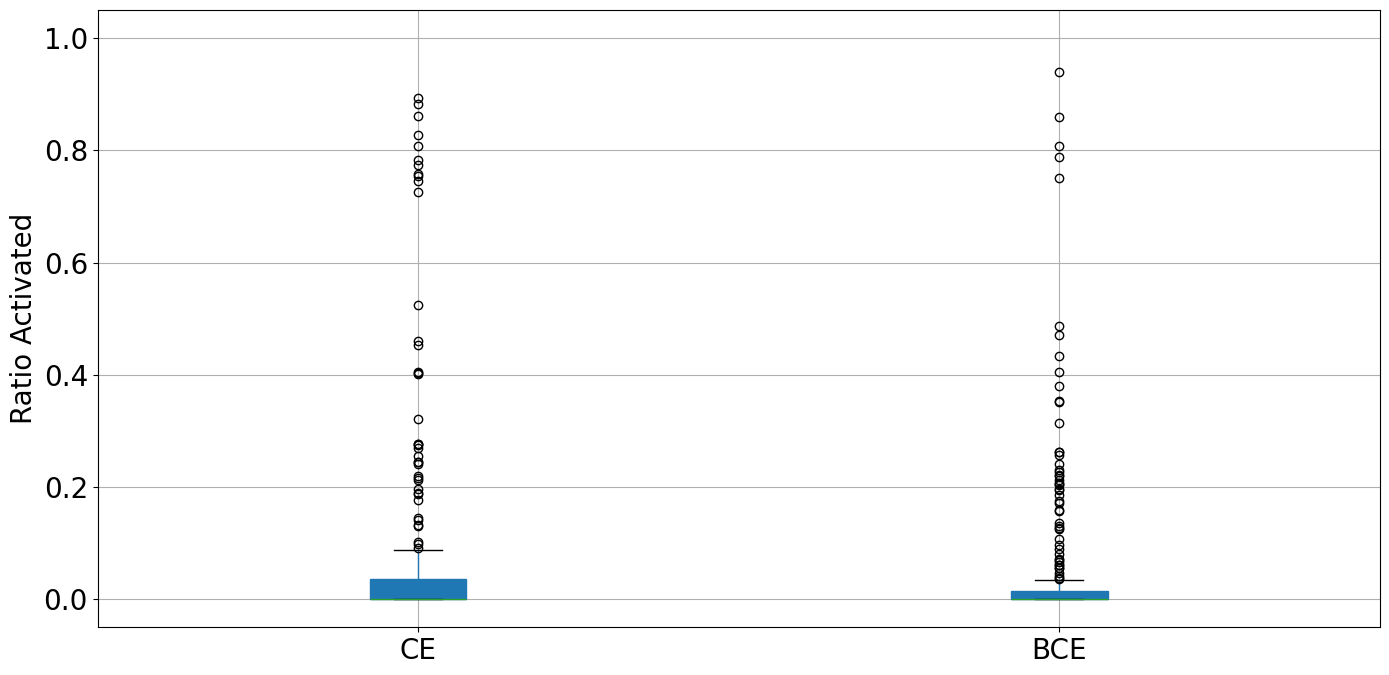

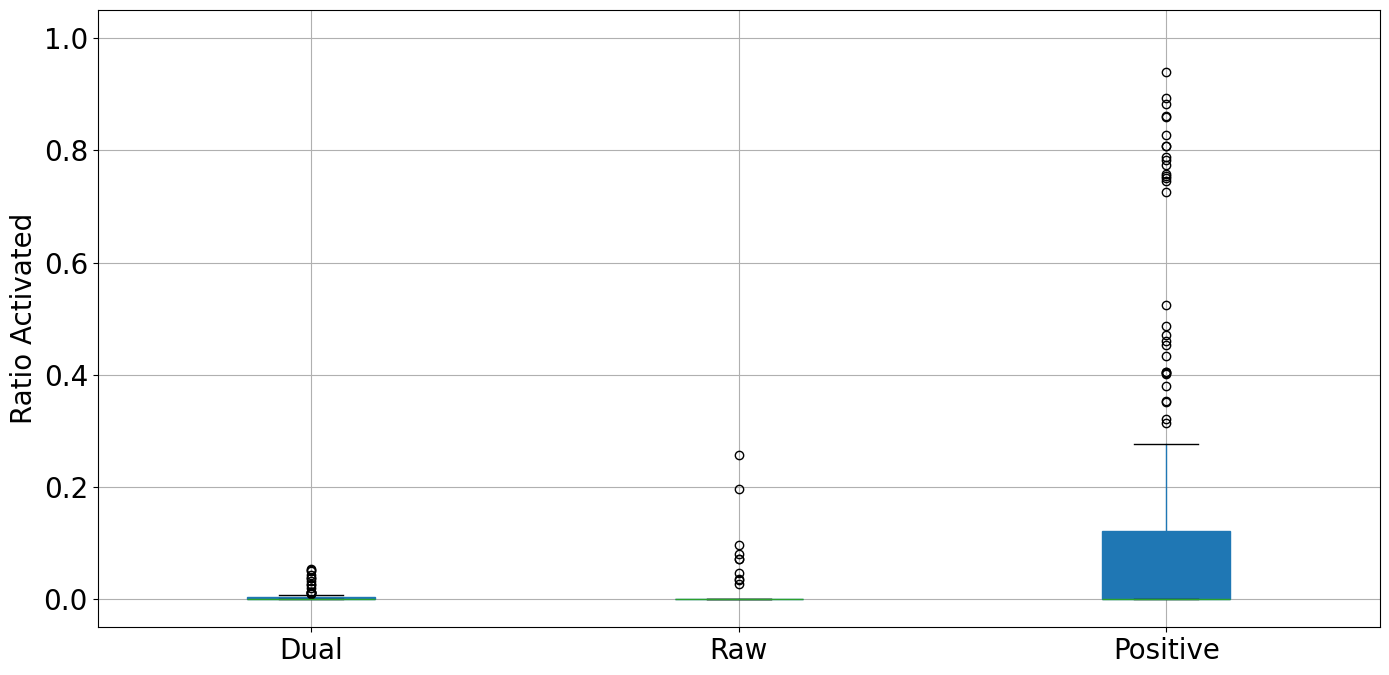

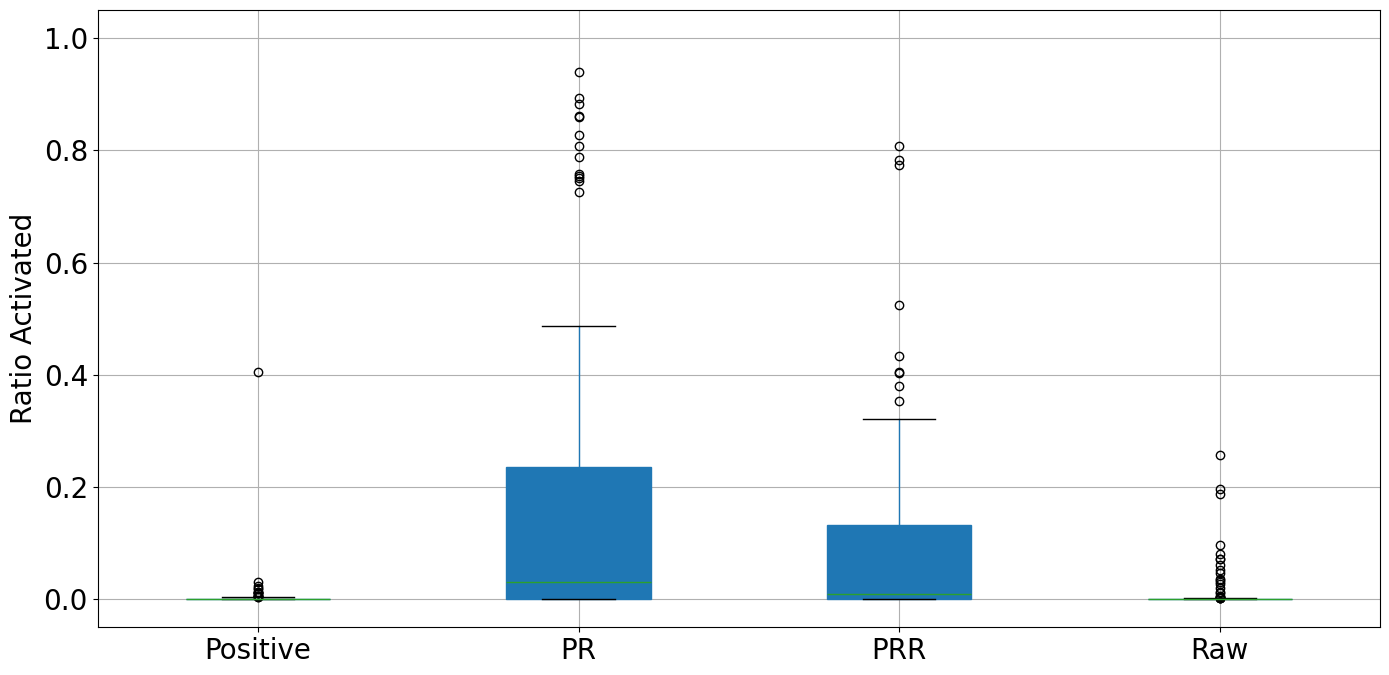

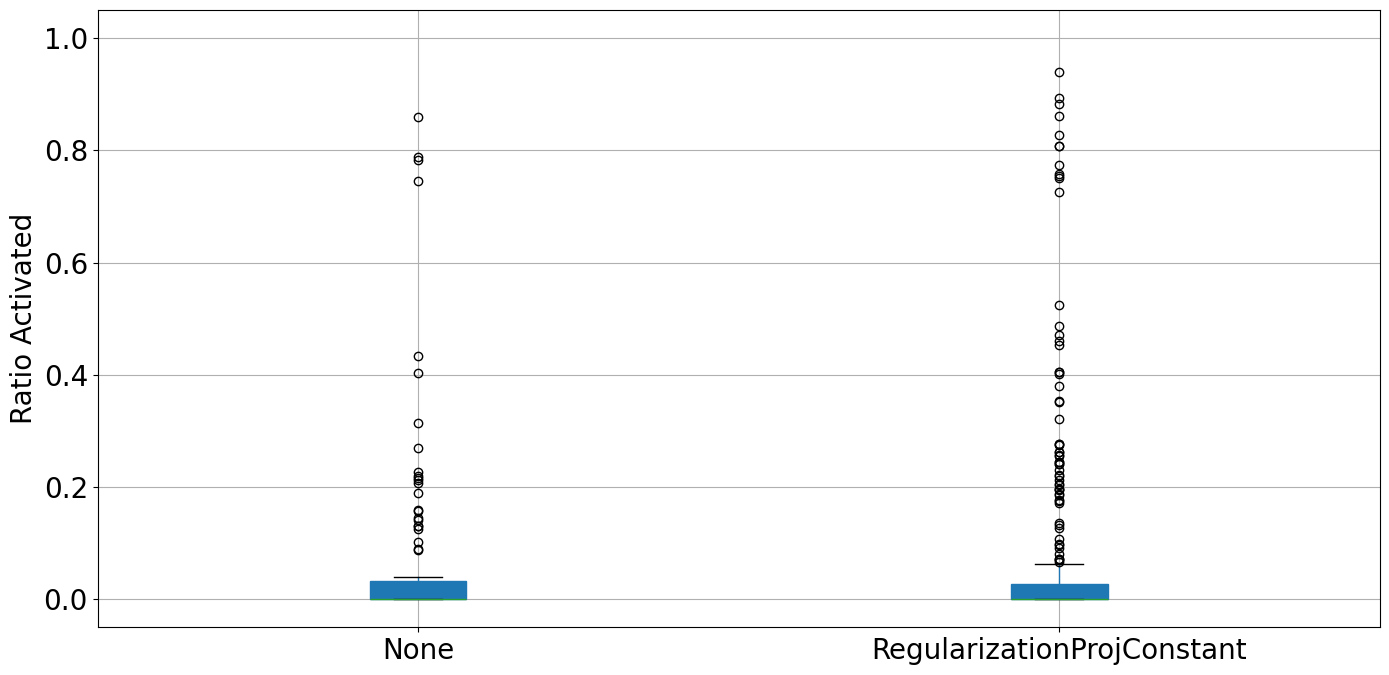

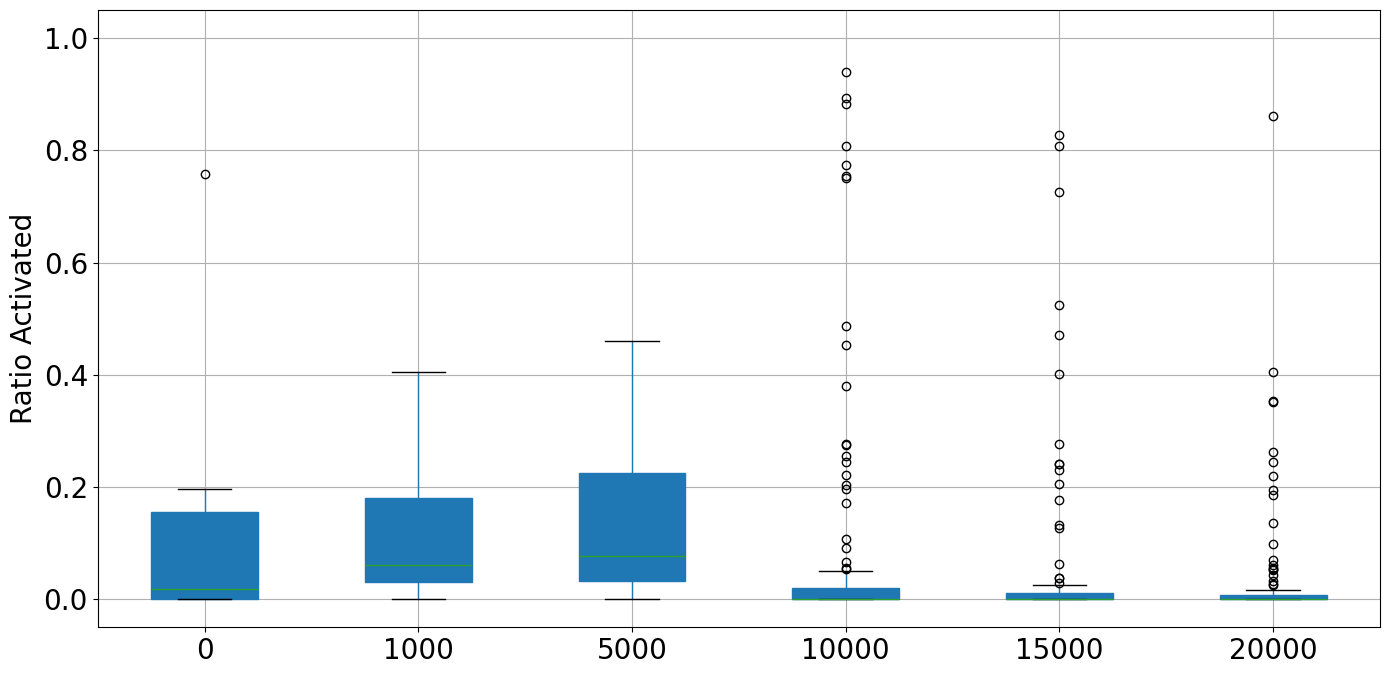

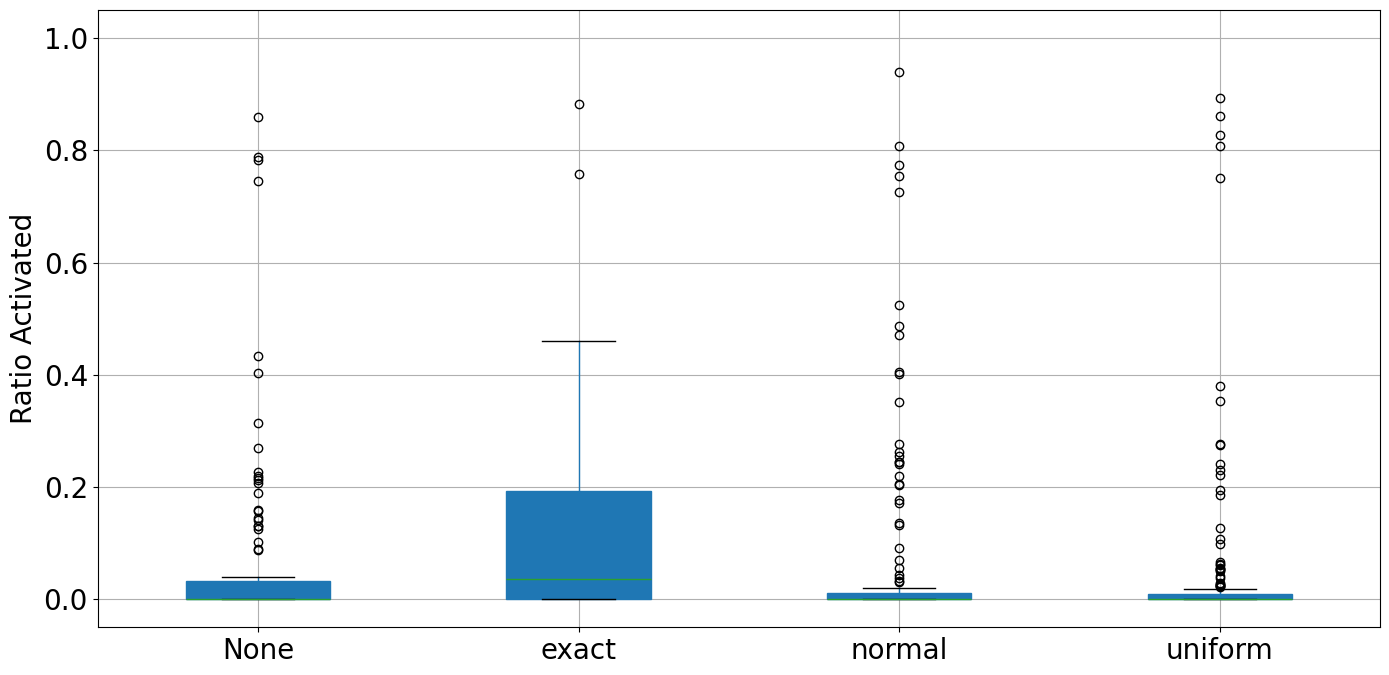

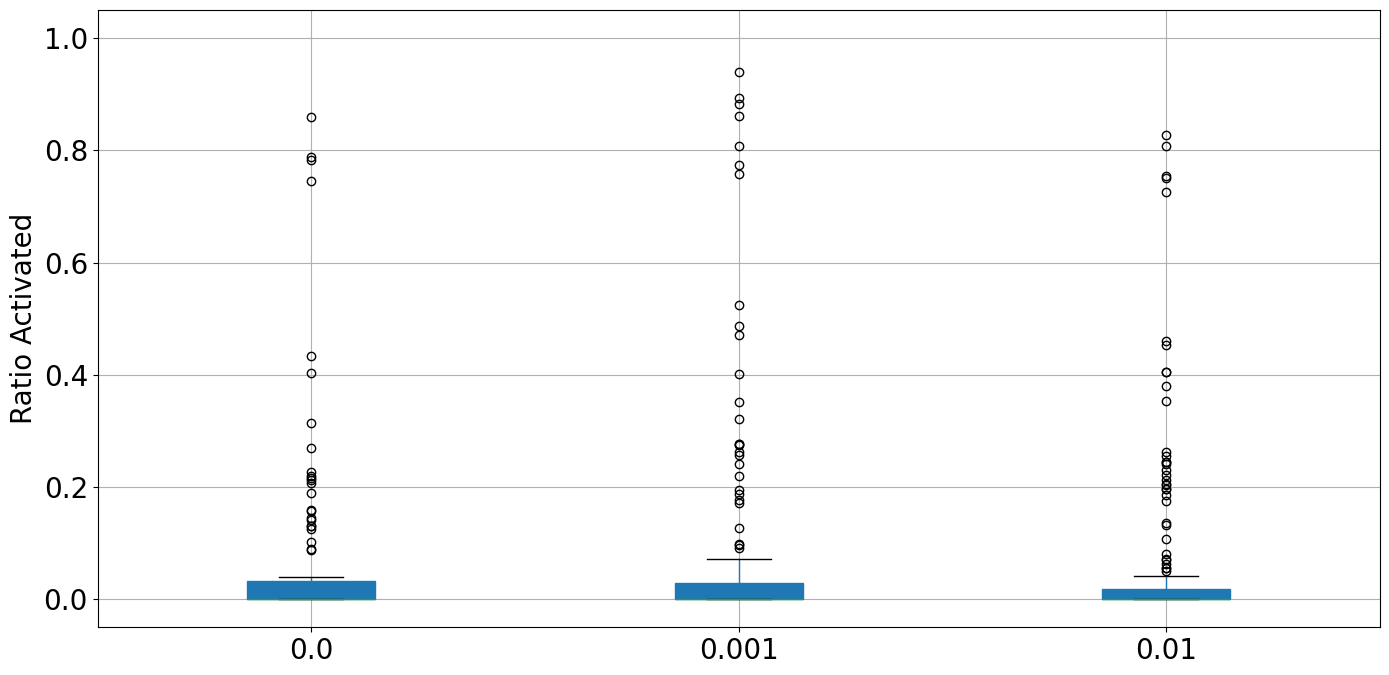

In [110]:
fontsize=20

def replace_label(x):
    return (
        x
        .replace("POSITIVE_INTERVAL_PROJECTED", "PR")
        .replace("POSITIVE_INTERVAL_REPARAMETRIZED", "PRR")
        .replace("POSITIVE", "Positive")
        .replace("RAW", "Raw")
        .replace("False", r"CE")
        .replace("True", r"BCE")
        .replace("3219456.0", "3M")
        .replace("10006528.0", "10M")
        .replace("dual", "Dual")
        .replace("softplus", "Positive")
        .replace("identity", "Raw")

    )

hyperparam_list = [
    "apply_one_hot_target.datamodule",  # BCE vs Cross Entropy
    # "learning_rate",
    "weight",  # softplus vs identity
    "bias_optim_mode",  # biais
    "loss_regu_str",  # None, Regu
    "loss_regu_delay",  # au bout de cb de batch on lance la régu
    "kwargs_loss_regu",  # None, exact, uniform, normal
    "loss_coef_regu",  # c
    # "n_params_total",
]

for hyperparam in hyperparam_list:
    cur_df = df[
        (df["n_params_total"] == 3219456.0)
        # (df["loss_regu_delay"] != 0)
    ]
    if hyperparam in ["loss_regu_delay", ]:
        cur_df = cur_df[cur_df["loss_regu_str"] != "None"]

    # n_values = len(cur_df[hyperparam].unique())

    fig, ax = plt.subplots(1, 1, figsize=(14, 7))
    # centers = (n_values) * np.arange(n_values)

    cur_df.boxplot(
        column="ratio_params_activated", by=hyperparam, ax=ax, return_type="both", patch_artist=True, 
        # positions=centers
    )
    ticks = [replace_label(k.get_text()) for k in ax.get_xticklabels()]
    # ticks = [replace_label(k.get_text()) for k in ax.get_xticklabels()[:n_values]]
    # ax.set_xticks(centers, )
    ax.set_xticklabels(ticks, fontsize=fontsize)
    ax.set_title("")
    fig.suptitle("")
    # fig.suptitle(f"{hyperparam}, {len(cur_df)}")
    ax.set_xlabel("")
    ax.set_ylabel("Ratio Activated", fontsize=fontsize)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=fontsize)
    # ax.scatter([xmax*.95], [ymax*.95], c="white")
    # ax.legend(custom_lines, ["float", "binary"], fontsize=fontsize, bbox_to_anchor=(1, 1))
    ax.set_ylim(-0.05, 1.05)
    title = f"figures_for_manuscript/chapter7/boxplot_activation_mnist_classif_dense_ls1_{hyperparam}.png"
    fig.tight_layout()
    fig.savefig(title)
    # ax.legend()

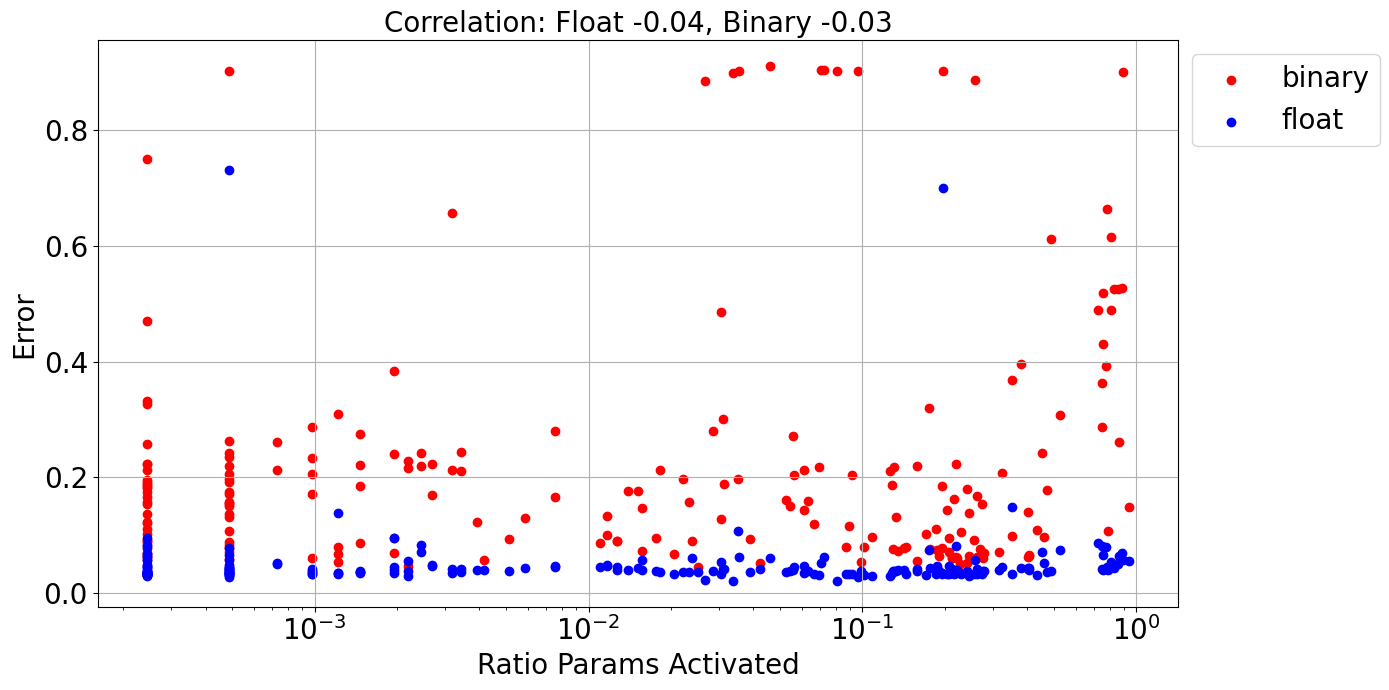

In [139]:
cur_df = df[df["n_params_total"] == 3219456.0]

plt.figure(figsize=(14, 7))
plt.scatter(
    cur_df["ratio_params_activated"],
    cur_df["binary_test_error"],
    c="r", label="binary"
)
plt.scatter(
    cur_df["ratio_params_activated"],
    cur_df["test_error"],
    c="b", label="float"
)
plt.grid()
plt.xscale("log")
plt.xlabel("Ratio Params Activated", fontsize=20)
plt.ylabel("Error", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(bbox_to_anchor=(1, 1), fontsize=20)
cor_binary = np.corrcoef(cur_df["ratio_params_activated"], cur_df["binary_test_error"])[0, 1]
cor_float = np.corrcoef(cur_df["ratio_params_activated"], cur_df["test_error"])[0, 1]
plt.title(f"Correlation: Float {cor_float:.2f}, Binary {cor_binary:.2f}", fontsize=20)
plt.tight_layout()
plt.savefig("figures_for_manuscript/chapter7/corr_activation_error.png")

In [68]:
df["binary_partial_test_accuracy"]

0      0.9673
1      0.9658
2      0.9777
3      0.9784
4      0.9778
        ...  
726    0.9697
727    0.9710
728    0.9700
729    0.1186
730    0.2100
Name: binary_partial_test_accuracy, Length: 731, dtype: float64

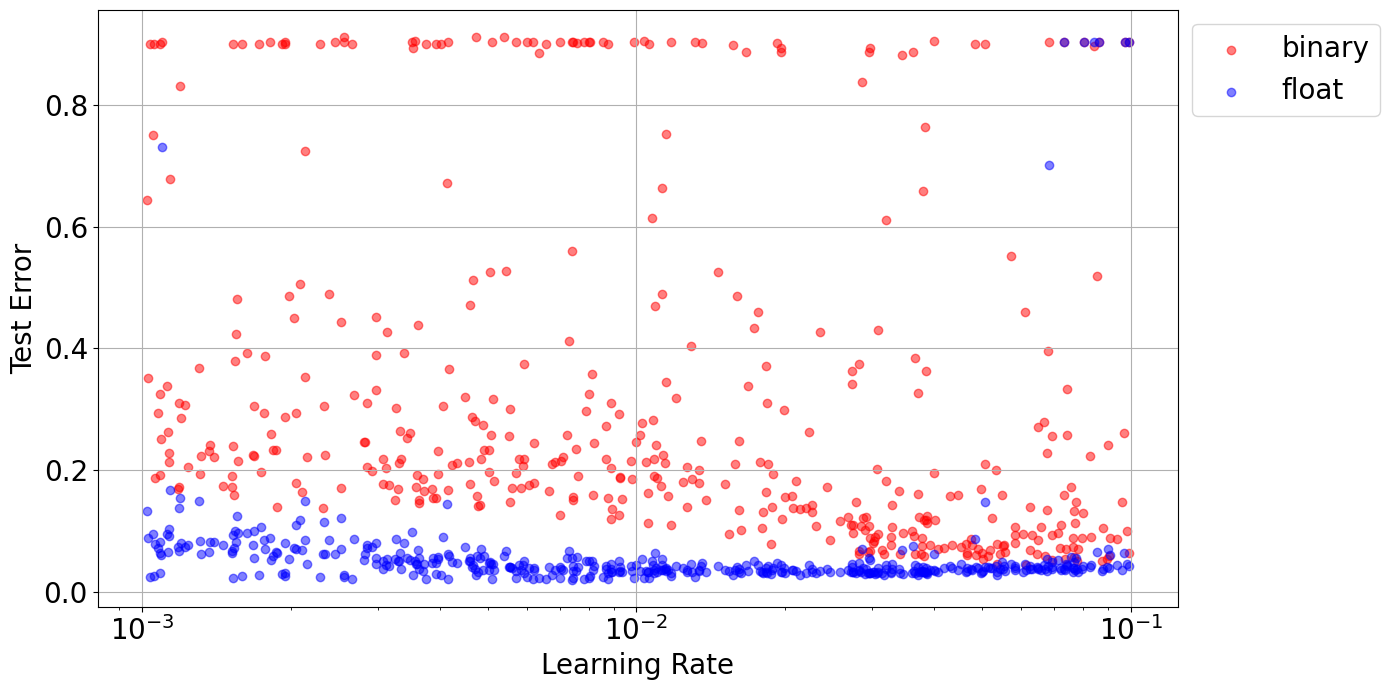

In [79]:
cur_df = df[
    (df["n_params_total"] == 3219456.0)
    # (df["loss_regu_delay"] != 0)
]

plt.figure(figsize=(14, 7))
plt.scatter(
    cur_df["learning_rate"], 
    cur_df["binary_test_error"], 
    c="r", label="binary", alpha=.5
)
plt.scatter(
    cur_df["learning_rate"], 
    cur_df["test_error"], 
    c="b", label="float", alpha=.5
)
# plt.scatter(
#     df["learning_rate"], 
#     df["binary_partial_test_error"], 
#     c="g", label="partial", alpha=.5
# )
plt.ylabel("Test Error", fontsize=20)
plt.xlabel("Learning Rate", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xscale("log")
plt.grid()
plt.legend(bbox_to_anchor=(1, 1), fontsize=20)
title = f"figures_for_manuscript/chapter7/boxplot_mnist_classif_dense_ls1_lr.png"
plt.tight_layout()
# plt.savefig(title)



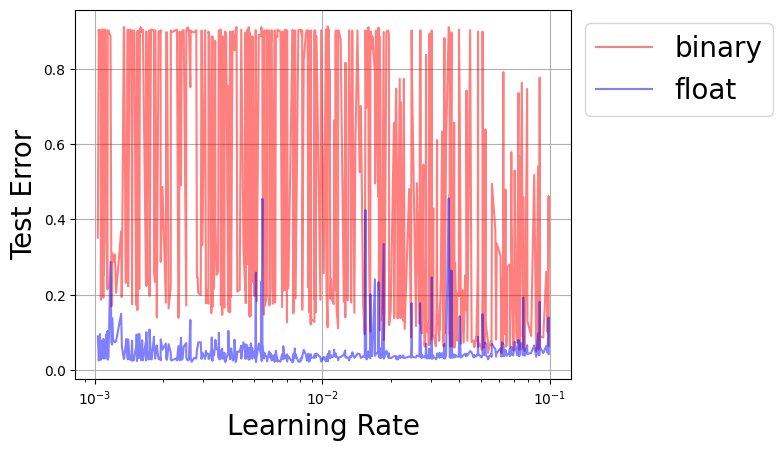

In [24]:
cur_df = df[df["test_error"] < .5]

indeces = cur_df["learning_rate"].argsort()



plt.plot(
    cur_df.iloc[indeces]["learning_rate"], 
    cur_df.iloc[indeces]["binary_test_error"], 
    c="r", label="binary", alpha=.5
)
plt.plot(
    cur_df.iloc[indeces]["learning_rate"], 
    cur_df.iloc[indeces]["test_error"], 
    c="b", label="float", alpha=.5
)
# plt.scatter(
#     df["learning_rate"], 
#     df["binary_partial_test_error"], 
#     c="g", label="partial", alpha=.5
# )
plt.ylabel("Test Error", fontsize=20)
plt.xlabel("Learning Rate", fontsize=20)
plt.xscale("log")
plt.grid()
plt.legend(bbox_to_anchor=(1, 1), fontsize=20)


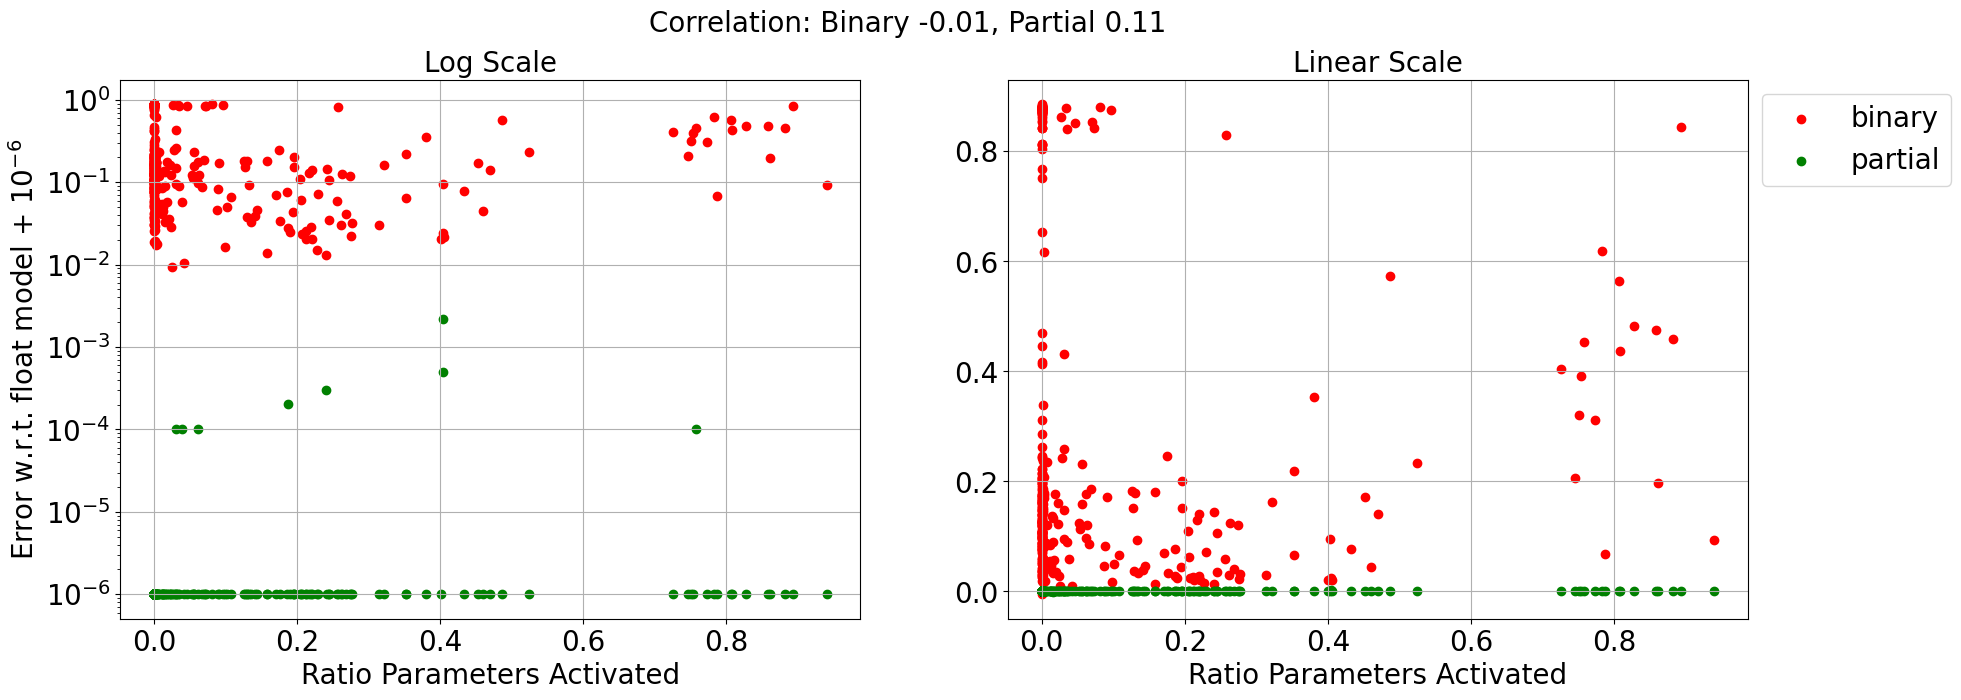

In [143]:
cur_df = df[
    (df["n_params_total"] == 3219456.0)
    # (df["loss_regu_delay"] != 0)
]

plt.figure(figsize=(21, 7))

plt.subplot(121)
plt.scatter(cur_df["ratio_params_activated"], cur_df["binary_error"]+1e-6, label="binary", c="r")
plt.scatter(cur_df["ratio_params_activated"], cur_df["partial_binary_error"]+1e-6, label="partial", c="g")
plt.yscale('log')
plt.xlabel("Ratio Parameters Activated", fontsize=20)
plt.ylabel("Error w.r.t. float model + $10^{-6}$", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.title("Log Scale", fontsize=20)
plt.grid()
# plt.legend(bbox_to_anchor=(1, 1), fontsize=20)

plt.subplot(122)
plt.scatter(cur_df["ratio_params_activated"], cur_df["binary_error"], label="binary", c="r")
plt.scatter(cur_df["ratio_params_activated"], cur_df["partial_binary_error"], label="partial", c="g")
plt.xlabel("Ratio Parameters Activated", fontsize=20)
# plt.ylabel("Error w.r.t. float model", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.title("Linear Scale", fontsize=20)
plt.grid()
plt.legend(bbox_to_anchor=(1, 1), fontsize=20)

cor_binary = np.corrcoef(cur_df["ratio_params_activated"], cur_df["binary_error"])[0, 1]
cor_partial = np.corrcoef(cur_df["ratio_params_activated"], cur_df["partial_binary_error"])[0, 1]
plt.suptitle(f"Correlation: Binary {cor_binary:.2f}, Partial {cor_partial:.2f}", fontsize=20)
plt.savefig("figures_for_manuscript/chapter7/activation_vs_error_to_float.png")

# plt.scatter(cur_df["ratio_params_activated"], cur_df["binary_test_accuracy"], label="binary")
# plt.scatter(cur_df["ratio_params_activated"], cur_df["partial_binary_error"], label="partial")
# plt.grid()

In [50]:
df["kwargs_loss_regu"].value_counts()

None       489
uniform    105
normal      95
exact       42
Name: kwargs_loss_regu, dtype: int64

In [11]:
df["loss_regu_int"] = df["kwargs_loss_regu"].apply(lambda x: len(x))

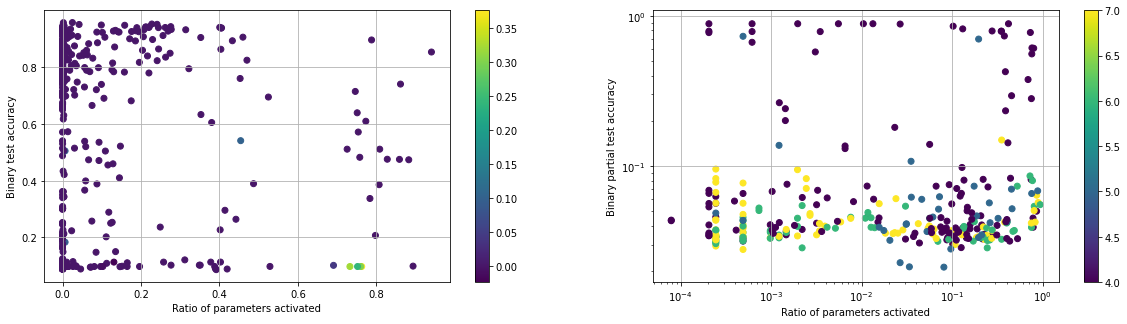

In [13]:
cur_df = df
# cur_df = df[df["partial_binary_error"] < 0.1]

plt.figure(figsize=(20, 5))
plt.subplot(121)
plt.scatter(cur_df["ratio_params_activated"], cur_df["binary_test_accuracy"], c=cur_df["partial_binary_error"])
plt.colorbar()
plt.xlabel("Ratio of parameters activated")
plt.ylabel("Binary test accuracy")
plt.grid()

plt.subplot(122)
# plt.scatter(cur_df["ratio_params_activated"], 1-cur_df["binary_partial_test_accuracy"].astype(float)+1e-6, c=np.log(cur_df["partial_binary_error"] + 1e-6))
plt.scatter(cur_df["ratio_params_activated"], 1-cur_df["binary_partial_test_accuracy"].astype(float)+1e-6, c=cur_df["loss_regu_int"])
plt.colorbar()
plt.xlabel("Ratio of parameters activated")
plt.ylabel("Binary partial test accuracy")
plt.xscale('log')
plt.yscale('log')
plt.grid()

In [14]:
cur_df["binary_partial_test_accuracy"]

0      0.9673
1      0.9658
2      0.9777
3      0.9784
4      0.9778
        ...  
726    0.9697
727     0.971
728      0.97
729    0.1186
730      0.21
Name: binary_partial_test_accuracy, Length: 731, dtype: object

In [61]:
hyperparam_list = [
    "apply_one_hot_target.datamodule",  # BCE vs Cross Entropy
    "learning_rate",
    "weight",  # softplus vs identity
    "bias_optim_mode",  # biais
    "loss_regu_str",  # None, Regu
    "loss_regu_delay",  # au bout de cb de batch on lance la régu
    "kwargs_loss_regu",  # None, exact, uniform, normal
    "loss_coef_data",  # 1 * loss_data + c * loss_regu
    "loss_coef_regu",  # c
    "n_params_total",
]

metrics_list = [
    "train_accuracy",
    "val_accuracy",
    "test_accuracy",
    "binary_train_accuracy",
    "binary_val_accuracy",
    "binary_test_accuracy",
    # "binary_partial_test_accuracy",
    "ratio_params_activated",
    "float_diff_val_test",
    "binary_diff_val_test",
    "ratio_params_activated"
]

In [66]:
row.index.to_list()

['Unnamed: 0',
 'args',
 'tb_path',
 'weights',
 'normalized_weights',
 'bias',
 'dice',
 'baseline_dice',
 'binary_mode_dice',
 'convergence_dice',
 'activation_P',
 'learned_selem',
 'convergence_layer',
 'target_selem',
 'target_operation',
 'learned_weights_viz',
 'learned_selems_viz',
 'stopping_reason',
 'test_accuracy',
 'test_loss',
 'train_accuracy',
 'train_loss',
 'val_accuracy',
 'val_loss',
 'binary_test_accuracy',
 'binary_test_loss',
 'binary_train_accuracy',
 'binary_train_loss',
 'binary_val_accuracy',
 'binary_val_loss',
 'convergence_test_accuracy',
 'convergence_test_loss',
 'convergence_train_accuracy',
 'convergence_train_loss',
 'convergence_val_accuracy',
 'convergence_val_loss',
 'n_bise_activated',
 'n_bise_dilation',
 'n_bise_erosion',
 'n_bise_total',
 'n_params_activated',
 'n_params_total',
 'ratio_bise_activated',
 'ratio_bise_dilation',
 'ratio_bise_erosion',
 'ratio_params_activated',
 'loss_train',
 'loss_train_data',
 'optimizer',
 'loss_data',
 'thre

In [74]:
df["bias_optim_mode"].unique()

array(['POSITIVE_INTERVAL_REPARAMETRIZED', 'RAW', 'POSITIVE',
       'POSITIVE_INTERVAL_PROJECTED'], dtype=object)

In [75]:
cur_df = df[
    (df["n_params_total"] == 3219456.0) &
    (df["bias_optim_mode"] == "POSITIVE_INTERVAL_REPARAMETRIZED")
]
best_bin_idxes = cur_df["test_error"].argsort().values
row = cur_df.iloc[best_bin_idxes[0]]

# print("Best test accuracy global (without checking from val)")
print(row["tb_path"])
print("================================")
# print(row[[hyperparam_list + metrics_list]])
print(row[[k for k in hyperparam_list + metrics_list if k in row.index.to_list()]])

print("Test error", 1 - row["test_accuracy"])
print("Binary test error", 1 - row["binary_test_accuracy"])

deep_morpho/results/results_tensorboards/Bimonn_exp_80/sandbox/dual_weights/0_/0/mnistclassifchannel/BimonnDenseNotBinary/version_10
apply_one_hot_target.datamodule                                True
learning_rate                                              0.037022
weight                                                         dual
bias_optim_mode                    POSITIVE_INTERVAL_REPARAMETRIZED
loss_regu_str                            RegularizationProjConstant
loss_regu_delay                                               20000
kwargs_loss_regu                                            uniform
loss_coef_data                                        (' 1\n', '1')
loss_coef_regu                                                 0.01
n_params_total                                            3219456.0
train_accuracy                                             0.986328
val_accuracy                                                   0.97
test_accuracy                                      

In [16]:
best_bin_idxes = df["binary_test_error"].argsort()
row = df.iloc[best_bin_idxes[0]]

print("Best test accuracy global (without checking from val)")
print(row["tb_path"])
print("================================")
print(row[hyperparam_list + metrics_list])

print("Test error", 1 - row["test_accuracy"])
print("Binary test error", 1 - row["binary_test_accuracy"])

Best test accuracy global (without checking from val)
deep_morpho/results/results_tensorboards/Bimonn_exp_80/sandbox/positive_weights/0_/5/mnistclassifchannel/BimonnDenseNotBinary/version_77
apply_one_hot_target.datamodule                               false
learning_rate                                  0.061379057680883406
weight                                                     softplus
bias_optim_mode                    POSITIVE_INTERVAL_REPARAMETRIZED
loss_regu_str                            RegularizationProjConstant
loss_regu_delay                                               20000
kwargs_loss_regu                                            uniform
loss_coef_data                                            ( 1\n, 1)
loss_coef_regu                                                 0.01
n_params_total                                            3219456.0
train_accuracy                                   0.9822916666666667
val_accuracy                                                 

In [110]:
cur_df = df[df["weight"] != "identity"]
best_bin_idxes = cur_df["binary_val_accuracy"].argsort()[::-1]

row = cur_df.iloc[best_bin_idxes[0]]

print("Best test accuracy global (with checking from val)")
print(row["tb_path"])
print("================================")
print(row[hyperparam_list + metrics_list])

print("Test error", 1 - row["test_accuracy"])
print("Binary test error", 1 - row["binary_test_accuracy"])

Best test accuracy global (with checking from val)
deep_morpho/results/results_tensorboards/Bimonn_exp_80/ruche/positive_weights/0_/5/mnistclassifchannel/BimonnDenseNotBinary/version_52
apply_one_hot_target.datamodule                               false
learning_rate                                   0.01057331978406285
weight                                                     softplus
bias_optim_mode                    POSITIVE_INTERVAL_REPARAMETRIZED
loss_regu_str                                                  None
loss_regu_delay                                                   0
kwargs_loss_regu                                               None
loss_coef_data                                            ( 1\n, 1)
loss_coef_regu                                                    0
n_params_total                                           10006528.0
train_accuracy                                         0.9833984375
val_accuracy                                                 0.953

In [17]:
cur_df = df[df["weight"] == "identity"]
best_val_idexs = cur_df["val_accuracy"].argsort().values[::-1]
row = cur_df.iloc[best_val_idexs[0]]

print("Best test accuracy for identity weights (with checking from val)")
print(row["tb_path"])
print("================================")

print(row[hyperparam_list + metrics_list])

print("Test error", 1 - row["test_accuracy"])
print("Binary test error", 1 - row["binary_test_accuracy"])


Best test accuracy for identity weights (with checking from val)
deep_morpho/results/results_tensorboards/Bimonn_exp_80/sandbox/positive_weights/0_/0/mnistclassifchannel/BimonnDenseNotBinary/version_8
apply_one_hot_target.datamodule                    true
learning_rate                      0.006178523666090855
weight                                         identity
bias_optim_mode                                     RAW
loss_regu_str                                      None
loss_regu_delay                                    1000
kwargs_loss_regu                                   None
loss_coef_data                                ( 1\n, 1)
loss_coef_regu                                        0
n_params_total                                3219456.0
train_accuracy                                      1.0
val_accuracy                                     0.9803
test_accuracy                                    0.9784
binary_train_accuracy                      0.1025390625
binary_val_accu

In [44]:
cur_df = df[df["loss_regu_str"] == "None"]
best_val_accs = cur_df["binary_val_accuracy"].argsort().values[::-1]
row = cur_df.iloc[best_val_accs[0]]

print("Best test accuracy for softplus weights and no regu (with checking from val)")
print(row["tb_path"])
print("================================")
print(row[hyperparam_list + metrics_list])

print("Test error", 1 - row["test_accuracy"])
print("Binary test error", 1 - row["binary_test_accuracy"])



Best test accuracy for softplus weights and no regu (with checking from val)
deep_morpho/results/results_tensorboards/Bimonn_exp_80/sandbox/positive_weights/0_/0/mnistclassifchannel/BimonnDenseNotBinary/version_72
apply_one_hot_target.datamodule                   true
learning_rate                      0.09794723593059812
weight                                        softplus
bias_optim_mode                               POSITIVE
loss_regu_str                                     None
loss_regu_delay                                   1000
kwargs_loss_regu                                  None
loss_coef_data                               ( 1\n, 1)
loss_coef_regu                                       0
n_params_total                               3219456.0
train_accuracy                            0.9775390625
val_accuracy                                    0.9573
test_accuracy                                   0.9539
binary_train_accuracy                     0.9541015625
binary_val_accur

In [45]:
cur_df = df[df["kwargs_loss_regu"] == "exact"]  # "None", "exact", "uniform", "normal"
best_val_idexs = cur_df["binary_val_accuracy"].argsort().values[::-1]
row = cur_df.iloc[best_val_idexs[0]]


print("Best test accuracy for softplus weights and exact constant regu (with checking from val)")
print(row["tb_path"])
print("================================")
print(row[hyperparam_list + metrics_list])

print("Test error", 1 - row["test_accuracy"])
print("Binary test error", 1 - row["binary_test_accuracy"])


Best test accuracy for softplus weights and exact constant regu (with checking from val)
deep_morpho/results/results_tensorboards/Bimonn_exp_80/ruche/positive_weights/0_/3/mnistclassifchannel/BimonnDenseNotBinary/version_5
apply_one_hot_target.datamodule                               false
learning_rate                                  0.041880150350157797
weight                                                     softplus
bias_optim_mode                    POSITIVE_INTERVAL_REPARAMETRIZED
loss_regu_str                            RegularizationProjConstant
loss_regu_delay                                               10000
kwargs_loss_regu                                              exact
loss_coef_data                                            ( 1\n, 1)
loss_coef_regu                                                 0.01
n_params_total                                            3219456.0
train_accuracy                                         0.9833984375
val_accuracy                 

In [46]:
cur_df = df[df["kwargs_loss_regu"] == "normal"]  # "None", "exact", "uniform", "normal"
best_val_idexs = cur_df["binary_val_accuracy"].argsort().values[::-1]
row = cur_df.iloc[best_val_idexs[0]]

print("Best test accuracy for softplus weights and normal regu (with checking from val)")
print(row["tb_path"])
print("================================")
print(row[hyperparam_list + metrics_list])



print("Test error", 1 - row["test_accuracy"])
print("Binary test error", 1 - row["binary_test_accuracy"])


Best test accuracy for softplus weights and normal regu (with checking from val)
deep_morpho/results/results_tensorboards/Bimonn_exp_80/sandbox/positive_weights/0_/5/mnistclassifchannel/BimonnDenseNotBinary/version_37
apply_one_hot_target.datamodule                         false
learning_rate                             0.05356532593096981
weight                                               softplus
bias_optim_mode                                           RAW
loss_regu_str                      RegularizationProjConstant
loss_regu_delay                                         10000
kwargs_loss_regu                                       normal
loss_coef_data                                      ( 1\n, 1)
loss_coef_regu                                          0.001
n_params_total                                      3219456.0
train_accuracy                                    0.982421875
val_accuracy                                            0.972
test_accuracy                         

In [47]:
cur_df = df[df["kwargs_loss_regu"] == "uniform"]  # "None", "exact", "uniform", "normal"
best_val_idexs = cur_df["binary_val_accuracy"].argsort().values[::-1]
row = cur_df.iloc[best_val_idexs[0]]

print("Best test accuracy for softplus weights and uniform regu (with checking from val)")
print(row["tb_path"])
print("================================")
print(row[hyperparam_list + metrics_list])


print("Test error", 1 - row["test_accuracy"])
print("Binary test error", 1 - row["binary_test_accuracy"])


Best test accuracy for softplus weights and uniform regu (with checking from val)
deep_morpho/results/results_tensorboards/Bimonn_exp_80/sandbox/positive_weights/0_/5/mnistclassifchannel/BimonnDenseNotBinary/version_77
apply_one_hot_target.datamodule                               false
learning_rate                                  0.061379057680883406
weight                                                     softplus
bias_optim_mode                    POSITIVE_INTERVAL_REPARAMETRIZED
loss_regu_str                            RegularizationProjConstant
loss_regu_delay                                               20000
kwargs_loss_regu                                            uniform
loss_coef_data                                            ( 1\n, 1)
loss_coef_regu                                                 0.01
n_params_total                                            3219456.0
train_accuracy                                   0.9822916666666667
val_accuracy                     

In [94]:
df.loc[df["kwargs_loss_regu"] == "exact", ["loss_regu_delay"]].value_counts()

loss_regu_delay
10000              13
5000               12
1000               11
0                   6
dtype: int64

/tmp/ipykernel_23002/3016254119.py:55: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 1)


,float hp,mean,median,max,min
0,0,0.064775,0.05655,0.0987,0.0473
0,1000,0.056181,0.04050,0.7313,0.0286
0,5000,0.051557,0.04340,0.1075,0.0348
0,10000,0.046297,0.03905,0.1373,0.0278
0,15000,0.048520,0.03980,0.0963,0.0304
0,20000,0.047691,0.03975,0.1490,0.0285


,binary hp,mean,median,max,min
0,0,0.805700,0.9012,0.9020,0.5184
0,1000,0.209792,0.1761,0.9020,0.0503
0,5000,0.148414,0.1602,0.2073,0.0607
0,10000,0.214194,0.1652,0.9006,0.0456
0,15000,0.189350,0.1682,0.5252,0.0514
0,20000,0.166728,0.1736,0.3683,0.0452


,activated hp,mean,median,max,min
0,0,0.189392,0.000000,0.757568,0.000000
0,1000,0.129092,0.030518,0.858643,0.000000
0,5000,0.192104,0.211914,0.459717,0.000488
0,10000,0.135362,0.001709,0.940186,0.000000
0,15000,0.080106,0.000488,0.827637,0.000000
0,20000,0.053628,0.000488,0.861328,0.000000


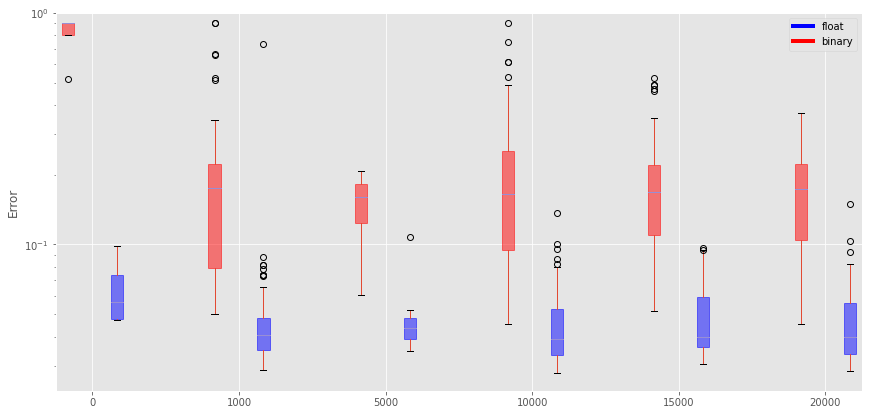

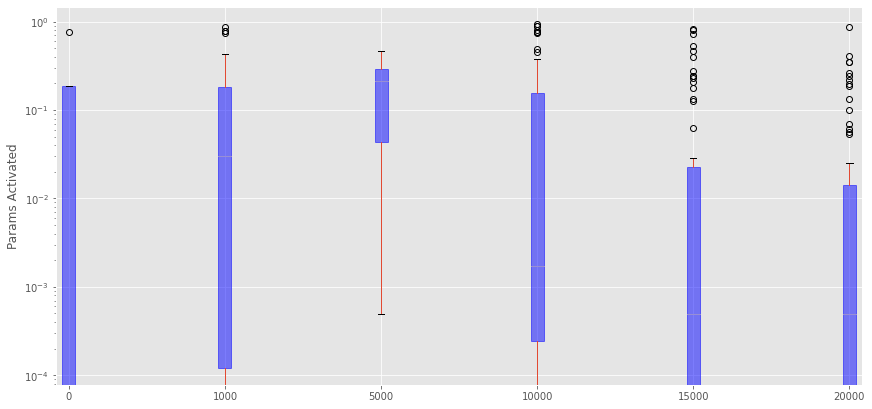

In [92]:
# 
import matplotlib.pyplot as plt  
plt.style.use('ggplot')

custom_lines = [Line2D([0], [0], color="blue", lw=4), Line2D([0], [0], color="red", lw=4)]
cur_df = df[
    (df["weight"] == "softplus") &
    (df["n_params_total"] == 3219456) &
    # (df["loss_regu_str"] == "None")
    # (df["kwargs_loss_regu"] == "exact")
    # (df["n_params_total"] == 10006528)
    # df
    # df[df["weight"] == "softplus"]
    # df[df["loss_regu_str"] == "RegularizationProjConstant"]
    # df[df["n_params_total"] == 3219456]
    # df[df["n_params_total"] == 10006528]
    np.ones(len(df), dtype=bool)
]


for hyperparam in [
    # "apply_one_hot_target.datamodule",
    # "learning_rate",
    # "weight",
    # "bias_optim_mode",
    # "loss_regu_str",
    "loss_regu_delay",
    # "kwargs_loss_regu",
    # "loss_coef_data",
    # "loss_coef_regu"
]:
    n_values = len(cur_df[hyperparam].unique())
    fig, ax = plt.subplots(1, 1, figsize=(14, 7))
    centers = (n_values) * np.arange(n_values)
    cur_df.boxplot(
        column="test_error", by=hyperparam, ax=ax, return_type="both", patch_artist=True, boxprops=dict(alpha=.5, facecolor="blue", color="blue", ), 
        positions=centers + .2*max((n_values- 1), 1)
    )
    cur_df.boxplot(
        column="binary_test_error", by=hyperparam, ax=ax, return_type="both", patch_artist=True, boxprops=dict(alpha=.5, facecolor="red", color="red", ),
        positions=centers - .2*max((n_values- 1), 1)
    )
    # Log scale
    ax.set_yscale("log")
    # Max, min, mean, median

    ticks = ax.get_xticklabels()[:n_values]
    ax.set_xticks(centers)
    ax.set_xticklabels(ticks)
    ax.set_title("")
    fig.suptitle("")
    ax.set_xlabel("")
    ax.set_ylabel("Error")
    ax.legend(custom_lines, ["float", "binary"])
    ax.set_ylim(0, 1)

    fig, ax = plt.subplots(1, 1, figsize=(14, 7))
    cur_df.boxplot(
        column="ratio_params_activated", by=hyperparam, ax=ax, return_type="both", patch_artist=True, boxprops=dict(alpha=.5, facecolor="blue", color="blue", ), 
        positions=centers
    )
    # ax.legend([custom_lines[0]], ["ratio_params_activated"])
    ax.set_title("")
    fig.suptitle("")
    ax.set_xlabel("")
    ax.set_ylabel("Params Activated")
    ax.set_yscale("log")


    float_df = []
    binary_df = []
    activated_df = []
    for hp in sorted(cur_df[hyperparam].unique()):
        cur_df_hp = cur_df[cur_df[hyperparam] == hp]
        float_df.append(pd.DataFrame({
            "float hp": [hp],
            "mean": [cur_df_hp["test_error"].mean()],
            "median": [cur_df_hp["test_error"].median()],
            "max": [cur_df_hp["test_error"].max()],
            "min": [cur_df_hp["test_error"].min()],
        }))
        binary_df.append(pd.DataFrame({
            "binary hp": [hp],
            "mean": [cur_df_hp["binary_test_error"].mean()],
            "median": [cur_df_hp["binary_test_error"].median()],
            "max": [cur_df_hp["binary_test_error"].max()],
            "min": [cur_df_hp["binary_test_error"].min()],
        }))
        activated_df.append(pd.DataFrame({
            "activated hp": [hp],
            "mean": [cur_df_hp["ratio_params_activated"].mean()],
            "median": [cur_df_hp["ratio_params_activated"].median()],
            "max": [cur_df_hp["ratio_params_activated"].max()],
            "min": [cur_df_hp["ratio_params_activated"].min()],
        }))
    # print('float error')
    float_df = pd.concat(float_df)
    # print('binary error')
    binary_df = pd.concat(binary_df)
    # print('activated')
    activated_df = pd.concat(activated_df)

    display(float_df)
    display(binary_df)
    display(activated_df)

    # ax.set_xticklabels(df[hyperparam].unique())

    

0       normal
1       normal
2       normal
3       normal
4      uniform
        ...   
118     normal
119    uniform
120     normal
121     normal
122     normal
Name: kwargs_loss_regu, Length: 123, dtype: object

## NoiSti

In [140]:
tb_path_success = "deep_morpho/results/results_tensorboards/Bimonn_exp_75/sandbox/0/dual_bisel/softplus/sticks_noised/sticks_noised/version_19"
tb_path_success = join(tb_path_success, 'checkpoints', os.listdir(join(tb_path_success, 'checkpoints'))[0])

tb_path_placeholder = "/hdd/aouadt/these/projets/Bimonn_LBQNN2023/results/results_tensorboards/debug_noisti/10/noisti/bimonn/version_0"
tb_path_placeholder = join(tb_path_placeholder, 'best_weights', os.listdir(join(tb_path_placeholder, 'best_weights'))[0])

loss = nn.BCELoss()
model_placeholder = models.LightningBiMoNN.load_from_checkpoint(tb_path_placeholder, loss=loss)


In [141]:
import re
from collections import OrderedDict

st = torch.load(tb_path_success)["state_dict"]

cur = {}
for key, value in st.items():
    layer_idx = re.findall(r"layer(\d+)", key)[0]
    cur[layer_idx] = cur.get(layer_idx, {})
    if "bise" in key:
        bise_idx = re.findall(r"bise_(\d+)", key)[0]
        if f"bise_{bise_idx}" not in cur[layer_idx]:
            cur[layer_idx][f"bise_{bise_idx}"] = {}
        cur[layer_idx][f"bise_{bise_idx}"][key.split(f".bise_{bise_idx}.")[-1]] = value
        

    if "lui" in key:
        lui_idx = re.findall(r"lui_(\d+)", key)[0]
        if f"lui_{lui_idx}" not in cur[layer_idx]:
            cur[layer_idx][f"lui_{lui_idx}"] = {}
        cur[layer_idx][f"lui_{lui_idx}"][key.split(f".lui_{lui_idx}.")[-1]] = value

new_st = OrderedDict()
layer_idxes = sorted(list(cur.keys()), key=lambda x: int(x))
for layer_idx in layer_idxes:
    all_bises = sorted([k for k in cur[layer_idx].keys() if "bise" in k], key=lambda x: int(x.split("_")[-1]))


    next_states = {param: [] for param in cur[layer_idx][all_bises[0]].keys()}
    for bise_key in all_bises:
        for param in cur[layer_idx][bise_key].keys():
            next_states[param].append(cur[layer_idx][bise_key][param])
    
    for param in next_states.keys():
        new_st[f"model.layers.{int(layer_idx)-1}.bises.{param}"] = torch.cat(next_states[param], dim=0)
    
    all_luis = sorted([k for k in cur[layer_idx].keys() if "lui" in k], key=lambda x: int(x.split("_")[-1]))
    next_states = {param: [] for param in cur[layer_idx][all_luis[0]].keys()}
    for lui_key in all_luis:
        for param in cur[layer_idx][lui_key].keys():
            next_states[param].append(cur[layer_idx][lui_key][param])

    for param in next_states.keys():
        new_st[f"model.layers.{int(layer_idx)-1}.luis.{param}"] = torch.cat(next_states[param], dim=0)
            

In [142]:
model_placeholder.load_state_dict(new_st)

<All keys matched successfully>

In [143]:
for layer in model_placeholder.model.layers:
    bise = layer.bises
    lui = layer.luis
    bise.closest_selem_handler = bcs.BiseClosestActivationSpaceIteratedPositive(bise_module=bise,**bise.closest_selem_args)
    lui.closest_selem_handler = bcs.BiseClosestActivationSpaceIteratedPositive(bise_module=lui,**lui.closest_selem_args)
        # bise.closest_selem_handler = bcs.BiseClosestMinDistOnCst(bise_module=bise,**bise.closest_selem_args)
model_placeholder.model.binary(True);

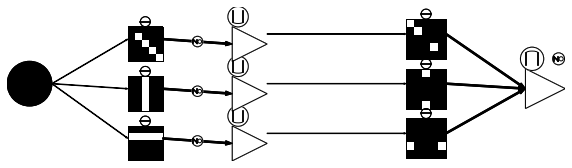

In [146]:
bimonn_viz.BimonnVizualiser(model_placeholder.model, mode="closest",).draw(figsize=(10, 5))

## Sandbox

In [4]:
%matplotlib inline

In [9]:
model_args = {
    "kernel_size": (5, 5),
    "channels": [1, 50],
    "atomic_element": 'bisel',
    "input_size": (28, 28),
    "n_classes": 10,
    "threshold_mode": {
        "weight": 'softplus',
        "activation": 'tanh',
    },
    "initializer_method": inits.InitBimonnEnum.INPUT_MEAN,
    "initializer_args": {
        "bise_init_method": inits.InitBiseEnum.CUSTOM_CONSTANT_RANDOM_BIAS,
        "lui_init_method": inits.InitBiseEnum.CUSTOM_CONSTANT_CONSTANT_WEIGHTS_RANDOM_BIAS,
        "bise_init_args": {"ub": 1e-2, "max_output_value": 0.95, "p_for_init": "auto"},
        "input_mean": .5,
    },
    "closest_selem_method": bise_base.ClosestSelemEnum.MIN_DIST_DIST_TO_CST,
    "bias_optim_mode": bise_base.BiseBiasOptimEnum.POSITIVE,
    "bias_optim_args": {"offset": 0},
    "weights_optim_mode": bise_base.BiseWeightsOptimEnum.THRESHOLDED,
    "weights_optim_args": {"constant_P": True, "factor": 1},
}

In [16]:
# reload_modules()
# tb_path = ("deep_morpho/results/DGMM_2022/sandbox/1/axspa_roi/version_7")
# tb_path = "/hdd/aouadt/these/projets/3d_segm/deep_morpho/results/results_tensorboards/Bimonn_exp_56/sandbox/2/softplus/diskorect/opening/disk/version_1"
# tb_path = "deep_morpho/results/results_tensorboards/Bimonn_exp_81/sandbox/0_/2/diskorect/bimonn/closing/hstick/version_0"
# tb_path = "/hdd/aouadt/these/projets/Bimonn_LBQNN2023/results/results_tensorboards/debug_noisti/10/noisti/bimonn/version_0"

tb_path = TB_PATHS[0]
# tb_path = "deep_morpho/results/results_tensorboards/Bimonn_exp_80/sandbox/positive_weights/0_/5/mnistclassifchannel/BimonnDenseNotBinary/version_77"
# tb_path = "deep_morpho/results/results_tensorboards/Bimonn_exp_80/sandbox/positive_weights/0_/5/mnistclassifchannel/BimonnDenseNotBinary/version_37"
# tb_path = "deep_morpho/results/results_tensorboards/Bimonn_exp_80/ruche/positive_weights/0_/3/mnistclassifchannel/BimonnDenseNotBinary/version_5"
# tb_path = "deep_morpho/results/results_tensorboards/Bimonn_exp_80/sandbox/positive_weights/0_/0/mnistclassifchannel/BimonnDenseNotBinary/version_8"

# tb_path = "deep_morpho/results/results_tensorboards/test/5/mnistclassifchannel/bimonndense/version_0"

# tb_path = "deep_morpho/results/results_tensorboards/test/bisel/softplus/classif_mnist/version_8"
# tb_path = "deep_morpho/results/results_tensorboards/Bimonn_exp_75/sandbox/0/dual_bisel/softplus/sticks_noised/sticks_noised/version_19"
# tb_path = "deep_morpho/results/results_tensorboards/Bimonn_exp_71/sandbox/0/bisel/softplus/diskorect/dilation/disk/version_4"

# tb_path = "/hdd/aouadt/these/projets/3d_segm/deep_morpho/results/results_tensorboards/test_refactor_lui/bisel2/softplus/diskorect/dilation/disk/version_0"


# df, global_args, changing_args = DisplayResults().get_df_from_tb_paths([tb_path])


# tb_path = join(tb_path, 'checkpoints', os.listdir(join(tb_path, 'checkpoints'))[0])
if os.path.exists(join(tb_path, 'best_weights')):
    tb_path = join(tb_path, 'best_weights', os.listdir(join(tb_path, 'best_weights'))[0])
elif os.path.exists(join(tb_path, 'checkpoints')):
    tb_path = join(tb_path, 'checkpoints', os.listdir(join(tb_path, 'checkpoints'))[0])

# bise_base.BiseBiasOptimEnum[df["bias_optim_mode"].iloc[0]]

loss = nn.BCELoss()
model = models.LightningBiMoNN.load_from_checkpoint(tb_path, loss=loss)
# model = models.LightningBiMoNNClassifierLastLinearNotBinary.load_from_checkpoint(tb_path, model_args=model_args, loss=None, learning_rate=None, optimizer=None,)
# model.to(device)
model.model.binary(True);
model.model.binary(False);
# model.model.binary(mode="partial")


In [17]:
from deep_morpho.experiments.experiment_classification import ExperimentClassificationChannel
from deep_morpho.experiments.parser import Parser
from deep_morpho.experiments.enforcers import ArgsClassifChannel, ArgsMnist
from deep_morpho.datasets.gray_to_channels_dataset import LevelsetValuesEqualIndex

import sys
sys.argv = [""]  # For parser.parse_args to work

args = Parser()
# args["batch_seed"] = 2249939862
args["batch_seed"] = 123123939
args["dataset"] = "mnistclassifchanneldataset"
args["model"] = "bimonndensenotbinary"
args["batch_size"] = 128
args["num_workers"] = 0
args["freq_scalars"] = 50
args["freq_imgs"] = None
args["freq_hist"] = None
args["freq_update_binary_batch"] = None
args["freq_update_binary_epoch"] = None
args["patience_reduce_lr"] = None
args["patience_loss"] = None
args['channel_classif_args'] = {
    "levelset_handler_mode": LevelsetValuesEqualIndex,
    # "levelset_handler_args": {"n_values": 10},
    "levelset_handler_args": {"n_values": 1},
}

args.parse_args(add_argv=False)
# args = {"dataset": "mnistclassifchanneldataset", "model": ""}

exp = ExperimentClassificationChannel(
    args=args,
    dest_dir="tmp/"
)
exp.model = model
exp.args_enforcers = [ArgsClassifChannel(), ArgsMnist()]
exp.setup()

obs_binary_partial_metrics = obs.BinaryPartialModeMetricClassifChannel(
    # metrics=exp.metric_binary_obs.metrics,
    metrics={"accuracy": exp.metric_binary_obs.metrics["accuracy"]},
    freq={"train": 1, "val": 1, "test": 1},
    plot_freq={"train": 1, "val": 1, "test": 100000},
    dataset=exp.trainloader.dataset,
)
exp.observables.append(obs_binary_partial_metrics)
model.observables = exp.observables

exp.test()


binary_acc = exp.metric_binary_obs.last_value["test"]["accuracy"]
float_acc = exp.metric_float_obs.last_value["test"]["accuracy"]
binary_partial_acc = obs_binary_partial_metrics.last_value["test"]["accuracy"]


print("Binary Error:", f"{1 - binary_acc:.4f}")
print("Binary Partial Error:", f"{1 - binary_partial_acc:.4f}")
print("Float Error:", f"{1 - float_acc:.4f}")

/hdd/aouadt/these/projets/3d_segm/deep_morpho/datasets/mnist_dataset.py:234: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  img=torch.tensor(choice(self.data).unsqueeze(0)),
GPU available: True, used: True
TPU available: False, using: 0 TPU cores
/hdd/python_venvs/torchenv/lib/python3.8/site-packages/pytorch_lightning/utilities/distributed.py:69: UserWarning: attribute 'loss' removed from hparams because it cannot be pickled
  warnings.warn(*args, **kwargs)
/hdd/python_venvs/torchenv/lib/python3.8/site-packages/pytorch_lightning/utilities/distributed.py:69: UserWarning: attribute 'reduce_loss_fn' removed from hparams because it cannot be pickled
  warnings.warn(*args, **kwargs)
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Seed: 123123939
Loading Data
Done in 00:00:00
Loading Observables
Done in 00:00:00
Loading Model
Done in 00:00:00
Model: LightningBimonnDenseNotBinary(
  (model): BimonnDenseNotBinary(
    (flatten): Flatten(start_dim=1, end_dim=-1)
    (layers): BinarySequential(
      (0): DenseLUI(
        (conv): Conv2d(784, 4096, kernel_size=(1, 1), stride=(1, 1), bias=False, padding_mode=replicate)
        (activation_threshold_layer): TanhLayer()
        (bias_handler): BiasBiseSoftplusReparametrized(
          (softplus_layer): Softplus(beta=1, threshold=20)
        )
        (weights_handler): WeightsThresholdedBise(
          (threshold_layer): SoftplusThresholdLayer()
        )
      )
      (1): DenseLuiNotBinary(
        (conv): Conv2d(4096, 10, kernel_size=(1, 1), stride=(1, 1), bias=False, padding_mode=replicate)
        (activation_threshold_layer): TanhLayer()
        (bias_handler): BiasBiseSoftplusReparametrized(
          (softplus_layer): Softplus(beta=1, threshold=20)
        )
  

/hdd/python_venvs/torchenv/lib/python3.8/site-packages/pytorch_lightning/utilities/distributed.py:69: UserWarning: The dataloader, test dataloader 0, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 24 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  warnings.warn(*args, **kwargs)


Testing: 0it [00:00, ?it/s]

--------------------------------------------------------------------------------
DATALOADER:0 TEST RESULTS
{'binary_mode/accuracy_test': 0.8242999911308289,
 'binary_mode/loss_test': 1.1322051286697388,
 'binary_mode/metrics_epoch_mean/per_batch_step/accuracy_test': 0.8243,
 'binary_mode/metrics_epoch_mean/per_batch_step/loss_test': 1.13220509185791,
 'binary_partial_mode/accuracy_test': 0.9672999978065491,
 'binary_partial_mode/loss_test': 0.030695782974362373,
 'binary_partial_mode/metrics_epoch_mean/per_batch_step/accuracy_test': 0.9673,
 'binary_partial_mode/metrics_epoch_mean/per_batch_step/loss_test': 0.03069578033015132,
 'loss/test': 0.030695708468556404,
 'metrics_batch/accuracy_test': 0.9672999978065491,
 'metrics_batch/loss_test': 0.030695708468556404,
 'metrics_epoch_mean/per_batch_step/accuracy_test': 0.9673,
 'metrics_epoch_mean/per_batch_step/loss_test': 0.030695709212869404}
--------------------------------------------------------------------------------
Binary Error: 0

In [8]:
exp.metric_binary_obs.metrics

{'accuracy': <function deep_morpho.metrics.accuracy.accuracy(y_true, y_pred)>,
 'loss': <function deep_morpho.observables.binary_mode_metric.BinaryModeMetricBase._update_metric_with_loss.<locals>.<lambda>(x, y)>}

In [18]:
model.model.to(device)
img, tar = next(iter(exp.testloader))
img = img.to(device)
img = img.view(img.shape[0], -1)

lui1 = model.model.layers[0]

otp_partial = lui1.forward_partial_binary(img)
otp_float = lui1.forward(img)
otp_binary = lui1.forward_binary(img)



In [19]:
diff1 = otp_partial - otp_float
diff2 = otp_partial - otp_binary
print(diff1[:, ~lui1.is_activated].abs().sum())
print(diff2[:, lui1.is_activated].abs().sum())

TensorGray(0., device='cuda:0', grad_fn=<AliasBackward0>)
TensorGray(0., device='cuda:0', grad_fn=<AliasBackward0>)


(array([5.85047262, 0.04445279, 0.0337309 , 0.03956142, 0.05918561,
        0.02956345, 0.02062203, 0.02171769, 0.03302656, 3.86766593]),
 array([0.        , 0.1       , 0.2       , 0.30000001, 0.40000001,
        0.5       , 0.60000002, 0.69999999, 0.80000001, 0.89999998,
        1.        ]),
 <BarContainer object of 10 artists>)

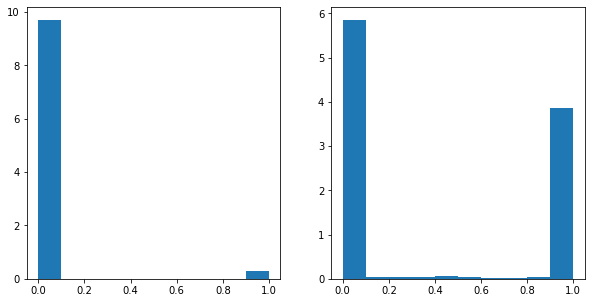

In [20]:
plt.figure(figsize=(10, 5))

plt.subplot(121)
plt.hist(otp[:, lui1.is_activated].detach().cpu().flatten(), density=True)

plt.subplot(122)
plt.hist(otp[:, lui1.is_activated == False].detach().cpu().flatten(), density=True)

In [161]:
# Change threhsold to reproduce the right results.

exp.testloader.dataset.levelset_handler.levelset_values = torch.tensor([[70]])

exp.test()


binary_acc = exp.metric_binary_obs.last_value["test"]["accuracy"]
float_acc = exp.metric_float_obs.last_value["test"]["accuracy"]

print("Binary Error:", f"{1 - binary_acc:.4f}")
print("Float Error:", f"{1 - float_acc:.4f}")

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: 0it [00:00, ?it/s]

--------------------------------------------------------------------------------
DATALOADER:0 TEST RESULTS
{'binary_mode/accuracy_test': 0.9546999931335449,
 'binary_mode/loss_test': 0.06205523759126663,
 'binary_mode/metrics_epoch_mean/per_batch_step/accuracy_test': 0.9547,
 'binary_mode/metrics_epoch_mean/per_batch_step/loss_test': 0.06205523299500346,
 'loss/test': 0.035311467945575714,
 'metrics_batch/accuracy_test': 0.9631999731063843,
 'metrics_batch/loss_test': 0.035311467945575714,
 'metrics_epoch_mean/per_batch_step/accuracy_test': 0.9632,
 'metrics_epoch_mean/per_batch_step/loss_test': 0.03531146656125784}
--------------------------------------------------------------------------------
Binary Error: 0.0453
Float Error: 0.0368


In [11]:
preds = []
targets = []

losses = []

model.model.to(device)
model.model.binary(False)

n = 0
for img, tar in exp.testloader:
    targets += tar.argmax(1).tolist()
    preds += model.model(img.to(device)).argmax(1).tolist()
    losses.append(len(img) * model.loss(model.model(img.to(device)), tar.to(device)).item())
    n += len(img)

preds = np.array(preds)
targets = np.array(targets)

print((preds == targets).mean())
print(np.sum(losses) / n)


0.8887
0.07696285074949265


In [6]:
preds = []
targets = []

losses = []

model.model.to(device)
model.model.binary(False)

n = 0
for img, tar in exp.testloader:
    targets += tar.argmax(1).tolist()
    preds += model.model(img.to(device)).argmax(1).tolist()
    losses.append(len(img) * model.loss(model.model(img.to(device)), tar.to(device)).item())
    n += len(img)

preds = np.array(preds)
targets = np.array(targets)

print((preds == targets).mean())
print(np.sum(losses) / n)


0.8888
0.07710585012435914


In [15]:
len(losses)

79

In [ ]:
DATALOADER:0 TEST RESULTS
{'binary_mode/accuracy_test': 0.09799999743700027,
 'binary_mode/loss_test': 32.46799850463867,
 'binary_mode/metrics_epoch_mean/per_batch_step/accuracy_test': 0.098,
 'binary_mode/metrics_epoch_mean/per_batch_step/loss_test': 32.468,
 'loss/test': 0.07710584998130798,
 'metrics_batch/accuracy_test': 0.8888000249862671,
 'metrics_batch/loss_test': 0.07710584998130798,
 'metrics_epoch_mean/per_batch_step/accuracy_test': 0.8888,
 'metrics_epoch_mean/per_batch_step/loss_test': 0.07710585012435914}
--------------------------------------------------------------------------------
Binary Error: 0.9020
Float Error: 0.1112

## Some trials for best proj distance

In [31]:
reload_modules()
def distance_fn_dist_to_cst(self, normalized_weights: "torch.Tensor", bias: "torch.Tensor", operation: str, S: np.ndarray, v1: float, v2: float) -> float:
    W = normalized_weights.cpu().detach().numpy()
    return W.sum() - 1 / S.sum() * (W[S].sum()) ** 2

# model.model.layers[0].bises[0].closest_selem_handler = bcs.BiseClosestSelemWithDistanceAgg(
#     distance_agg_fn=bcs.distance_agg_min,
#     distance_fn=distance_fn_dist_to_cst,
#     bise_module=model.model.layers[0].bises[0]
# )

model.model.layers[0].bises[0].closest_selem_handler = bcs.BiseClosestMinDistOnCst(bise_module=model.model.layers[0].bises[0])

[]

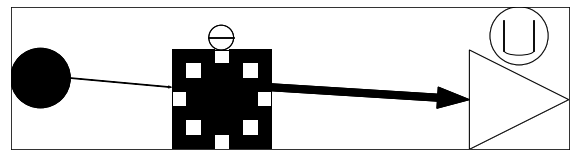

In [32]:
fig_weights = bimonn_viz.BimonnVizualiser(model.model, mode="closest").get_fig(figsize=(10, 10), axis='on')
fig_weights.axes[0].set_xticks([])
fig_weights.axes[0].set_yticks([])

In [29]:
layer = model.model.layers[0].bises[0]
selems, dists = layer.closest_selem_handler.compute_selem_dist_for_operation_chan(
    weights=layer._normalized_weights, bias=layer.bias, chout=0, operation='dilation', )

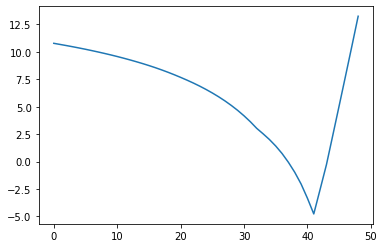

In [30]:
plt.plot(dists)

#### Distance analysis, max distance

In [5]:
def distance_to_bounds(bound_fn, normalized_weights: torch.Tensor, bias: torch.Tensor, S: np.ndarray, v1: float = 0, v2: float = 1) -> float:
    assert np.isin(np.unique(S), [0, 1]).all(), "S must be binary matrix"
    lb, ub = bound_fn(normalized_weights=normalized_weights, S=S, v1=v1, v2=v2)
    dist_lb = lb + bias  # if dist_lb < 0 : lower bound respected
    dist_ub = -bias - ub  # if dist_ub < 0 : upper bound respected
    return dist_lb, dist_ub, lb, ub

def distance_to_dilation(normalized_weights: torch.Tensor, bias: torch.Tensor, S: np.ndarray, v1: float = 0, v2: float = 1) -> float:
    return distance_to_bounds(BiSE.bias_bounds_dilation, normalized_weights, bias, S, v1, v2)


def distance_to_erosion(normalized_weights: torch.Tensor, bias: torch.Tensor, S: np.ndarray, v1: float = 0, v2: float = 1) -> float:
    return distance_to_bounds(BiSE.bias_bounds_erosion, normalized_weights, bias, S, v1, v2)


def compute_selem_dist_for_operation_chan(_normalized_weight, bias, idx: int, operation: str, v1: float = 0, v2: float = 1):
    weights = _normalized_weight[idx, 0]
    weight_values = weights.unique().detach().cpu().numpy()
    bias = bias[idx]
    distance_fn = {'dilation': distance_to_dilation, 'erosion': distance_to_erosion}[operation]

    dists_lb = np.zeros_like(weight_values)
    dists_ub = np.zeros_like(weight_values)
    lb = np.zeros_like(weight_values)
    ub = np.zeros_like(weight_values)
    selems = []
    for value_idx, value in enumerate(weight_values):
        selem = (weights >= value).cpu().detach().numpy()
        dists_lb[value_idx], dists_ub[value_idx] , lb[value_idx], ub[value_idx] = distance_fn(weights, bias, selem, v1, v2)
        selems.append(selem)

    return selems, dists_lb, dists_ub, lb, ub

In [73]:
layer = model.model.layers[1].bise_0
selems, dists_lb, dists_ub, lb, ub = compute_selem_dist_for_operation_chan(layer._normalized_weight, layer.bias, 0, "dilation")

In [35]:
def plot_0_and_true(offset=None, true_idx=None, ax=None, label_hline='0', label_vline='true_closest', **kwargs):
    if ax is None:
        ax = plt.gca()
    if offset is not None:
        xmin, xmax = ax.get_xlim()
        plt.hlines(offset, xmin, xmax, colors='r', label=label_hline , **kwargs)
    if true_idx is not None:
        ymin, ymax = ax.get_ylim()
        plt.vlines(true_idx, ymin, ymax, colors='b', label=label_vline, **kwargs)


In [72]:
max_dist_interval

array([121.456825, 121.544754, 121.64051 , 121.74485 , 121.842766,
       121.95213 , 122.057884, 122.16737 , 122.27996 , 122.391785,
       122.50577 , 122.616425, 122.731445, 122.84823 , 122.96686 ,
       123.08565 , 123.20298 , 123.31858 , 123.430405, 123.55748 ,
       123.678406, 123.81208 , 123.93982 , 124.07225 , 124.174736,
       124.34528 , 124.499054, 124.676506, 124.849205, 125.01055 ,
       125.19075 , 125.38675 , 125.45886 , 125.723465, 125.98807 ,
       126.269806, 110.62233 , 118.80555 , 126.995026, 135.21216 ,
       143.68256 , 151.96188 , 160.58655 , 169.23476 , 177.6984  ,
       185.59547 , 195.03523 , 202.63504 , 210.55084 ], dtype=float32)

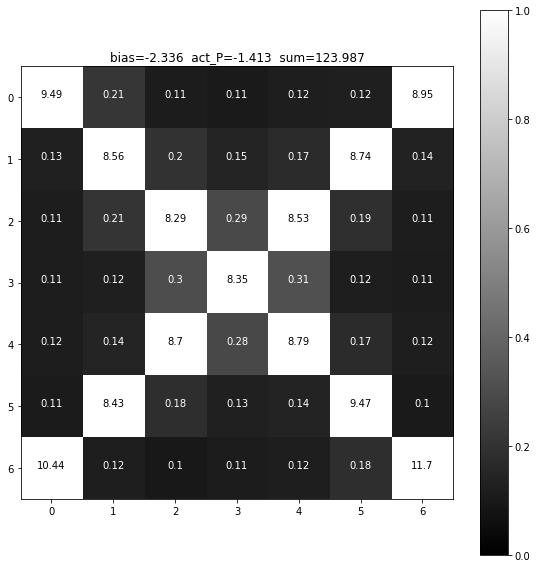

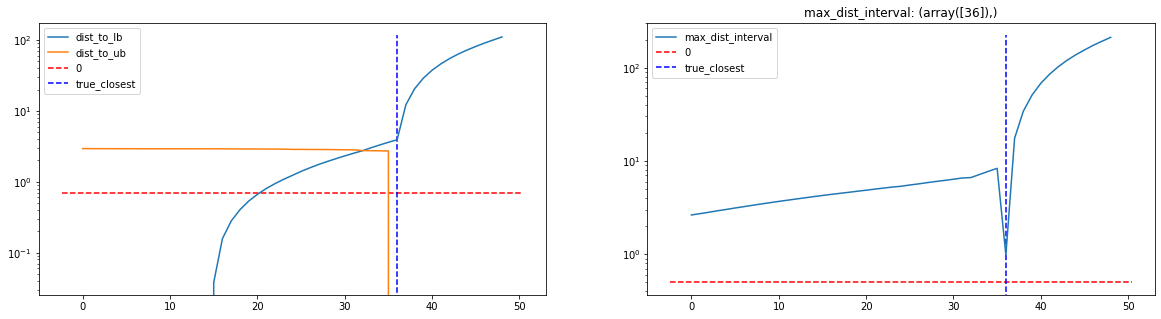

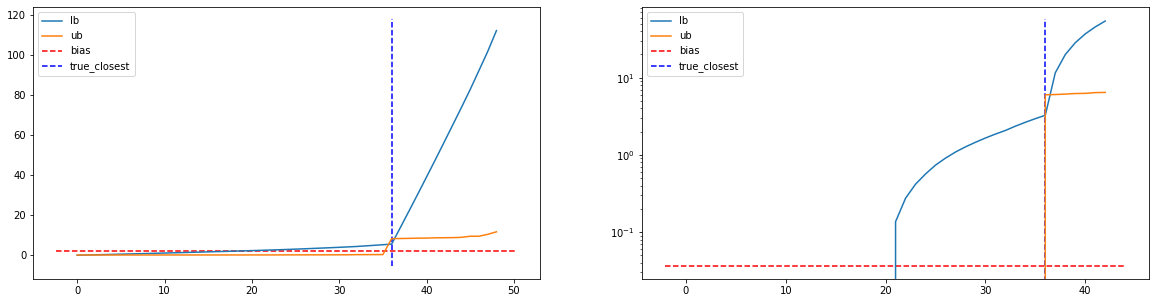

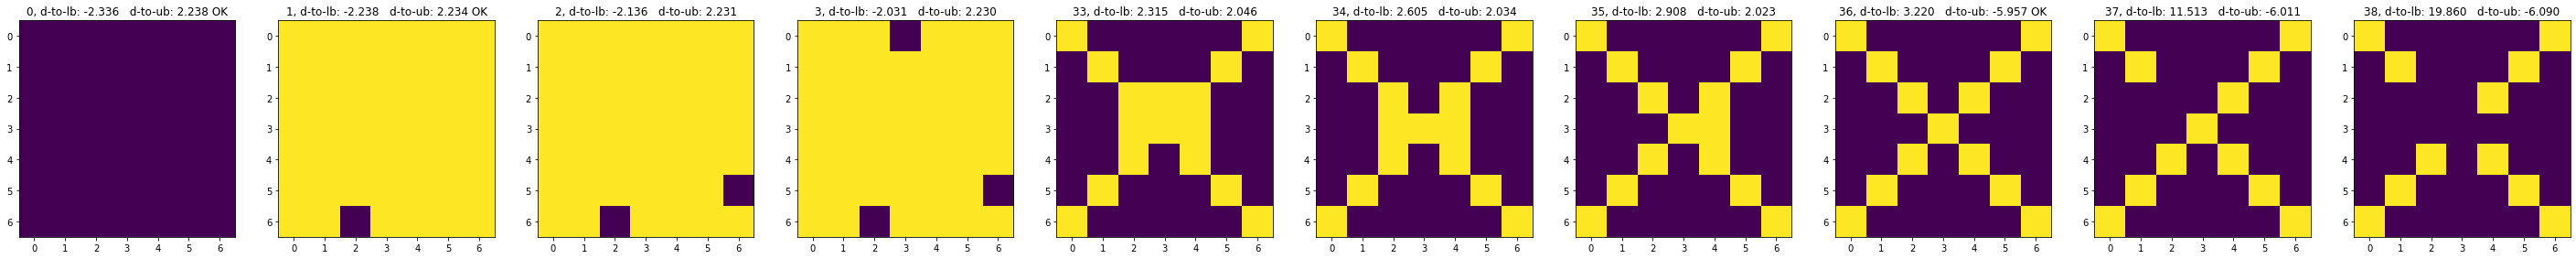

In [74]:
from deep_morpho.observables import PlotWeightsBiSE

PlotWeightsBiSE.get_figure_normalized_weights(layer._normalized_weight[0, 0], layer.bias, layer.activation_P)

true_idx = 36
b = -layer.bias.item()

plt.figure(figsize=(20, 5))

plt.subplot(121)
offset = 0.7
plt.plot(dists_lb + offset, label='dist_to_lb')
plt.plot(dists_ub + offset, label='dist_to_ub')
plot_0_and_true(offset, true_idx, linestyle='dashed')
plt.legend()
plt.yscale('log')

plt.subplot(122)
offset = 0.5
# plt.plot(np.maximum(dists_lb, dists_ub, np.zeros_like(dists_lb)) + offset, label='max_dist')
# plt.plot(np.maximum(dists_lb, 0) + np.maximum(0, dists_ub) + offset, label='sum_dist')

max_dist_interval = np.maximum(dists_lb, dists_ub, np.zeros_like(dists_lb)) + lb - ub
plt.plot(max_dist_interval + offset, label='max_dist_interval')
plt.title(f"max_dist_interval: {np.where(max_dist_interval == max_dist_interval[~np.isnan(max_dist_interval)].min())}")
des salons pro'dist2')

plot_0_and_true(offset, true_idx, linestyle='dashed')
plt.legend()
plt.yscale('log')


# plt.subplot(133)
# offset = 0
# plt.plot(np.maximum(dists_lb, 0) + np.maximum(0, dists_ub) + offset, label='sum_dist')
# plt.hlines(offset, 0, len(dists_lb) - 1, colors='r', label='0')
# plt.legend()
# plt.yscale('log')


plt.figure(figsize=(20, 5))
plt.subplot(121)
# offset = -2.3
offset = 0
# last_idx = 43
last_idx = len(lb)
plt.plot(lb[:last_idx] + offset, label='lb')
plt.plot(ub[:last_idx] + offset, label='ub')
plot_0_and_true(-layer.bias.item() + offset, true_idx, label_hline='bias', linestyle='dashed')

plt.legend()
# plt.yscale('log')

plt.subplot(122)
offset = -2.3
last_idx = 43
plt.plot(lb[:last_idx] + offset, label='lb')
plt.plot(ub[:last_idx] + offset, label='ub')
plot_0_and_true(-layer.bias.item() + offset, true_idx, label_hline='bias', linestyle='dashed')
plt.legend()
plt.yscale('log')


idx_operable = np.where(lb < ub)[0]
idx_to_show = []
for idx in idx_operable:
    for i in range(-3, 3):
        if 0 <= i + idx < len(lb):
            idx_to_show.append(idx + i)
idx_to_show = sorted(list(set(idx_to_show)))

ncols = len(idx_to_show)
fig, axs = plt.subplots(1, ncols, figsize=(ncols*5, 5))
for ax_idx, selem_idx in enumerate(idx_to_show):
# for ax_idx, selem_idx in enumerate(range(first_idx, last_idx)):
    axs[ax_idx].imshow(selems[selem_idx])
    title = f'{selem_idx}, d-to-lb: {dists_lb[selem_idx]:.3f}   d-to-ub: {dists_ub[selem_idx]:.3f}'
    if selem_idx in idx_operable:
        title += " OK"
    axs[ax_idx].set_title(title)


In [14]:
selems, dists = model.model.layers[0].bise_0.compute_selem_dist_for_operation_chan(0, "erosion")

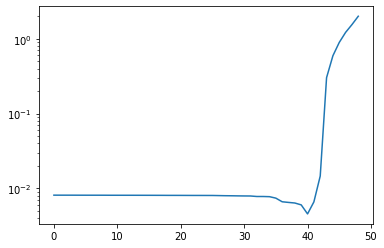

In [13]:
plt.plot(dists)
plt.yscale('log')

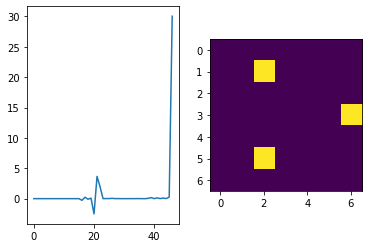

In [95]:
plt.subplot(121)
plt.plot(dists[2:] + dists[:-2] - 2 * dists[1:-1])

plt.subplot(122)
idx = np.abs(dists[2:] + dists[:-2] - 2 * dists[1:-1]).argmax()
plt.imshow(selems[idx])

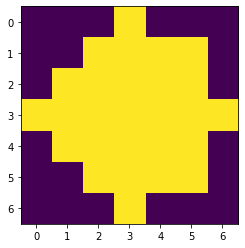

In [98]:
plt.imshow(selems[dists.argmin()])

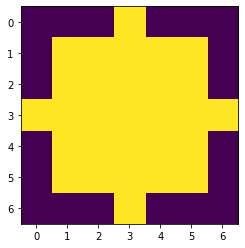

In [25]:
plt.imshow(selems[20])

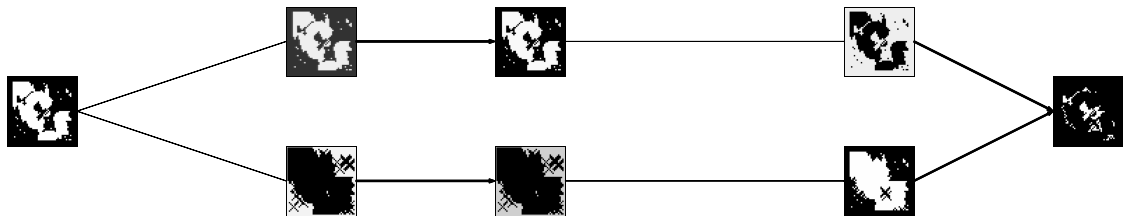

In [72]:
reload_modules()

morp_operation = morpop.ParallelMorpOperations.black_tophat(('dcross', 7))

# plot_horizontal(morp_operation.selems, morp_operation.operations)

dataloader = mrda.DiskorectDataset.get_loader(
    batch_size=32, 
    n_inputs=500_000,
    random_gen_fn=gfo3.get_random_diskorect_channels,
    random_gen_args={'size': (50, 50), 'n_shapes': 20, 'max_shape': (20, 20), 
                     'p_invert': 0.5, 'n_holes': 10, 'max_shape_holes': (10, 10), 
                     'noise_proba': 0.02},
    device=device,
    morp_operation=morp_operation,
)

img, target = next(iter(dataloader))

vizf = bimonn_viz.BimonnForwardVizualiser(model=model.model, inpt=img.cuda())
vizf.draw(figsize=(20, 10))


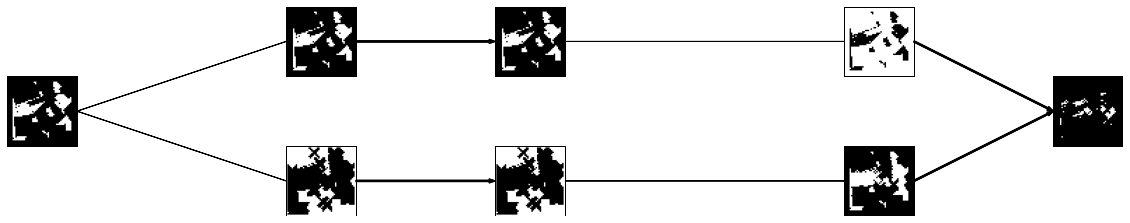

In [13]:
vizf = bimonn_viz.BimonnForwardVizualiser(model=model.model, inpt=img.cuda(), mode="binary")
vizf.draw(figsize=(20, 10))


In [25]:
all_outputs = model.model.forward_save(img.cuda())

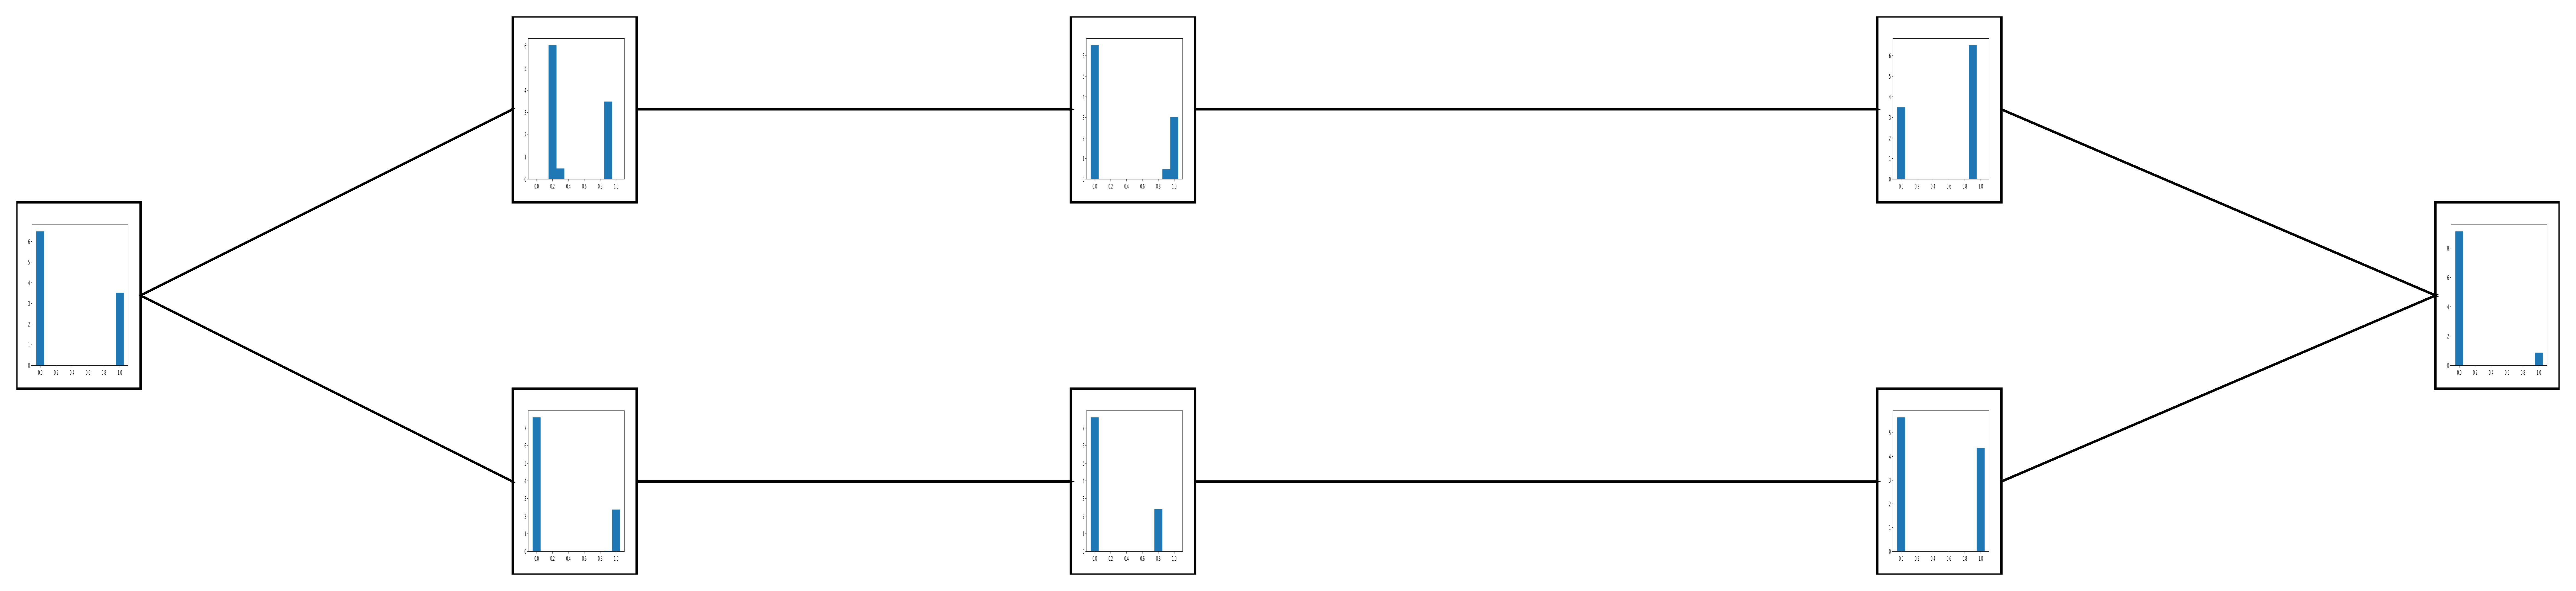

In [64]:
viz_hist = bimonn_viz.BimonnHistogramVizualiser(model=model.model, inpt=img.cuda(), dpi=600);
viz_hist.draw(figsize=(20, 10), dpi=600)



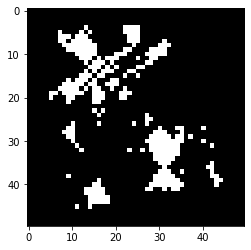

In [88]:
plt.imshow(target[0, 0].cpu().detach().numpy(), cmap='gray')

[]

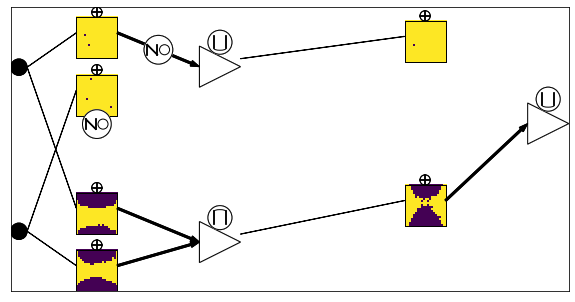

In [5]:
fig_binary = bimonn_viz.BimonnVizualiser(model.model, mode="closest").get_fig(figsize=(10, 10), axis='on')
fig_binary.axes[0].set_xticks([])
fig_binary.axes[0].set_yticks([])

In [26]:
fig_weights.savefig("axspa_weights_2.svg")

In [27]:
fig_binary.savefig("axspa_binary_2.svg")


In [9]:
fig_weights.axis('on')

AttributeError: 'Figure' object has no attribute 'axis'

In [2]:
fig_weights.savefig("black_tophat_weights_diskorect_dcross.png")


NameError: name 'fig_weights' is not defined

In [12]:
res = -0.16-0.22-0.13-.1-.17-.14-.17-.2-.38-.21-.22-.1-.22-.41-.39-.4-.19-.12-.37-.39-.27-.37-.38-.11-.2-.39-.38-.39-.24-.09-.23-.2-.37-.21-.19-.15-.17-.1-.13-.22-.16+.54+.35+.55+.37+.54+.36+.55+.36
def tanh_threshold(x):
    return 1/2 * torch.tanh(x) + 1/2
tanh_threshold(torch.tensor(res - 6.09))

tensor(0.)

In [ ]:
model.model

BiMoNN(
  (layer1): BiSEL(
    (bise_0): BiSE(
      (conv): Conv2d(1, 2, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), padding_mode=replicate)
      (softplus_layer): Softplus(beta=1, threshold=20)
      (weight_threshold_layer): IdentityLayer()
      (activation_threshold_layer): TanhLayer()
    )
    (lui_0): LUI(
      (threshold_layer): TanhLayer()
      (linear): Linear(in_features=1, out_features=1, bias=True)
      (softplus_layer): Softplus(beta=1, threshold=20)
    )
    (lui_1): LUI(
      (threshold_layer): TanhLayer()
      (linear): Linear(in_features=1, out_features=1, bias=True)
      (softplus_layer): Softplus(beta=1, threshold=20)
    )
  )
  (layer2): BiSEL(
    (bise_0): BiSE(
      (conv): Conv2d(1, 1, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), padding_mode=replicate)
      (softplus_layer): Softplus(beta=1, threshold=20)
      (weight_threshold_layer): IdentityLayer()
      (activation_threshold_layer): TanhLayer()
    )
    (bise_1): BiSE(
      (con

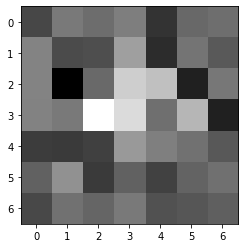

In [29]:
node10 = model.model.layers[1].bises[0]
weight = node10._normalized_weight[0].detach().cpu().squeeze()
plt.imshow(weight, cmap='gray')

In [65]:
lui11 = model.model.layers[1].luis[0]
print(lui11.coefs)
print(lui11.bias)

tensor([[1.3375, 1.8092]], device='cuda:0', grad_fn=<SoftplusBackward>)
tensor([-1.7956], device='cuda:0', grad_fn=<SubBackward0>)


In [16]:

morp_operation = morpop.ParallelMorpOperations.black_tophat(('disk', 3))


dataloader = mrda.DiskorectDataset.get_loader(
    batch_size=32, 
    n_inputs=500_000,
    random_gen_fn=gfo3.get_random_diskorect_channels,
    random_gen_args={'size': (50, 50), 'n_shapes': 20, 'max_shape': (20, 20), 
                     'p_invert': 0.5, 'n_holes': 10, 'max_shape_holes': (10, 10), 
                     'noise_proba': 0.02},
    device=device,
    morp_operation=morp_operation,
)

img, target = next(iter(dataloader))
img = img.cuda()

In [31]:
lui00

LUI(
  (threshold_layer): TanhLayer()
  (linear): Linear(in_features=1, out_features=1, bias=True)
  (softplus_layer): Softplus(beta=1, threshold=20)
)

In [55]:
pred_id = node10(lui00(node00(img)[:, 0:1, ...]))
pred_op = node11(lui01(node00(img)[:, 1:2, ...]))
pred_model = model.model(img)
pred_lui = lui11(torch.cat([pred_id, pred_op], dim=1))


In [56]:
def plot_tensor(img):
    plt.imshow(img.detach().cpu().numpy(), cmap='gray')

Text(0.5, 1.0, 'Opening Output')

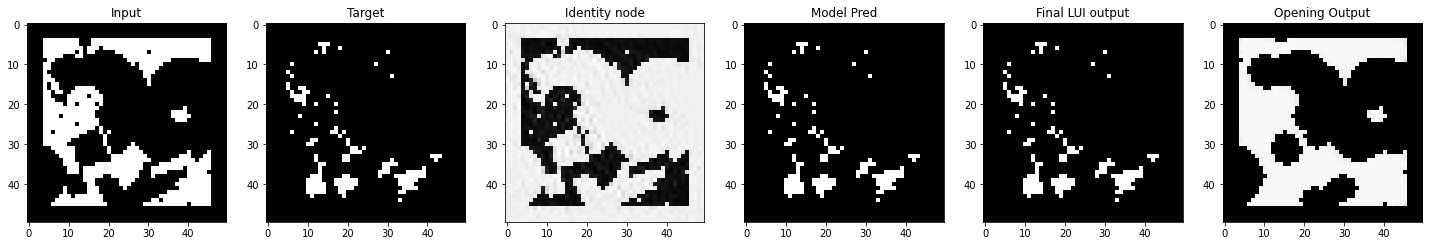

In [58]:
plt.figure(figsize=(25, 5))
plt.subplot(161)
plot_tensor(img[0, 0])
plt.title('Input')

plt.subplot(162)
plot_tensor(target[0, 0])
plt.title('Target')

plt.subplot(163)
plot_tensor(pred_id[0, 0])
plt.title('Identity node')

plt.subplot(164)
plot_tensor(pred_model[0, 0])
plt.title('Model Pred')

plt.subplot(165)
plot_tensor(pred_lui[0, 0])
plt.title('Final LUI output')


plt.subplot(166)
plot_tensor(pred_op[0, 0])
plt.title('Opening Output')

In [64]:
pred_id[0, 0].max()

tensor(0.9800, device='cuda:0', grad_fn=<MaxBackward1>)

In [6]:
node.closest_selem.shape

(7, 7, 1)

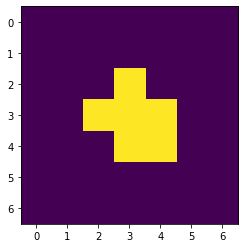

In [7]:
plt.imshow(node.closest_selem[..., 0])

In [6]:
dists = {"dilation": {"lb": [], "ub": []}, "erosion": {"lb": [], "ub": []}}
dist_fn = {"dilation": node.bias_bounds_dilation, "erosion": node.bias_bounds_erosion}

weight_values = np.unique(weight)

for op in dists.keys():
    for thresh in weight_values:
        selem = (weight >= thresh).numpy()
        lb, ub = dist_fn[op](normalized_weights=weight, S=selem, v1=0, v2=1)
        dists[op]["lb"].append((lb + bias).item())
        dists[op]["ub"].append((-bias - ub).item())
    



-4.24459171295166


Text(0.5, 1.0, 'erosion, ub')

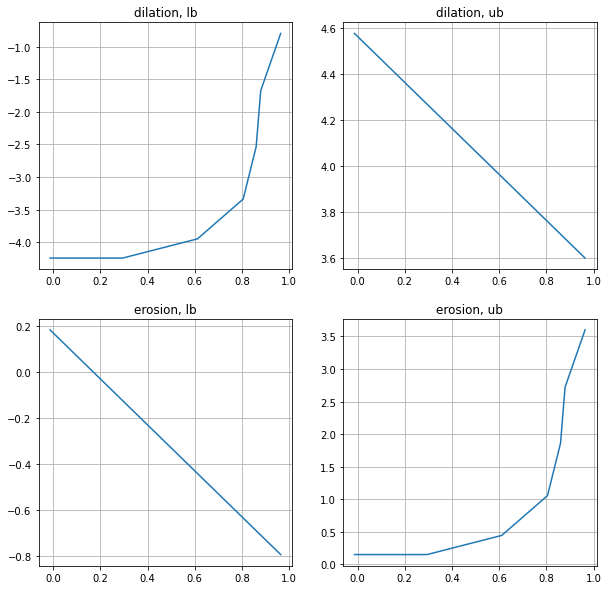

In [8]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

print(bias.item())

axs[0, 0].plot(weight_values, dists['dilation']['lb'])
axs[0, 0].grid('on')
axs[0, 0].set_title('dilation, lb')

axs[0, 1].plot(weight_values, dists['dilation']['ub'])
axs[0, 1].grid('on')
axs[0, 1].set_title('dilation, ub')

# axs[0, 2].plot(weight_values, np.maximum(dists['dilation']['ub'], dists['dilation']['lb']))
# axs[0, 2].grid('on')
# axs[0, 2].set_title('dilation, max')

axs[1, 0].plot(weight_values, dists['erosion']['lb'])
axs[1, 0].grid('on')
axs[1, 0].set_title('erosion, lb')

axs[1, 1].plot(weight_values, dists['erosion']['ub'])
axs[1, 1].grid('on')
axs[1, 1].set_title('erosion, ub')

# axs[1, 2].plot(weight_values, np.maximum(dists['erosion']['ub'], dists['erosion']['lb']))
# axs[1, 2].grid('on')
# axs[1, 2].set_title('erosion, max')


In [6]:
reload_modules()

morp_operation = arm.SequentialMorpOperations(
    name="opening", 
    selems=[morp.disk(3), morp.disk(3)],
    operations=['erosion', 'dilation'],
    device='cpu'
)

fig = plt.figure()
for selem_idx, selem in enumerate(morp_operation.selems):
    ax = fig.add_subplot(1, len(morp_operation), selem_idx + 1)
    ax.imshow(selem)
    ax.set_title(morp_operation.operations[selem_idx])

dataloader = mrda.MultiRectDatasetGenerator.get_loader(
    batch_size=32, 
    n_inputs=500_000,
    random_gen_fn=gfo3.get_random_rotated_diskorect,
    random_gen_args={'size': (50, 50), 'n_shapes': 15, 'max_shape': (15, 15), 'p_invert': .5,
                    'border': (4, 4)},
    device=device,
    morp_operation=morp_operation,
)



AttributeError: module 'general.array_morphology' has no attribute 'SequentialMorpOperations'

/hdd/aouadt/these/projets/3d_segm/general/array_morphology.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(ar).unsqueeze(0).unsqueeze(0).float().to(device)


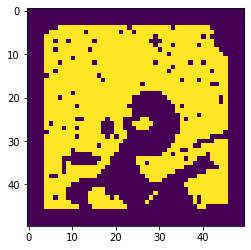

In [31]:
img, target = next(iter(dataloader))
img = img.to('cpu')
plt.imshow(img[0, 0].cpu().detach())

In [37]:
model.to(device)
img = img.to(device)
model(img).unique()

tensor([0.0053, 0.0139, 0.0142, 0.0156, 0.0166, 0.0167, 0.0169, 0.0185, 0.0197,
        0.0198, 0.0221, 0.0244, 0.0267, 0.0267, 0.0368, 0.0439, 0.0470, 0.0978,
        0.7166, 1.0000, 1.0053], device='cuda:0', grad_fn=<Unique2Backward>)

In [32]:
otp1 = model.model.bises[1](img)

loss(model(img).squeeze(), target).backward()

IndexError: list index out of range

In [35]:
print(model.model.bises[1].weight.grad)

tensor([[[[0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0.]]]], device='cuda:0')


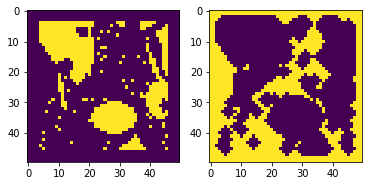

In [14]:
fig = plt.figure()
ax = fig.add_subplot(121)
ax.imshow(img[0, 0].cpu().detach())

ax = fig.add_subplot(122)
ax.imshow(otp1[0, 0].cpu().detach())


Parameter containing:
tensor([-3.0075], device='cuda:0', requires_grad=True)


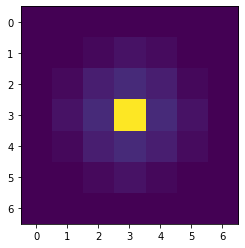

In [51]:
plt.imshow(model.model.bises[0]._normalized_weight[0, 0].detach().cpu())
print(model.model.bises[0].bias)

In [44]:
loss(model.model.bises[0](img).squeeze(), target).backward()

In [49]:
model.model.bises[0].weight_P.grad

tensor([0.], device='cuda:0')

In [19]:
ero_layer = model.model.bises[0]
otp1 = ero_layer.conv._conv_forward(img, ero_layer._normalized_weight, ero_layer.bias)
otp2 = ero_layer.activation_threshold_layer(otp1)

NameError: name 'img' is not defined

In [67]:
img.max()

tensor(1., device='cuda:0')

In [55]:
print(otp1[0, 0].min())
print(otp1[0, 0].max())


tensor(-3.0075, device='cuda:0', grad_fn=<MinBackward1>)
tensor(-1.0926, device='cuda:0', grad_fn=<MaxBackward1>)


In [64]:
ero_layer.activation_threshold_layer.threshold_fn(-3.0075 )

<function deep_morpho.threshold_fn.tanh_threshold(x)>

In [59]:
ero_layer.bias

Parameter containing:
tensor([-3.0075], device='cuda:0', requires_grad=True)

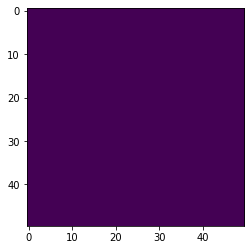

In [61]:
plt.imshow(otp2[0, 0].cpu().detach())

In [8]:
reload_modules()
tb_path = ("/hdd/aouadt/these/projets/3d_segm"
          "/deep_morpho/results/Bimonn_exp_19/dilation_size_7x7/version_0/checkpoints/epoch=0-step=31249.ckpt")

model = models.LightningBiMoNN.load_from_checkpoint(tb_path)
model.to(device)

ero_layer = model.model.bises[0]

ero_layer.find_all_selem_dilation()

[]

In [9]:
%%timeit
ero_layer.find_all_selem_dilation()

15.9 ms ± 125 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [10]:
ero_layer._normalized_weight.unique().shape

torch.Size([49])

# NeurIPS results

In [3]:
from deep_morpho.save_results_template.display_results import DisplayResults
from matplotlib.lines import Line2D


def list_dir_joined(folder: str):
    return [os.path.join(folder, k) for k in os.listdir(folder)]


TB_PATHS = []

path_global = "deep_morpho/results/results_tensorboards/Bimonn_exp_78/grid_search"
for exp_nb in [f"{i}" for i in range(4)]:
    for version in list_dir_joined(join(path_global, exp_nb, "mnistclassifchannel", "bimonndensenotbinary")):
        TB_PATHS.append(version)
# print(TB_PATHS)
# savepath = f'html_pages/experiments/78_mnistclassifchannel_bimonndensenotbinary.html'
# html = DisplayResults().save(TB_PATHS, savepath, title="neurips_gridsearch", show_table=True, show_details=False, show_boxplot=False)
df, global_args, changing_args = DisplayResults().get_df_from_tb_paths(TB_PATHS)
df["test_accuracy"] = df["test_accuracy"].astype(float)
df["binary_test_accuracy"] = df["binary_test_accuracy"].astype(float)
df["test_error"] = 1 - df["test_accuracy"].astype(float)
df["binary_test_error"] = 1 - df["binary_test_accuracy"].astype(float)
df["float_params"] = df["float_params"].astype(float)

def archi_names(x):
    x = float(x)
    if x < 3.2e6:
        return "Chans [200]"
    if x < 5e6:
        return "3.3M params"
    return "10M params"
df["Architecture"] = df["float_params"].apply(archi_names)

df["Weight Reparametrization"] = df["atomic_element"].apply(lambda x: x.replace("dual_bisel", "dual").replace("bisel", "positive"))
df["Bias Reparametrization"] = df["bias_optim_mode"].apply(lambda x: x.lower().replace("_", " ").replace("reparametrized", "reparam").replace("interval", ""))
df["Number of Level-sets"] = df["n_values"].astype(int)


Reading results:   0%|          | 0/144 [00:00<?, ?it/s]

Args: 100%|██████████| 43/43 [00:00<00:00, 64160.47it/s]


In [118]:
ax.get_xticklabels()[:3]

[Text(0.4, 0, '10M params'),
 Text(3.4, 0, '3.3M params'),
 Text(6.4, 0, 'Chans [200]')]

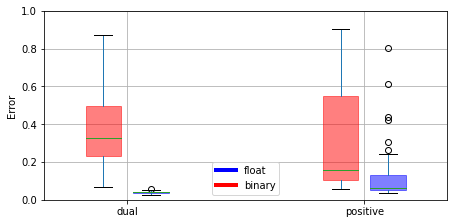

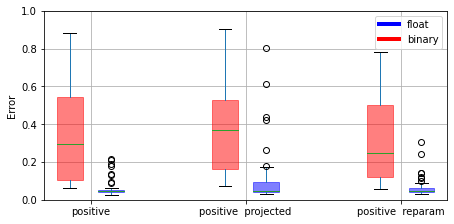

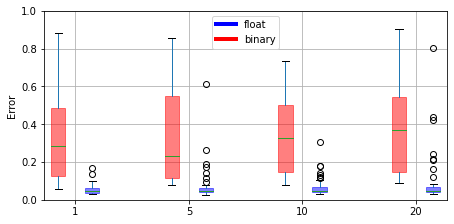

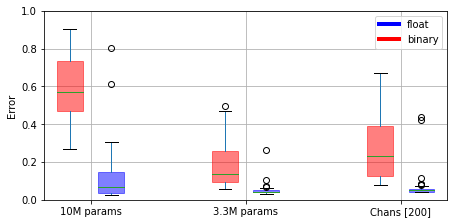

In [137]:
custom_lines = [Line2D([0], [0], color="blue", lw=4), Line2D([0], [0], color="red", lw=4)]

for hyperparam in ["Weight Reparametrization", "Bias Reparametrization", "Number of Level-sets", "Architecture"]:
    n_values = len(df[hyperparam].unique())
    fig, ax = plt.subplots(1, 1, figsize=(7, 3.5))
    centers = (n_values) * np.arange(n_values)
    df.boxplot(
        column="test_error", by=hyperparam, ax=ax, return_type="both", patch_artist=True, boxprops=dict(alpha=.5, facecolor="blue", color="blue", ), 
        positions=centers + .2*(n_values- 1)
    )
    df.boxplot(
        column="binary_test_error", by=hyperparam, ax=ax, return_type="both", patch_artist=True, boxprops=dict(alpha=.5, facecolor="red", color="red", ),
        positions=centers - .2*(n_values- 1),
    )
    # ax.set_xticklabels(df[hyperparam].unique())

    ticks = ax.get_xticklabels()[:n_values]
    ax.set_xticks(centers)
    ax.set_xticklabels(ticks)
    ax.set_title("")
    fig.suptitle("")
    ax.set_xlabel("")
    ax.set_ylabel("Error")
    ax.legend(custom_lines, ["float", "binary"])
    ax.set_ylim(0, 1)
    

In [155]:
df.loc[df["Number of Level-sets"]==5, "binary_test_error"].argmin()

21

In [156]:
df["Number of Level-sets"]==10

0       True
1       True
2       True
3       True
4       True
       ...  
139    False
140    False
141    False
142    False
143    False
Name: Number of Level-sets, Length: 144, dtype: bool

In [177]:
cur_df = df[
    (df["Number of Level-sets"]==20)
    #   & (df["Bias Reparametrization"] == "positive  reparam")
]
(
    cur_df.iloc[
        cur_df["binary_test_error"].argmin()
    ]
    [["Architecture", "Weight Reparametrization", "Bias Reparametrization", "Number of Level-sets", "test_error", "binary_test_error", "float_params"]]
)

Architecture                3.3M params
Weight Reparametrization       positive
Bias Reparametrization         positive
Number of Level-sets                 20
test_error                       0.0523
binary_test_error                0.0865
float_params                  3295340.0
Name: 109, dtype: object

# Landscape analysis

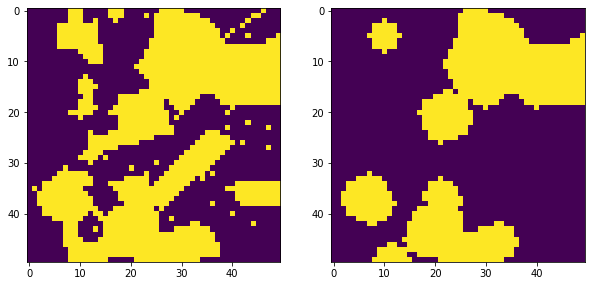

In [4]:
reload_modules()
selem = morp.disk(3)


morp_operation = morpop.ParallelMorpOperations.opening(('disk', 3))

# plot_horizontal(morp_operation.selems, morp_operation.operations)

dataloader = mrda.DiskorectDataset.get_loader(
    batch_size=32, 
    n_inputs=500_000,
    random_gen_fn=gfo3.get_random_diskorect_channels,
    random_gen_args={'size': (50, 50), 'n_shapes': 20, 'max_shape': (20, 20), 
                     'p_invert': 0.5, 'n_holes': 10, 'max_shape_holes': (10, 10), 
                     'noise_proba': 0.02, "border": (0, 0)},
    device="cpu",
    morp_operation=morp_operation,
    do_symetric_output=True,
)

img, target = next(iter(dataloader))

plt.figure(figsize=(10, 5))

plt.subplot(121)
plt.imshow(img[0, 0].cpu().detach())

plt.subplot(122)
plt.imshow(target[0, 0].cpu().detach())


In [62]:
reload_modules()

def get_net(init_bias_value=0, activation_P=0, threshold_mode="tanh_symetric"):
    return bimonn.BiMoNN(
        kernel_size=[7, 7],
        channels=[1,1, 1],
        atomic_element="sybisel",
        threshold_mode={"weight": "softplus", "activation": threshold_mode},
        activation_P=activation_P,
        constant_activation_P=False,
        init_weight_mode=bise_base.InitBiseEnum.CUSTOM_HEURISTIC,
        bias_optim_mode=bise_base.BiseBiasOptimEnum.RAW,
        init_bias_value_bise=init_bias_value,
        weights_opim_mode=bise_base.BiseWeightsOptimEnum.NORMALIZED,
        input_mean=0,
    )


In [61]:
net.layers[0].bises[0].set_bias(torch.tensor([-3]))
net.layers[0].bises[0].bias

Parameter containing:
tensor([-3], requires_grad=True)

In [104]:
net = get_net(activation_P=0, init_bias_value=.1)

for param in net.parameters():
    net.zero_grad()

net.cuda()
loss = dmloss.MaskedMSELoss(border=(4, 4))
loss_value = loss(net(img.cuda()), target.cuda())
loss_value.backward()

for name, param in net.named_parameters():
    if param is not None:
        if "weight" in name:
            continue
        print("==")
        print(name, param.grad)

==
layer1.bise_0.activation_threshold_layer.P_ tensor([0.], device='cuda:0')
==
layer1.bise_0.bias_handler.param tensor([0.], device='cuda:0')
==
layer1.lui_0.activation_threshold_layer.P_ None
==
layer1.lui_0.bias_handler.param None
==
layer2.bise_0.activation_threshold_layer.P_ tensor([-0.0537], device='cuda:0')
==
layer2.bise_0.bias_handler.param tensor([0.], device='cuda:0')
==
layer2.lui_0.activation_threshold_layer.P_ None
==
layer2.lui_0.bias_handler.param None


In [107]:
print(net.layers[1].bises[0].activation_P.grad)
print(net.layers[1].bises[0].bias.grad)
print("loss:", loss_value)

tensor([-0.0537], device='cuda:0')
tensor([0.], device='cuda:0')
loss: tensor(1., device='cuda:0', grad_fn=<MseLossBackward0>)


In [6]:
losses = {
    # "dice": DiceLoss(),
    # "bce": nn.BCELoss(),
    # "mse": nn.MSELoss(),
    # 'bcelogits': nn.BCEWithLogitsLoss(),
    "MaskedBCENormalizedLoss": partial(dmloss.MaskedBCENormalizedLoss, vmin=-1, vmax=1),
    "MaskedNormalizedDiceLoss": partial(dmloss.MaskedNormalizedDiceLoss, vmin=-1, vmax=1),
    # "MaskedBCELoss": dmloss.MaskedBCELoss,
    "MaskedMSELoss": dmloss.MaskedMSELoss,
}


In [20]:
def fc(a=2, b=4):
    return a, b

fc1 = partial(fc, 3)
print(fc1(5))

(3, 5)


In [158]:
# all_P_bise = [0]
all_P_bise = np.linspace(-.1, .1, 51)
all_bias_bise = np.linspace(-.5, .5, 51)
# all_bias_bise = np.linspace(0.4, 0.6, 50)

values = {}
grad_P_dict = {}
grad_bias_dict = {}

threshold_mode = 'tanh_symetric'
net = get_net()
net.to(device)

img = torch.zeros_like(target) + 0.5

for loss_name, loss in losses.items():
    loss_values = np.zeros((len(all_P_bise), len(all_bias_bise)))
    grad_bias_values = [np.zeros((len(all_P_bise), len(all_bias_bise))) for _ in range(len(net))]
    grad_P_values = [np.zeros((len(all_P_bise), len(all_bias_bise))) for _ in range(len(net))]

    for idx1, P_bise in tqdm(enumerate(all_P_bise)):
        for idx2, bias_bise in enumerate(all_bias_bise):
            for param in net.parameters():
                if param.grad is not None:
                    param.grad.zero_()
                
            for layer in net.layers:
                layer.bises[0].set_bias(torch.zeros_like(layer.bises[0].bias) + bias_bise)
                layer.bises[0].set_activation_P(torch.zeros_like(layer.bises[0].activation_P) + P_bise)
#             net.layer1.bises[0].set_bias(torch.zeros_like(net.layer1.bises[0].bias) + bias_bise)
#             net.layer2.bises[0].set_bias(torch.zeros_like(net.layer1.bises[0].bias) + bias_bise)

#             net.layer1.bises[0].set_activation_P(torch.zeros_like(net.layer1.bises[0].activation_P) + P_bise)
#             net.layer2.bises[0].set_activation_P(torch.zeros_like(net.layer1.bises[0].activation_P) + P_bise)

            loss_value = loss(border=(4, 4))(net(img.cuda()), target.cuda())
            loss_value.backward()
            loss_values[idx1, idx2] = loss_value.cpu().detach().item()
            
            for idx in range(len(net)):
                grad_bias_values[idx][idx1, idx2] = net.layers[idx].bises[0].bias.grad
                grad_P_values[idx][idx1, idx2] = net.layers[idx].bises[0].activation_P.grad
            
    values[threshold_mode, loss_name] = loss_values
    grad_P_dict[threshold_mode, loss_name] = grad_P_values

    grad_bias_dict[threshold_mode, loss_name] = grad_bias_values

51it [00:16,  3.12it/s]
51it [00:19,  2.63it/s]
51it [00:17,  3.00it/s]


Text(0.5, 1.0, 'Grad P')

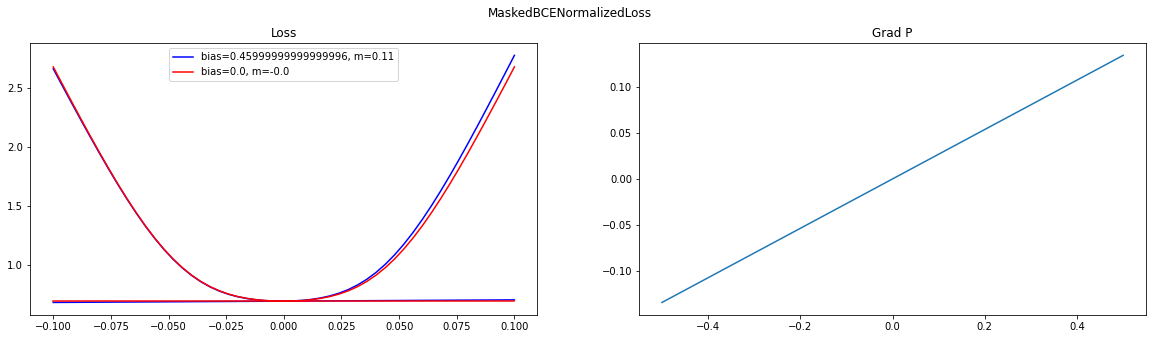

In [179]:
plt.figure(figsize=(20, 5))

loss_type = "MaskedBCENormalizedLoss"
# loss_type = "MaskedMSELoss"
mid = len(all_bias_bise) // 2
lossv = values['tanh_symetric',loss_type]
m_not_zero = (lossv[mid-1, mid + offset] - lossv[mid+1, mid + offset]) / (all_P_bise[mid - 1] - all_P_bise[mid + 1])
m_zero = (lossv[mid-1, mid] - lossv[mid+1, mid]) / (all_P_bise[mid - 1] - all_P_bise[mid + 1])

plt.suptitle(loss_type)

plt.subplot(121)
offset = 23
plt.plot(all_P_bise, lossv[:,mid + offset], label=f'bias={all_bias_bise[mid + offset]}, m={m_not_zero:.2f}', c='b')
plt.plot(
    [all_P_bise[0], all_P_bise[-1]], 
    [lossv[mid, mid + offset] - m_not_zero * (all_P_bise[mid] - all_P_bise[0]), lossv[mid, mid + offset] + m_not_zero * (all_P_bise[-1] - all_P_bise[mid])],
    c='b'
)
plt.plot(all_P_bise, lossv[:,mid], label=f'bias={all_bias_bise[mid]}, m={m_zero}', c='r')
plt.plot(
    [all_P_bise[0], all_P_bise[-1]], 
    [lossv[mid, mid] - m_zero * (all_P_bise[mid] - all_P_bise[0]), lossv[mid, mid] + m_zero * (all_P_bise[-1] - all_P_bise[mid])],
    c='r'
)
plt.legend()
plt.title('Loss')

plt.subplot(122)
plt.plot(all_bias_bise, grad_P_dict['tanh_symetric',loss_type][1][len(all_P_bise)//2])
plt.title('Grad P')

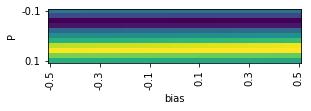

In [135]:
plt.figure(figsize=(10, 5))

plt.subplot(121)
plt.imshow(grad_P_dict['tanh_symetric', 'MaskedMSELoss'][1])
# plt.imshow(values['tanh_symetric', 'MaskedMSELoss'])
plt.ylabel('P')
plt.xlabel('bias')
plt.xticks(range(0, len(all_bias_bise), 10), [f"{k:.2}" for k in all_bias_bise][::10], rotation=90);
plt.yticks(range(0, len(all_P_bise), 10), [f"{k:.2}" for k in all_P_bise][::10]);

# plt.subplot(122)
# plt.imshow(np.log(loss_values))
# plt.ylabel('P bise')
# plt.xlabel('P lui')
# plt.xticks(range(len(all_P_lui)), [f"{k:.2}" for k in all_P_lui], rotation=90);
# plt.yticks(range(len(all_P_bise)), [f"{k:.2}" for k in all_P_bise]);

In [136]:
def plot_landscape(threshold_mode, losses=losses, grad_P_dict=grad_P_dict, grad_bias_dict=grad_bias_dict):
    XX, YY = np.meshgrid(all_bias_bise, all_P_bise)


    fig, axs = plt.subplots(3, 3, subplot_kw={"projection": "3d"}, figsize=(12, 12))
    fig.suptitle(f'threshold: {threshold_mode}')

#     idxs = [(0, 0), (0, 1), (1, 0), (1, 1)]
    keys = list(losses.keys())

    for idx in range(len(keys)):
#         ax_idx = idxs[idx]
        surf = axs[0, idx].plot_surface(XX, YY, values[threshold_mode, keys[idx]], label=keys[idx])
        axs[0, idx].set_ylabel('P')
        axs[0, idx].set_xlabel('bias')
        axs[0, idx].set_title(f'loss {keys[idx]}')
    
    for idx in range(len(keys)):
#         ax_idx = idxs[idx]
        surf = axs[1, idx].plot_surface(XX, YY, grad_P_dict[threshold_mode, keys[idx]], label=keys[idx])
        # surf = axs[1, idx].plot_surface(XX, YY, np.zeros_like(XX), label="zero", color="red")
        axs[1, idx].set_ylabel('P')
        axs[1, idx].set_xlabel('bias')
        axs[1, idx].set_title(f'grad P {keys[idx]}')

    for idx in range(len(keys)):
#         ax_idx = idxs[idx]
        surf = axs[2, idx].plot_surface(XX, YY, grad_bias_dict[threshold_mode, keys[idx]], label=keys[idx])
        surf = axs[2, idx].plot_surface(XX, YY, np.zeros_like(XX), label="zero", color="red")
        axs[2, idx].set_ylabel('P')
        axs[2, idx].set_xlabel('bias')
        axs[2, idx].set_title(f'grad bias {keys[idx]}')
        
    plt.show()

In [139]:
grad_P_dict['tanh_symetric', 'MaskedBCENormalizedLoss'][1][5, -1]

0.13414114713668823

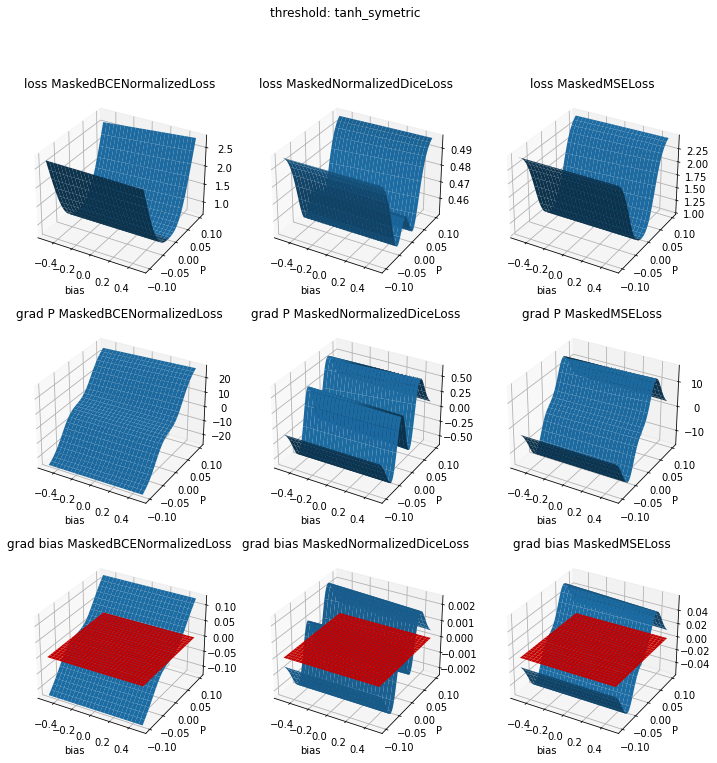

In [180]:
layer_idx = 1
plot_landscape(
    'tanh_symetric', 
    grad_P_dict={k: v[layer_idx] for k, v in grad_P_dict.items()}, 
    grad_bias_dict={k: v[layer_idx] for k, v in grad_bias_dict.items()}, 
)

<IPython.core.display.Javascript object>


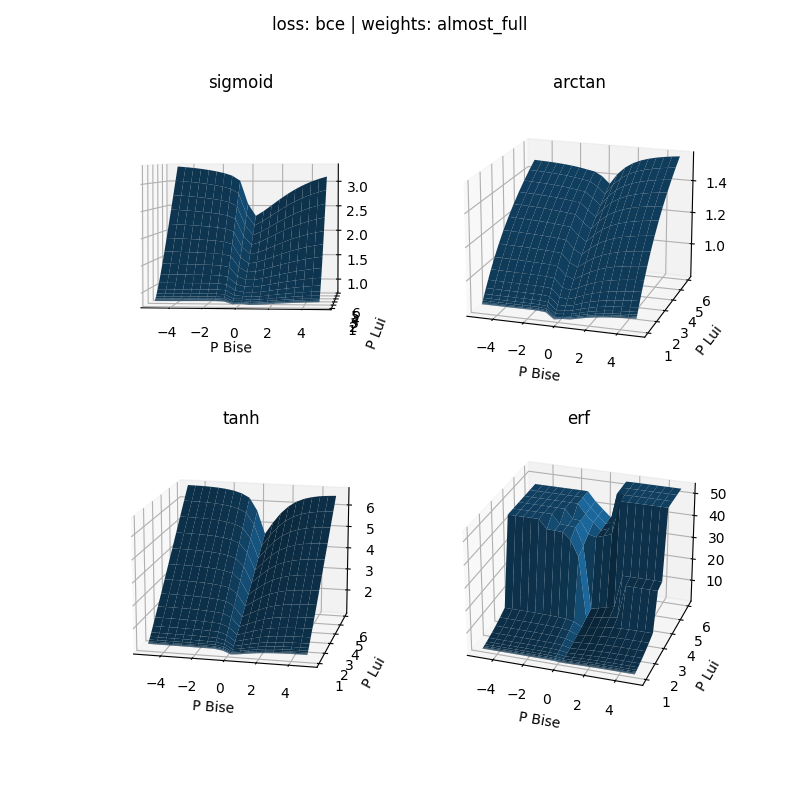

In [118]:
loss_name = "bce"
weight_name = "almost_full"  #almost_full
threshold_modes = ['sigmoid', 'arctan', 'tanh', 'erf',]

plot_landscape(threshold_modes, weight_name, loss_name,)

<IPython.core.display.Javascript object>


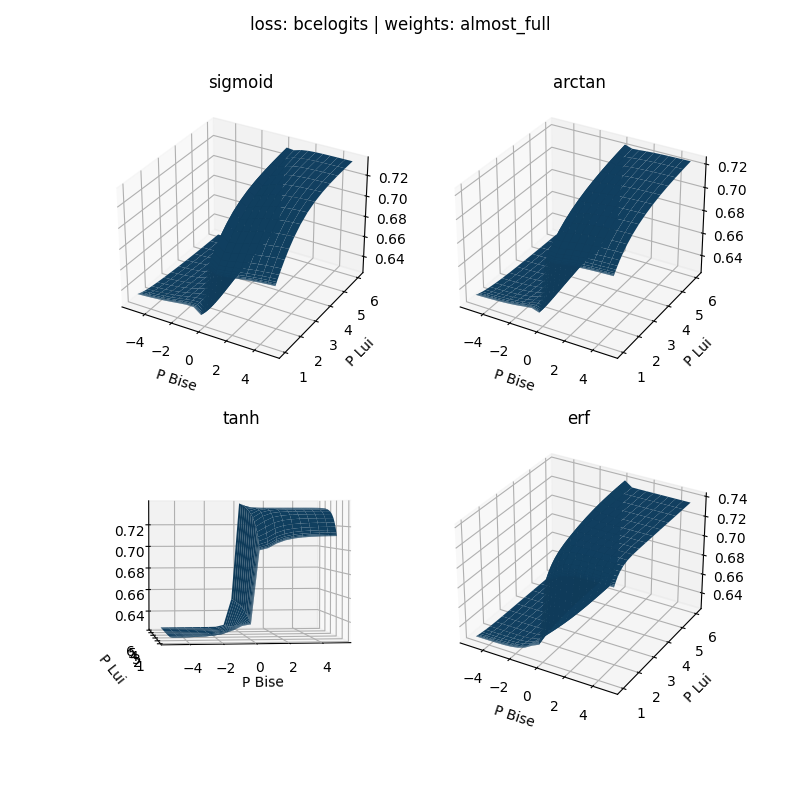

In [122]:
loss_name = "bcelogits"
weight_name = "almost_full"  #almost_full
threshold_modes = ['sigmoid', 'arctan', 'tanh', 'erf',]

plot_landscape(threshold_modes, weight_name, loss_name,)

<IPython.core.display.Javascript object>


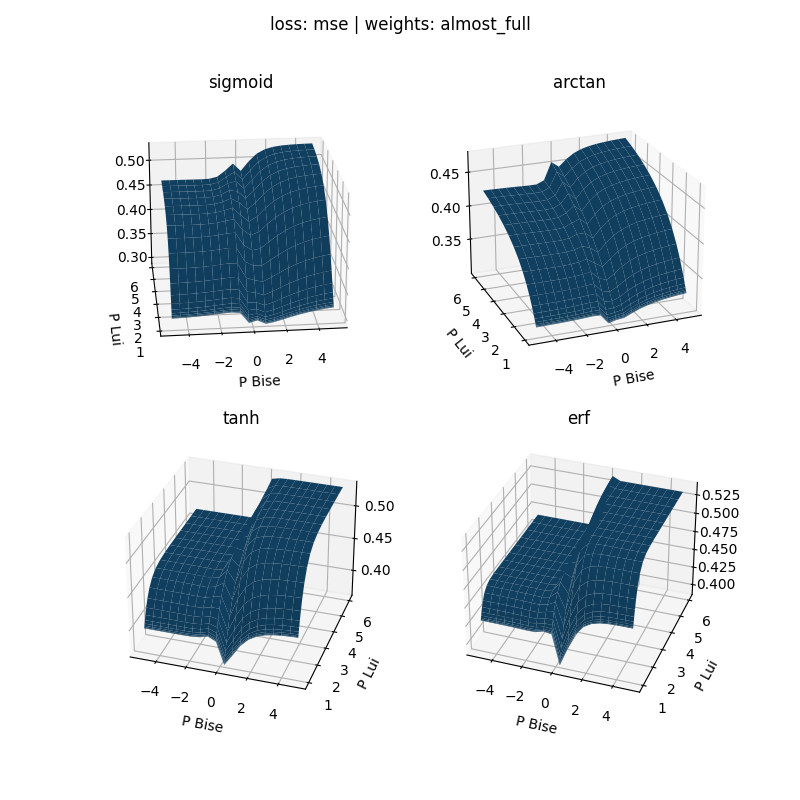

In [120]:
loss_name = "mse"
weight_name = "almost_full"  #almost_full
threshold_modes = ['sigmoid', 'arctan', 'tanh', 'erf',]

plot_landscape(threshold_modes, weight_name, loss_name,)

<IPython.core.display.Javascript object>


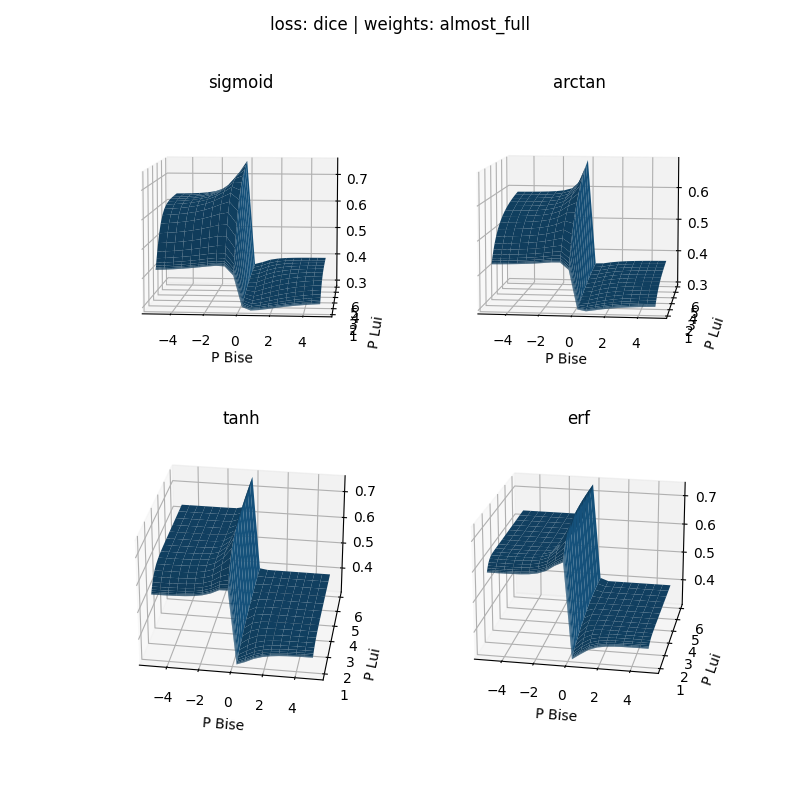

In [121]:
loss_name = "dice"
weight_name = "almost_full"  #almost_full
threshold_modes = ['sigmoid', 'arctan', 'tanh', 'erf',]

plot_landscape(threshold_modes, weight_name, loss_name,)

# Init Analysis

/hdd/aouadt/these/projets/3d_segm/deep_morpho/morp_operations.py:327: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(x)


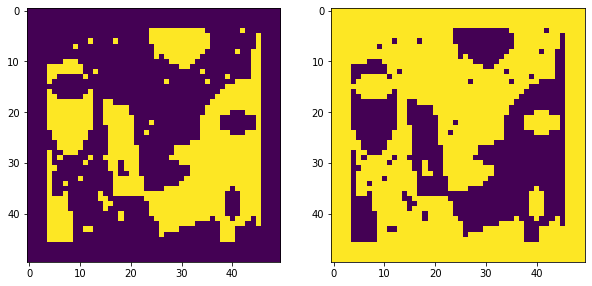

In [4]:
reload_modules()
selem = morp.disk(3)


morp_operation = morpop.ParallelMorpOperations.complementation(3)

# plot_horizontal(morp_operation.selems, morp_operation.operations)

dataloader = mrda.DiskorectDataset.get_loader(
    batch_size=32, 
    n_inputs=500_000,
    random_gen_fn=gfo3.get_random_diskorect_channels,
    random_gen_args={'size': (50, 50), 'n_shapes': 20, 'max_shape': (20, 20), 
                     'p_invert': 0.5, 'n_holes': 10, 'max_shape_holes': (10, 10), 
                     'noise_proba': 0.02},
    device=device,
    morp_operation=morp_operation,
)

img, target = next(iter(dataloader))

plt.figure(figsize=(10, 5))

plt.subplot(121)
plt.imshow(img[0, 0].cpu().detach())

plt.subplot(122)
plt.imshow(target[0, 0].cpu().detach())


In [38]:
net = bimonn.BiMoNN(
    kernel_size=[7],
    channels=[3, 2],
    atomic_element="bisel",
    threshold_mode="tanh",
    constant_activation_P=False,
    constant_weight_P=True,
    init_weight_identity=False,
)


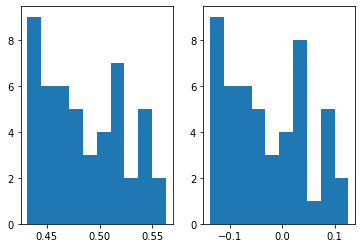

In [35]:
plt.subplot(121)
plt.hist(net.layer1.normalized_weights.detach().view(-1).numpy(),);

plt.subplot(122)
plt.hist(net.layer1.weights.detach().view(-1).numpy(),);


In [39]:
def init_bise_normal_identity(kernel_size, chan_output, std):
    weights = torch.randn(chan_output, kernel_size)[:, None, ...] * std
    weights[..., kernel_size[0] // 2, kernel_size[1] // 2] += 1
    return weights

In [40]:
net.layer1.bises[0].weight.shape

torch.Size([2, 1, 7, 7])